In [73]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Model selection and training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model interpretation
from sklearn.inspection import permutation_importance
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tabular display
from tabulate import tabulate
import joblib


In [74]:
# Use low_memory=False to prevent dtype warnings on mixed types
df_mendeley = pd.read_csv(
    'network_data_with_lexical_features/lexical_features_Mendeley_cleaned_v2.csv',
    low_memory=False
)

df_phiusiil = pd.read_csv(
    'network_data_with_lexical_features/lexical_features_PhiUSIIL_cleaned_v2_.csv',
    low_memory=False
)

In [75]:
print("First few rows of df_mendeley:")
display(df_mendeley.head())
print("\nColumns of df_mendeley:")
print(df_mendeley.columns)

print("\nFirst few rows of df_phiusiil:")
display(df_phiusiil.head())
print("\nColumns of df_phiusiil:")
print(df_phiusiil.columns)

First few rows of df_mendeley:


,url,label,source,http_status,is_active,has_redirect,error,dns_a_presence,dns_a_count,dns_mx_presence,...,max_domain_token_length,num_hostname_tokens,avg_hostname_token_length,max_hostname_token_length,first_digit_index,first_letter_index,first_slash_index,last_slash_index,first_dot_index,last_dot_index
0,https://www.google.com,0,2,200,1,0,NaN,1.0,1.0,1.0,...,6,3,4.000000,6,-1,0,6,7,11,18
1,https://www.youtube.com,0,2,200,1,1,NaN,1.0,1.0,1.0,...,7,3,4.333333,7,-1,0,6,7,11,19
2,https://www.facebook.com,0,2,200,1,1,NaN,1.0,1.0,1.0,...,8,3,4.666667,8,-1,0,6,7,11,20
3,https://www.baidu.com,0,2,200,1,0,NaN,1.0,2.0,1.0,...,5,3,3.666667,5,-1,0,6,7,11,17
4,https://www.wikipedia.org,0,2,200,1,0,NaN,1.0,1.0,1.0,...,9,3,5.000000,9,-1,0,6,7,11,21



Columns of df_mendeley:
Index(['url', 'label', 'source', 'http_status', 'is_active', 'has_redirect',
       'error', 'dns_a_presence', 'dns_a_count', 'dns_mx_presence',
       ...
       'max_domain_token_length', 'num_hostname_tokens',
       'avg_hostname_token_length', 'max_hostname_token_length',
       'first_digit_index', 'first_letter_index', 'first_slash_index',
       'last_slash_index', 'first_dot_index', 'last_dot_index'],
      dtype='object', length=129)

First few rows of df_phiusiil:


,url,label,source,http_status,is_active,has_redirect,error,dns_a_presence,dns_a_count,dns_mx_presence,...,max_domain_token_length,num_hostname_tokens,avg_hostname_token_length,max_hostname_token_length,first_digit_index,first_letter_index,first_slash_index,last_slash_index,first_dot_index,last_dot_index
0,https://www.southbankmosaics.com,1,1,200,1,0,NaN,1.0,1.0,1.0,...,16,3,7.333333,16,-1,0,6,7,11,28
1,https://www.uni-mainz.de,1,1,200,1,0,NaN,1.0,1.0,1.0,...,5,4,3.250000,5,-1,0,6,7,11,21
2,https://www.voicefmradio.co.uk,1,1,200,1,0,NaN,1.0,1.0,1.0,...,12,4,4.750000,12,-1,0,6,7,11,27
3,https://www.sfnmjournal.com,1,1,403,1,0,NaN,NaN,NaN,NaN,...,11,3,5.666667,11,-1,0,6,7,11,23
4,https://www.rewildingargentina.org,1,1,200,1,0,NaN,1.0,1.0,1.0,...,18,3,8.000000,18,-1,0,6,7,11,30



Columns of df_phiusiil:
Index(['url', 'label', 'source', 'http_status', 'is_active', 'has_redirect',
       'error', 'dns_a_presence', 'dns_a_count', 'dns_mx_presence',
       ...
       'max_domain_token_length', 'num_hostname_tokens',
       'avg_hostname_token_length', 'max_hostname_token_length',
       'first_digit_index', 'first_letter_index', 'first_slash_index',
       'last_slash_index', 'first_dot_index', 'last_dot_index'],
      dtype='object', length=129)


In [76]:
# Extract, convert to int, remove duplicates, and sort
unique_status_mendeley = sorted(set(df_mendeley['http_status'].dropna().astype(int)))
unique_status_phiusiil = sorted(set(df_phiusiil['http_status'].dropna().astype(int)))

# Print neatly
print("Unique HTTP status codes in df_mendeley:")
print(', '.join(str(code) for code in unique_status_mendeley))

print("\nUnique HTTP status codes in df_phiusiil:")
print(', '.join(str(code) for code in unique_status_phiusiil))

Unique HTTP status codes in df_mendeley:
0, 200, 202, 203, 204, 300, 301, 302, 303, 307, 400, 401, 402, 403, 404, 405, 406, 409, 410, 412, 415, 418, 420, 421, 422, 423, 427, 428, 429, 432, 437, 440, 441, 444, 451, 452, 456, 464, 468, 487, 490, 500, 501, 502, 503, 504, 505, 506, 508, 509, 514, 520, 521, 522, 523, 525, 526, 529, 530, 534, 553, 555, 556, 599, 900, 999

Unique HTTP status codes in df_phiusiil:
0, 200, 201, 202, 203, 204, 300, 301, 302, 304, 307, 400, 401, 402, 403, 404, 405, 406, 408, 409, 410, 412, 416, 417, 418, 421, 422, 423, 426, 427, 429, 434, 437, 440, 444, 451, 462, 470, 500, 501, 502, 503, 504, 505, 508, 509, 510, 511, 512, 520, 521, 522, 523, 525, 526, 530, 556, 567, 999


In [77]:
df_combined = pd.concat([df_mendeley, df_phiusiil], ignore_index=True)

In [78]:
# Load data
# Drop rows without http_status or url
df_combined = df_combined.dropna(subset=['http_status', 'url'])

# Ensure http_status is integer
df_combined['http_status'] = df_combined['http_status'].astype(int)

# Create dictionary of {status_code: url}
status_url_map = (
    df_combined.sort_values('url')  # Optional sort for consistency
    .drop_duplicates(subset=['http_status'])[['http_status', 'url']]
    .sort_values('http_status')
    .set_index('http_status')['url']
    .to_dict()
)

# Display clean output
print("Sample URL for each unique HTTP status code:")
for status, url in status_url_map.items():
    print(f"{status}: {url}")

Sample URL for each unique HTTP status code:
0: ftp://188.126.45.85/user.htm
200: http://00005ik.rcomhost.com/7fg3g
201: https://www.cmps.edu
202: http://006.zzz.com.ua/
203: https://www.avaxhome.ws/
204: http://88.119.179.160/1biycuhoqetzowaawneab.exe
300: http://lesbenwelt.de/download/.js/T-online/Telekom.php
301: http://7749kj.com/
302: http://app.agendize.com/form?id=18055353&r=18055422
303: https://www.fillatre.ca/obituaries/37412
304: https://www.millan.net
307: http://abcachiro.com/wp-content/hamed/YAHOO.COM/boxMrenewal.php
400: http://006l5.mjt.lu/lnk/awmaabassqmaaaaaaaaaacmfznwaaaabifsaaaaaabnk-gbkhnaorpeleazwr8mqwvlpopw26qay8ay/1/zcwr76kt0efi0pz-nmuhbq/ahr0chm6ly9pbm1hy29slm1pdgllbmrhb25saw5llmnvbs93ywrvemkvtk9ttkluq0gvbg9naw4ucghwpzkxnji4nxbvchbv
401: http://175.126.111.92/
402: http://bestchangetest1.zzz.com.ua/betterswap-exchanger.html
403: http://000m8ih.wcomhost.com/mama/c4fce/index_2.html
404: http://0070.zzux.com/magic/admin.php?m=login
405: http://swagvillage.com/newg

In [79]:
# Combine datasets
df_combined2 = pd.concat([df_mendeley, df_phiusiil], ignore_index=True)

# Total number of rows before filtering
total_rows_original = len(df_combined2)

# Filter for http_status between 200 and 299 (inclusive)
df_filtered = df_combined2[
    (df_combined2['http_status'] >= 200) & (df_combined2['http_status'] <= 299)
]

# Number of rows after filtering
filtered_rows = len(df_filtered)

# Compute percentage of missing values per column in the filtered data
missing_percentages = df_filtered.isnull().mean() * 100

# Keep only columns with less than 50% missing values
low_missing = missing_percentages[missing_percentages < 50]

# Sort in descending order
low_missing = low_missing.sort_values(ascending=False)

# Total number of columns in the dataset
total_columns = missing_percentages.shape[0]

# Number of columns with < 50% missing
displayed_columns = low_missing.shape[0]

# =================== Display Summary ===================
print(f"Data based on rows with http_status 200–299:")
print(f" - {filtered_rows:,} out of {total_rows_original:,} rows used ({filtered_rows / total_rows_original * 100:.1f}%)")
print(f" - {displayed_columns} out of {total_columns} columns have < 50% missing values\n")

# =============== Display Column Details ===============
print("Columns with < 50% missing values (sorted by % missing):")
print("-" * 60)

for column, percentage in low_missing.items():
    non_missing_count = df_filtered[column].notnull().sum()  # Number of non-null values
    total_valid_in_col = len(df_filtered[column])  # Should be same as filtered_rows unless column has index issues
    print(f"{column}: {percentage:.2f}% missing ({non_missing_count:,} non-null out of {filtered_rows:,} total rows)")

Data based on rows with http_status 200–299:
 - 269,411 out of 665,795 rows used (40.5%)
 - 88 out of 129 columns have < 50% missing values

Columns with < 50% missing values (sorted by % missing):
------------------------------------------------------------
dns_mx_count: 16.81% missing (224,123 non-null out of 269,411 total rows)
dns_mx_presence: 16.81% missing (224,123 non-null out of 269,411 total rows)
dns_txt_count: 16.10% missing (226,023 non-null out of 269,411 total rows)
dns_txt_presence: 16.10% missing (226,023 non-null out of 269,411 total rows)
dns_a_presence: 2.66% missing (262,246 non-null out of 269,411 total rows)
dns_a_count: 2.66% missing (262,246 non-null out of 269,411 total rows)
dns_ns_count: 1.94% missing (264,194 non-null out of 269,411 total rows)
dns_ns_presence: 1.94% missing (264,194 non-null out of 269,411 total rows)
dns_dkim_presence: 0.05% missing (269,266 non-null out of 269,411 total rows)
dns_dkim_count: 0.05% missing (269,266 non-null out of 269,411 

In [80]:
# remove columns with more than 50% missing values
high_missing = missing_percentages[missing_percentages > 50]

# Sort in descending order
high_missing = high_missing.sort_values(ascending=False)

# Total number of columns in the dataset
total_columns = missing_percentages.shape[0]

# Number of columns with > 50% missing
displayed_columns = high_missing.shape[0]

# =================== Display Summary ===================
print(f"Data based on rows with http_status 200–299:")
print(f" - {filtered_rows:,} out of {total_rows_original:,} rows used ({filtered_rows / total_rows_original * 100:.1f}%)")
print(f" - {displayed_columns} out of {total_columns} columns have < 50% missing values\n")

# =============== Display Column Details ===============
print("Columns with < 50% missing values (sorted by % missing):")
print("-" * 60)

for column, percentage in high_missing.items():
    non_missing_count = df_filtered[column].notnull().sum()  # Number of non-null values
    total_valid_in_col = len(df_filtered[column])  # Should be same as filtered_rows unless column has index issues
    print(f"{column}: {percentage:.2f}% missing ({non_missing_count:,} non-null out of {filtered_rows:,} total rows)")

Data based on rows with http_status 200–299:
 - 269,411 out of 665,795 rows used (40.5%)
 - 41 out of 129 columns have < 50% missing values

Columns with < 50% missing values (sorted by % missing):
------------------------------------------------------------
error: 100.00% missing (0 non-null out of 269,411 total rows)
has_feature_policy: 99.91% missing (237 non-null out of 269,411 total rows)
has_referrer_policy: 97.63% missing (6,387 non-null out of 269,411 total rows)
has_csp: 97.33% missing (7,196 non-null out of 269,411 total rows)
has_secure_cookie: 96.77% missing (8,692 non-null out of 269,411 total rows)
has_xss_protection: 96.66% missing (9,002 non-null out of 269,411 total rows)
has_http_only_cookie: 95.92% missing (10,982 non-null out of 269,411 total rows)
has_x_frame_options: 95.06% missing (13,303 non-null out of 269,411 total rows)
has_hsts: 94.70% missing (14,284 non-null out of 269,411 total rows)
has_x_content_type_options: 94.37% missing (15,181 non-null out of 269,4

In [81]:
# 1. Combine the datasets
df_combined = pd.concat([df_mendeley, df_phiusiil], ignore_index=True)

# 2. Handle missing values
missing_percentages = df_combined.isnull().sum() / len(df_combined) * 100
columns_to_drop = missing_percentages[missing_percentages > 50].index
print(f"Columns to drop are {columns_to_drop}")
df_combined.drop(columns=columns_to_drop, inplace=True)

# Impute remaining numerical columns with mean
for col in df_combined.columns:
    if df_combined[col].dtype in ['int64', 'float64']:
        if df_combined[col].isnull().sum() > 0:
            df_combined[col] = df_combined[col].fillna(df_combined[col].mean())

# 3. Split into ML and Rule-based subsets
df_ml = df_combined[(df_combined['http_status'] >= 200) & (df_combined['http_status'] <= 299)].copy()
df_rule_based = df_combined[(df_combined['http_status'] < 200) | (df_combined['http_status'] > 299)].copy()
df_rule_based['predicted_label'] = 2

# 4. Define features and target
columns_to_remove = ['url', 'source', 'error', 'http_status', 'label']
existing_cols = [col for col in columns_to_remove if col in df_ml.columns]
X = df_ml.drop(existing_cols, axis=1)
y = df_ml['label']

# 5. **Manually split to ensure exact 70-30 per class**
from sklearn.model_selection import train_test_split

# Split class 0 (non-phishing)
X_class0 = X[y == 0]
y_class0 = y[y == 0]
X_train0, X_test0, y_train0, y_test0 = train_test_split(
    X_class0, y_class0, test_size=0.3, random_state=42
)

# Split class 1 (phishing)
X_class1 = X[y == 1]
y_class1 = y[y == 1]
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_class1, y_class1, test_size=0.3, random_state=42
)

# Combine the splits
X_train = pd.concat([X_train0, X_train1])
X_test = pd.concat([X_test0, X_test1])
y_train = pd.concat([y_train0, y_train1])
y_test = pd.concat([y_test0, y_test1])

# Verify exact 70-30 split per class
print("\nClass 0 (Non-Phishing) - Training samples:", len(y_train0), f"({len(y_train0)/len(y_class0)*100:.1f}%)")
print("Class 0 (Non-Phishing) - Testing samples:", len(y_test0), f"({len(y_test0)/len(y_class0)*100:.1f}%)")

print("\nClass 1 (Phishing) - Training samples:", len(y_train1), f"({len(y_train1)/len(y_class1)*100:.1f}%)")
print("Class 1 (Phishing) - Testing samples:", len(y_test1), f"({len(y_test1)/len(y_class1)*100:.1f}%)")

print("\nFinal Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Columns to drop are Index(['error', 'dns_a_presence', 'dns_a_count', 'dns_mx_presence',
       'dns_mx_count', 'dns_txt_presence', 'dns_txt_count', 'dns_ns_presence',
       'dns_ns_count', 'dns_spf_presence', 'dns_spf_count',
       'dns_dkim_presence', 'dns_dkim_count', 'dns_dmarc_presence',
       'dns_dmarc_count', 'has_ssl_certificate', 'ssl_certificate_valid',
       'ssl_days_to_expiry', 'ssl_is_expired', 'ssl_is_self_signed',
       'ssl_has_chain_issues', 'ssl_hostname_mismatch', 'ssl_connection_error',
       'domain_age_days', 'time_to_expiration', 'redirect_count',
       'final_url_diff', 'response_time', 'content_length', 'has_title',
       'title_length', 'has_iframe', 'num_iframes', 'has_text_input',
       'has_password_input', 'has_button', 'has_image', 'has_submit',
       'has_link', 'num_links', 'num_images', 'num_scripts', 'has_javascript',
       'has_favicon', 'num_a_tags', 'has_xss_protection', 'has_csp',
       'has_hsts', 'has_x_frame_options', 'has_x_conten

In [82]:
# 1. Combine the datasets
df_combined = pd.concat([df_mendeley, df_phiusiil], ignore_index=True)

# 2. Filter to rows with http_status between 200 and 299 for ML model (this defines our analysis population)
df_ml_clean = df_combined[
    (df_combined['http_status'] >= 200) & (df_combined['http_status'] <= 299)
].copy()

print(f"Number of rows with http_status 200 - 299 used for ML: {len(df_ml_clean)} out of {len(df_combined)} total rows")

# 3. Analyze missing values ONLY on the ML-relevant subset (200–299)
missing_percentages = df_ml_clean.isnull().sum() / len(df_ml_clean) * 100
columns_to_drop = missing_percentages[missing_percentages > 50].index

print(f"\nColumns with > 50% missing in http_status 200 - 299 subset (to drop): {list(columns_to_drop)}")

# Drop these columns in both the ML subset AND propagate to full combined data (for consistency)
df_ml_clean.drop(columns=columns_to_drop, inplace=True)
df_combined.drop(columns=columns_to_drop, inplace=True)  # So rule-based doesn't use dropped cols

# 4. Impute remaining numerical columns using statistics FROM the 200–299 subset
for col in df_ml_clean.columns:
    if df_ml_clean[col].dtype in ['int64', 'float64']:
        if df_ml_clean[col].isnull().sum() > 0:
            col_mean = df_ml_clean[col].mean()  # Compute mean only on 200–299 data
            df_ml_clean[col] = df_ml_clean[col].fillna(col_mean)
            # Impute in full df_combined too, but only non-dropped columns
            df_combined[col] = df_combined[col].fillna(col_mean)

# 5. Now split into ML and Rule-based subsets (after column drop & imputation)
df_ml = df_ml_clean  # Already filtered, cleaned, imputed

# Rule-based: all rows outside 200–299
df_rule_based = df_combined[
    (df_combined['http_status'] < 200) | (df_combined['http_status'] > 299)
].copy()
df_rule_based['predicted_label'] = 2  # "Inactive URL"

# 6. Define features and target for ML model
columns_to_remove = ['url', 'source', 'error', 'http_status', 'label']
existing_cols = [col for col in columns_to_remove if col in df_ml.columns]

X = df_ml.drop(columns=existing_cols)
y = df_ml['label']

# 7. Manually split to ensure exact 70-30 per class
from sklearn.model_selection import train_test_split

# Split class 0 (non-phishing)
X_class0 = X[y == 0]
y_class0 = y[y == 0]
X_train0, X_test0, y_train0, y_test0 = train_test_split(
    X_class0, y_class0, test_size=0.3, random_state=42
)

# Split class 1 (phishing)
X_class1 = X[y == 1]
y_class1 = y[y == 1]
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_class1, y_class1, test_size=0.3, random_state=42
)

# Combine the splits
X_train = pd.concat([X_train0, X_train1])
X_test = pd.concat([X_test0, X_test1])
y_train = pd.concat([y_train0, y_train1])
y_test = pd.concat([y_test0, y_test1])

# 8. Verification & Summary
print("\n" + "="*50)
print("VERIFICATION OF SPLITS")
print("="*50)

print(f"Class 0 (Non-Phishing) - Training: {len(y_train0)} ({len(y_train0)/len(y_class0)*100:.1f}%)")
print(f"Class 0 (Non-Phishing) - Testing:  {len(y_test0)} ({len(y_test0)/len(y_class0)*100:.1f}%)")

print(f"\nClass 1 (Phishing) - Training: {len(y_train1)} ({len(y_train1)/len(y_class1)*100:.1f}%)")
print(f"Class 1 (Phishing) - Testing:  {len(y_test1)} ({len(y_test1)/len(y_class1)*100:.1f}%)")

print("\nFinal Shapes:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

# Optional: Report how many columns were kept
print(f"\nFeatures used in ML model: {X_train.shape[1]} columns")
print("Feature columns:", list(X.columns))

Number of rows with http_status 200 - 299 used for ML: 269411 out of 665795 total rows

Columns with > 50% missing in http_status 200 - 299 subset (to drop): ['error', 'has_ssl_certificate', 'ssl_certificate_valid', 'ssl_days_to_expiry', 'ssl_is_expired', 'ssl_is_self_signed', 'ssl_has_chain_issues', 'ssl_hostname_mismatch', 'ssl_connection_error', 'domain_age_days', 'time_to_expiration', 'redirect_count', 'final_url_diff', 'response_time', 'content_length', 'has_title', 'title_length', 'has_iframe', 'num_iframes', 'has_text_input', 'has_password_input', 'has_button', 'has_image', 'has_submit', 'has_link', 'num_links', 'num_images', 'num_scripts', 'has_javascript', 'has_favicon', 'num_a_tags', 'has_xss_protection', 'has_csp', 'has_hsts', 'has_x_frame_options', 'has_x_content_type_options', 'has_referrer_policy', 'has_feature_policy', 'has_cookie', 'has_http_only_cookie', 'has_secure_cookie']

VERIFICATION OF SPLITS
Class 0 (Non-Phishing) - Training: 105844 (70.0%)
Class 0 (Non-Phishing

In [83]:
print(columns_to_drop)

Index(['error', 'has_ssl_certificate', 'ssl_certificate_valid',
       'ssl_days_to_expiry', 'ssl_is_expired', 'ssl_is_self_signed',
       'ssl_has_chain_issues', 'ssl_hostname_mismatch', 'ssl_connection_error',
       'domain_age_days', 'time_to_expiration', 'redirect_count',
       'final_url_diff', 'response_time', 'content_length', 'has_title',
       'title_length', 'has_iframe', 'num_iframes', 'has_text_input',
       'has_password_input', 'has_button', 'has_image', 'has_submit',
       'has_link', 'num_links', 'num_images', 'num_scripts', 'has_javascript',
       'has_favicon', 'num_a_tags', 'has_xss_protection', 'has_csp',
       'has_hsts', 'has_x_frame_options', 'has_x_content_type_options',
       'has_referrer_policy', 'has_feature_policy', 'has_cookie',
       'has_http_only_cookie', 'has_secure_cookie'],
      dtype='object')


In [84]:

print(f"Column to use are {X_train.columns}")

Column to use are Index(['is_active', 'has_redirect', 'dns_a_presence', 'dns_a_count',
       'dns_mx_presence', 'dns_mx_count', 'dns_txt_presence', 'dns_txt_count',
       'dns_ns_presence', 'dns_ns_count', 'dns_spf_presence', 'dns_spf_count',
       'dns_dkim_presence', 'dns_dkim_count', 'dns_dmarc_presence',
       'dns_dmarc_count', 'url_length', 'hostname_length', 'path_length',
       'query_length', 'domain_length', 'subdomain_length', 'tld_length',
       'count_dot', 'count_hyphen', 'count_underline', 'count_slash',
       'count_question', 'count_equal', 'count_at', 'count_and',
       'count_exclamation', 'count_space', 'count_tilde', 'count_comma',
       'count_plus', 'count_asterisk', 'count_hashtag', 'count_dollar',
       'count_percent', 'count_digits', 'count_letters', 'count_special_chars',
       'count_encoded_chars', 'count_subdomains', 'count_path_levels',
       'count_query_params', 'has_ip_address', 'has_https',
       'has_suspicious_tld', 'is_shortened', 'ha

In [85]:
# Calculate the percentage of unique values per column
unique_percentages = (df_combined.nunique() / len(df_combined)) * 100

# Display the result
print(unique_percentages.sort_values(ascending=False))

url                    100.000000
entropy_url             23.959026
entropy_path             9.468230
entropy_query            2.585030
entropy_hostname         2.224408
                          ...    
has_sensitive_words      0.000300
has_fragment             0.000300
has_query                0.000300
first_slash_index        0.000300
first_letter_index       0.000150
Length: 88, dtype: float64


In [86]:
# --- METRICS & CONFUSION MATRIX UTILITY ---
def evaluate_and_plot(name, y_true, y_pred, threshold=None):
    print(f"\n{name} Metrics:")
    if threshold is not None:
        print(f"  Threshold: {threshold:.4f}")
    else:
        print("  Threshold: Not Found")

    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Random Forest model trained.
XGBoost model trained.

Random Forest Metrics:
  Threshold: 0.7000
  Accuracy : 0.9873
  Precision: 0.9859
  Recall   : 0.9853
  F1 Score : 0.9856


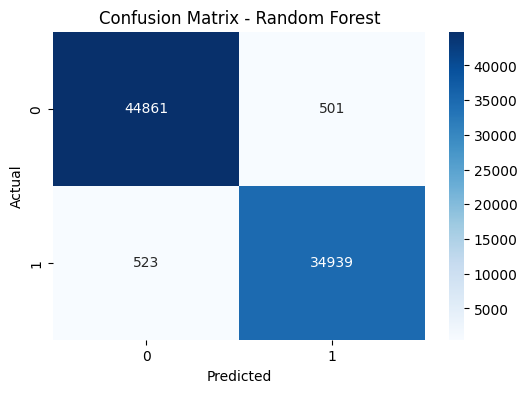


XGBoost Metrics:
  Threshold: 0.7000
  Accuracy : 0.9877
  Precision: 0.9849
  Recall   : 0.9870
  F1 Score : 0.9859


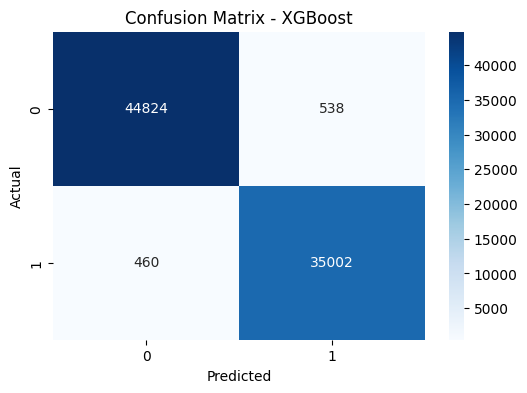

['xgboost_feb_26_confusion_matrix.pkl']

In [87]:


# --- THRESHOLDS ---
thresholds = {
    'rf': 0.7,
    'xgb': 0.7,
    'ensemble': 0.7
}

# --- MODEL INITIALIZATION ---
rf_model = RandomForestClassifier(random_state=42)

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)  # Removed deprecated param

# --- TRAIN MODELS ---
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")



xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")


# --- PREDICT PROBABILITIES ---
rf_probs = rf_model.predict_proba(X_test)[:, 1]

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# --- APPLY THRESHOLDS TO GET BINARY PREDICTIONS ---
rf_preds = (rf_probs >= thresholds['rf']).astype(int)

xgb_preds = (xgb_probs >= thresholds['xgb']).astype(int)




# --- EVALUATE ALL MODELS ---
evaluate_and_plot("Random Forest", y_test, rf_preds, thresholds['rf'])
evaluate_and_plot("XGBoost", y_test, xgb_preds, thresholds['xgb'])

# --- compute & save the matrices -----------------------------------------
joblib.dump(confusion_matrix(y_test, rf_preds),   "rf_feb_26_confusion_matrix.pkl")
joblib.dump(confusion_matrix(y_test, xgb_preds),  "xgboost_feb_26_confusion_matrix.pkl")


Ensemble (RF + XGB – equal weight) Metrics:
  Threshold: 0.7000
  Accuracy : 0.9879
  Precision: 0.9856
  Recall   : 0.9867
  F1 Score : 0.9862


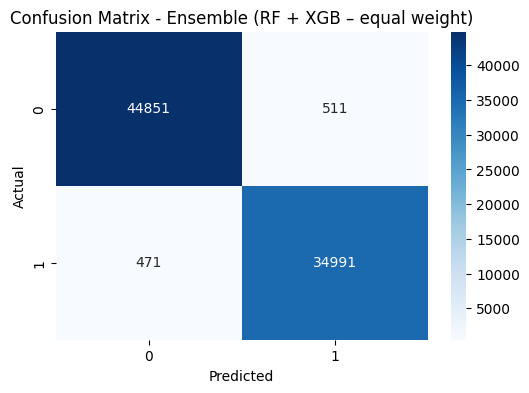


Classification Report – Strong Ensemble (RF + XGB):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     45362
           1       0.99      0.99      0.99     35462

    accuracy                           0.99     80824
   macro avg       0.99      0.99      0.99     80824
weighted avg       0.99      0.99      0.99     80824



In [88]:
# ─── Only strong models ───
ensemble_probs_strong = (rf_probs + xgb_probs) / 2
ensemble_preds_strong = (ensemble_probs_strong >= 0.7).astype(int)

evaluate_and_plot("Ensemble (RF + XGB – equal weight)", y_test, ensemble_preds_strong, 0.7)

print("\nClassification Report – Strong Ensemble (RF + XGB):")
print(classification_report(y_test, ensemble_preds_strong))

In [89]:
# Assuming you still have these from earlier:
# rf_probs, xgb_probs, y_test

weights_xgb = [0.50, 0.60, 0.65, 0.70, 0.75, 0.80]
threshold = 0.70

print("XGB weight | Accuracy | Precision | Recall | F1")
print("-"*60)

for w_xgb in weights_xgb:
    w_rf = 1.0 - w_xgb
    
    ensemble_probs = w_rf * rf_probs + w_xgb * xgb_probs
    preds = (ensemble_probs >= threshold).astype(int)
    
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    
    print(f"{w_xgb:9.2f} | {acc:.4f}   | {prec:.4f}   | {rec:.4f} | {f1:.4f}")

XGB weight | Accuracy | Precision | Recall | F1
------------------------------------------------------------


     0.50 | 0.9879   | 0.9856   | 0.9867 | 0.9862
     0.60 | 0.9879   | 0.9854   | 0.9870 | 0.9862
     0.65 | 0.9879   | 0.9854   | 0.9871 | 0.9863
     0.70 | 0.9879   | 0.9854   | 0.9871 | 0.9862
     0.75 | 0.9879   | 0.9853   | 0.9872 | 0.9862
     0.80 | 0.9879   | 0.9852   | 0.9872 | 0.9862



Ensemble (RF 35% + XGB 65%) Metrics:
  Threshold: 0.7000
  Accuracy : 0.9879
  Precision: 0.9854
  Recall   : 0.9871
  F1 Score : 0.9863


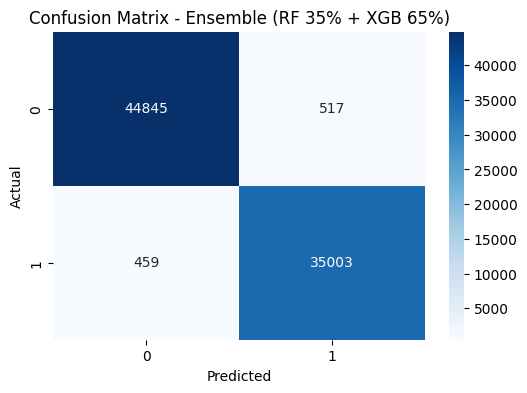


Detailed Classification Report - Ensemble (RF 35% + XGB 65%):
              precision    recall  f1-score   support

           0     0.9899    0.9886    0.9892     45362
           1     0.9854    0.9871    0.9863     35462

    accuracy                         0.9879     80824
   macro avg     0.9877    0.9878    0.9877     80824
weighted avg     0.9879    0.9879    0.9879     80824


Ensemble confusion matrix saved.


In [90]:
# Weights (chosen based on previous experiments: best F1 + improved recall)
W_RF  = 0.35
W_XGB = 0.65

# Create ensemble probabilities (soft voting)
ensemble_probs = (W_RF * rf_probs) + (W_XGB * xgb_probs)

# Apply the same threshold as the other models
ensemble_preds = (ensemble_probs >= thresholds['ensemble']).astype(int)

# Evaluate using the same function as RF and XGBoost
evaluate_and_plot(
    "Ensemble (RF 35% + XGB 65%)",
    y_test,
    ensemble_preds,
    thresholds['ensemble']
)

# Optional: detailed per-class report
print("\nDetailed Classification Report - Ensemble (RF 35% + XGB 65%):")
print(classification_report(y_test, ensemble_preds, digits=4))

# Save confusion matrix (consistent naming style)
joblib.dump(
    confusion_matrix(y_test, ensemble_preds),
    "ensemble_rf35_xgb65_feb_2026_confusion_matrix.pkl"
)

print("\nEnsemble confusion matrix saved.")


Stacking Ensemble (LR meta – proper OOF) Metrics:
  Threshold: 0.7000
  Accuracy : 0.9888
  Precision: 0.9844
  Recall   : 0.9902
  F1 Score : 0.9873


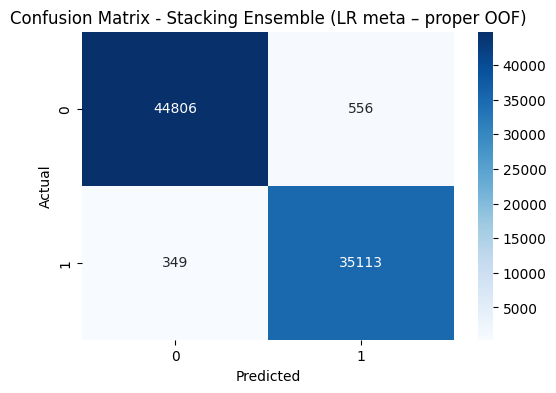


Detailed Classification Report - Stacking (proper):
              precision    recall  f1-score   support

           0     0.9923    0.9877    0.9900     45362
           1     0.9844    0.9902    0.9873     35462

    accuracy                         0.9888     80824
   macro avg     0.9883    0.9890    0.9886     80824
weighted avg     0.9888    0.9888    0.9888     80824

Proper stacking confusion matrix saved.


In [91]:
# ─── Settings ────────────────────────────────────────────────────────────────
n_folds = 5
meta_clf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# ─── Out-of-fold predictions on TRAIN set ────────────────────────────────────
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_rf  = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    # Use .iloc for DataFrame positional slicing
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]   # same for y if it's Series
    
    # Retrain base models on fold train
    rf_fold  = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
    xgb_fold = XGBClassifier(eval_metric='logloss', random_state=42).fit(X_tr, y_tr)
    
    # Predict proba on fold validation
    oof_rf[val_idx]  = rf_fold.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]
    
# ─── Train meta-learner on OOF probabilities ─────────────────────────────────
X_meta_train = np.column_stack((oof_rf, oof_xgb))
meta_clf.fit(X_meta_train, y_train)

# ─── Now predict on real TEST set ────────────────────────────────────────────
# Use the ORIGINAL (full-train) base models – already fitted earlier
rf_probs_test  = rf_model.predict_proba(X_test)[:, 1]   # ← your existing rf_model
xgb_probs_test = xgb_model.predict_proba(X_test)[:, 1]

X_meta_test = np.column_stack((rf_probs_test, xgb_probs_test))

stacking_probs = meta_clf.predict_proba(X_meta_test)[:, 1]
stacking_preds = (stacking_probs >= thresholds['ensemble']).astype(int)

# ─── Evaluate ────────────────────────────────────────────────────────────────
evaluate_and_plot(
    "Stacking Ensemble (LR meta – proper OOF)",
    y_test,
    stacking_preds,
    thresholds['ensemble']
)

print("\nDetailed Classification Report - Stacking (proper):")
print(classification_report(y_test, stacking_preds, digits=4))

# Save
joblib.dump(
    confusion_matrix(y_test, stacking_preds),
    "stacking_proper_lr_oof_sep_2025_confusion_matrix.pkl"
)
print("Proper stacking confusion matrix saved.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# -------------------------
# 1. SIGMOID UTILITY
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# -------------------------
# 2. SHAP BASELINE EXTRACTION
# -------------------------
import shap

def get_shap_base_value(model, use_probability_detection=True):
    """
    Returns (log-odds, probability) for a given tree-based model
    Handles RF (probabilities) vs XGBoost (raw margins) automatically.
    """
    explainer = shap.TreeExplainer(
        model,
        feature_perturbation="interventional",
        model_output="raw"
    )
    base_val = explainer.expected_value
    
    # Convert to scalar
    if np.isscalar(base_val):
        base_val = float(base_val)
    elif len(base_val) == 1:
        base_val = float(base_val[0])
    else:
        # multi-class, phishing class assumed index 1
        base_val = float(base_val[1])
    
    # Detect if value is already probability (for RF)
    if use_probability_detection and 0 <= base_val <= 1:
        prob = base_val
        logodds = np.log(prob / (1 - prob))
    else:
        logodds = base_val
        prob = sigmoid(logodds)
    
    return logodds, prob

# -------------------------
# 3. COMPUTE BASE VALUES
# -------------------------

# If models are already trained, just pass them
rf_base_logodds, rf_base_prob = get_shap_base_value(rf_model)
xgb_base_logodds, xgb_base_prob = get_shap_base_value(xgb_model)

# -------------------------
# 4. WEIGHTED ENSEMBLE
# -------------------------
W_RF = 0.35
W_XGB = 0.65

ensemble_prob = (W_RF * rf_base_prob) + (W_XGB * xgb_base_prob)
ensemble_logodds = np.log(ensemble_prob / (1 - ensemble_prob))

# -------------------------
# 5. STACKING ENSEMBLE
# -------------------------
# Prepare meta features using TRAIN probabilities (already trained base models)
rf_probs_train = rf_model.predict_proba(X_train)[:, 1]
xgb_probs_train = xgb_model.predict_proba(X_train)[:, 1]

X_meta_train = np.column_stack((rf_probs_train, xgb_probs_train))

# Logistic Regression meta-learner WITHOUT class_weight to match dataset prior
meta_clf = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
meta_clf.fit(X_meta_train, y_train)

# Intercept is baseline log-odds for stacking
stacking_base_logodds = float(meta_clf.intercept_[0])
stacking_base_prob = sigmoid(stacking_base_logodds)

# -------------------------
# 6. DATASET PHISHING RATE
# -------------------------
dataset_rate = float(np.mean(y_train))

# -------------------------
# 7. CREATE FINAL REPORT
# -------------------------
rows = [
    ["Random Forest", rf_base_logodds, rf_base_prob, dataset_rate],
    ["XGBoost", xgb_base_logodds, xgb_base_prob, dataset_rate],
    [f"Weighted Ensemble (RF {int(W_RF*100)}% + XGBoost {int(W_XGB*100)}%)",
     ensemble_logodds, ensemble_prob, dataset_rate],
    ["Stacking Ensemble (Logistic Regression Meta-Learner)",
     stacking_base_logodds, stacking_base_prob, dataset_rate],
]

df = pd.DataFrame(
    rows,
    columns=["Model", "E[f(x)] (Log-Odds)", "Probability", "Dataset Phishing Rate"]
).round(6)

print("="*110)
print(df)
print("="*110)


                                               Model  E[f(x)] (Log-Odds)  \
0                                      Random Forest           -0.246773   
1                                            XGBoost           -0.246227   
2           Weighted Ensemble (RF 35% + XGBoost 65%)           -0.246418   
3  Stacking Ensemble (Logistic Regression Meta-Le...           -9.634611   

   Probability  Dataset Phishing Rate  
0     0.438618               0.438752  
1     0.438752               0.438752  
2     0.438705               0.438752  
3     0.000065               0.438752  


In [93]:
# ---------------------------
# Sigmoid / logit helpers
# ---------------------------
def sigmoid(x):
    """Numerically stable sigmoid"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def logit(p):
    """Log-odds from probability, avoid 0 or 1"""
    p = np.clip(p, 1e-12, 1-1e-12)
    return np.log(p / (1 - p))

# ---------------------------
# SHAP base for tree models
# ---------------------------
def get_tree_base(model):
    """
    Returns (log-odds, probability) for tree models (RF, XGB)
    using TreeExplainer with model_output='raw' (log-odds)
    """
    explainer = shap.TreeExplainer(model, model_output="raw", feature_perturbation="interventional")
    base_val = explainer.expected_value

    # Multi-class handling: take phishing class (index=1)
    if isinstance(base_val, np.ndarray):
        if base_val.ndim == 0:
            base_val = float(base_val)
        elif len(base_val) == 1:
            base_val = float(base_val[0])
        else:
            base_val = float(base_val[1])
    else:
        base_val = float(base_val)

    # Determine if base_val is already probability
    if 0 <= base_val <= 1:
        prob = base_val
        logodds = logit(prob)
    else:
        logodds = base_val
        prob = sigmoid(logodds)

    return logodds, prob

# ---------------------------
# Compute base value for SVM
# ---------------------------
def get_svm_base(svm_model, X):
    """
    Returns average predicted probability and corresponding log-odds
    """
    probs = svm_model.predict_proba(X)[:, 1]
    mean_prob = float(np.mean(probs))
    return logit(mean_prob), mean_prob

# ---------------------------
# Compute base value for stacking ensemble
# ---------------------------
def get_stacking_base(meta_clf, rf_probs, xgb_probs, svm_probs=None):
    """
    Computes stacking base as mean prediction on test set
    """
    features = [rf_probs, xgb_probs]
    if svm_probs is not None:
        features.append(svm_probs)
    X_meta = np.column_stack(features)
    stack_probs = meta_clf.predict_proba(X_meta)[:, 1]
    mean_prob = float(np.mean(stack_probs))
    return logit(mean_prob), mean_prob

# ---------------------------
# Full report function
# ---------------------------
def generate_model_report(rf_model, xgb_model, meta_clf, X_test, y_test, svm_model=None, W_RF=0.35, W_XGB=0.65):
    # Base values
    rf_logodds, rf_prob = get_tree_base(rf_model)
    xgb_logodds, xgb_prob = get_tree_base(xgb_model)

    if svm_model is not None:
        svm_logodds, svm_prob = get_svm_base(svm_model, X_test)
    else:
        svm_logodds, svm_prob = None, None

    # Weighted ensemble (RF + XGB, probability weighted)
    weighted_prob = W_RF * rf_prob + W_XGB * xgb_prob
    weighted_logodds = logit(weighted_prob)

    # Stacking ensemble
    stack_logodds, stack_prob = get_stacking_base(
        meta_clf, rf_probs=rf_model.predict_proba(X_test)[:, 1],
        xgb_probs=xgb_model.predict_proba(X_test)[:, 1],
        svm_probs=svm_model.predict_proba(X_test)[:, 1] if svm_model else None
    )

    # Dataset rate
    dataset_rate = float(np.mean(y_test))

    # Build report table
    rows = [
        {"Model": "Random Forest", "E[f(x)] (Log-Odds)": rf_logodds, "Probability": rf_prob, "Dataset Phishing Rate": dataset_rate},
        {"Model": "XGBoost", "E[f(x)] (Log-Odds)": xgb_logodds, "Probability": xgb_prob, "Dataset Phishing Rate": dataset_rate},
    ]

    if svm_model:
        rows.append({"Model": "SVM", "E[f(x)] (Log-Odds)": svm_logodds, "Probability": svm_prob, "Dataset Phishing Rate": dataset_rate})

    rows.append({"Model": f"Weighted Ensemble (RF {int(W_RF*100)}% + XGBoost {int(W_XGB*100)}%)",
                 "E[f(x)] (Log-Odds)": weighted_logodds, "Probability": weighted_prob, "Dataset Phishing Rate": dataset_rate})
    rows.append({"Model": "Stacking Ensemble (Logistic Regression Meta-Learner)",
                 "E[f(x)] (Log-Odds)": stack_logodds, "Probability": stack_prob, "Dataset Phishing Rate": dataset_rate})

    df = pd.DataFrame(rows).round(6)

    # Pretty print
    print("="*100)
    print("Model Predictions and SHAP-Compatible Base Values")
    print("="*100)
    print(df.to_string(index=False))
    print("="*100)

    return df

# ---------------------------
# Usage example (no retraining needed)
# ---------------------------
report_df = generate_model_report(rf_model, xgb_model, meta_clf, X_test, y_test, svm_model=None)


Model Predictions and SHAP-Compatible Base Values
                                               Model  E[f(x)] (Log-Odds)  Probability  Dataset Phishing Rate
                                       Random Forest           -0.246773     0.438618               0.438756
                                             XGBoost           -0.246227     0.438752               0.438756
            Weighted Ensemble (RF 35% + XGBoost 65%)           -0.246418     0.438705               0.438756
Stacking Ensemble (Logistic Regression Meta-Learner)           -0.230168     0.442711               0.438756


Top 10 Most Important Features - Random Forest (Log-Odds & Probability SHAP)
--------------------------------------------------------------------------------
1. last_slash_index: Log-Odds=0.104936, Prob=0.025982
2. count_slash: Log-Odds=0.088150, Prob=0.021809
3. path_length: Log-Odds=0.078961, Prob=0.019527
4. count_special_chars: Log-Odds=0.028477, Prob=0.007024
5. entropy_path: Log-Odds=0.022290, Prob=0.005496
6. first_dot_index: Log-Odds=0.022030, Prob=0.005432
7. has_https: Log-Odds=0.016394, Prob=0.004041
8. first_slash_index: Log-Odds=0.015513, Prob=0.003823
9. max_path_token_length: Log-Odds=0.015362, Prob=0.003786
10. url_length: Log-Odds=0.014721, Prob=0.003628


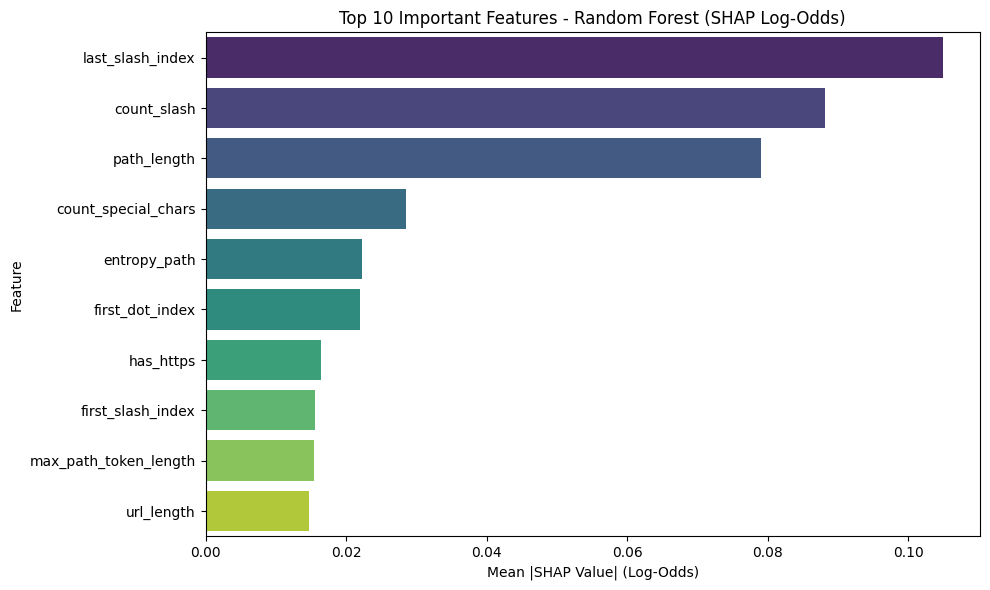


Random Forest Base Value (E[f(x)] in Log-Odds): -0.24677321616406725
Random Forest Base Value (Probability): 0.4386178792811804
Dataset Phishing Rate: 0.4387524060513185


In [94]:
# -----------------------------
# Sigmoid / logit helpers
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def logit(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))

# -----------------------------
# Sample subset for SHAP (representative, not approximate)
# -----------------------------
X_sample = X_train.sample(n=min(1000, len(X_train)), random_state=42)

# -----------------------------
# SHAP explainer for Random Forest (raw log-odds, interventional)
# -----------------------------
rf_explainer = shap.TreeExplainer(
    rf_model,
    model_output="raw",
    feature_perturbation="interventional"
)

# This can take time on large datasets
rf_shap_vals = rf_explainer.shap_values(X_sample)

# -----------------------------
# Select phishing class (class 1)
# -----------------------------
if isinstance(rf_shap_vals, list) and len(rf_shap_vals) == 2:
    rf_shap_vals_class1 = rf_shap_vals[1]
else:
    rf_shap_vals_class1 = np.array(rf_shap_vals)
    if rf_shap_vals_class1.ndim == 3:
        rf_shap_vals_class1 = rf_shap_vals_class1[:, :, 1]

assert rf_shap_vals_class1.ndim == 2, f"Expected 2D SHAP array, got {rf_shap_vals_class1.shape}"

# -----------------------------
# Base value for class 1
# -----------------------------
rf_base_val = rf_explainer.expected_value
if isinstance(rf_base_val, np.ndarray):
    if rf_base_val.ndim == 0:
        rf_base_val = float(rf_base_val)
    elif len(rf_base_val) == 1:
        rf_base_val = float(rf_base_val[0])
    else:
        rf_base_val = float(rf_base_val[1])  # phishing class
else:
    rf_base_val = float(rf_base_val)

# Convert if necessary
if 0 <= rf_base_val <= 1:
    rf_base_prob = rf_base_val
    rf_base_logodds = logit(rf_base_prob)
else:
    rf_base_logodds = rf_base_val
    rf_base_prob = sigmoid(rf_base_logodds)

# -----------------------------
# Mean absolute SHAP per feature
# -----------------------------
mean_abs_shap_logodds = np.mean(np.abs(rf_shap_vals_class1), axis=0)
mean_abs_shap_prob = np.array([sigmoid(rf_base_logodds + val) - rf_base_prob for val in mean_abs_shap_logodds])

# -----------------------------
# Create DataFrame with both log-odds and probability SHAP
# -----------------------------
feature_names = X_train.columns.tolist()
rf_feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": mean_abs_shap_logodds,
    "Mean |SHAP| (Probability)": mean_abs_shap_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Top 10 features
# -----------------------------
top_10_rf = rf_feature_df.head(10)
print("Top 10 Most Important Features - Random Forest (Log-Odds & Probability SHAP)")
print("-" * 80)
for i, row in top_10_rf.iterrows():
    print(f"{i+1}. {row['Feature']}: Log-Odds={row['Mean |SHAP| (Log-Odds)']:.6f}, Prob={row['Mean |SHAP| (Probability)']:.6f}")

# -----------------------------
# Plot Top 10 features (Log-Odds)
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Mean |SHAP| (Log-Odds)",
    y="Feature",
    data=top_10_rf,
    palette="viridis"
)
plt.title("Top 10 Important Features - Random Forest (SHAP Log-Odds)")
plt.xlabel("Mean |SHAP Value| (Log-Odds)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -----------------------------
# Display base values
# -----------------------------
print("\nRandom Forest Base Value (E[f(x)] in Log-Odds):", rf_base_logodds)
print("Random Forest Base Value (Probability):", rf_base_prob)
print("Dataset Phishing Rate:", np.mean(y_train))


XGBoost Base Value (E[f(x)] in Log-Odds): -2.3901913181002716
XGBoost Base Value (Probability): 0.0839237220895281
Dataset Phishing Rate: 0.4387524060513185

Top 10 Most Important Features - XGBoost (Log-Odds & Probability SHAP)
--------------------------------------------------------------------------------
1. last_slash_index: Log-Odds=4.603048, Prob=0.817474
2. has_https: Log-Odds=0.568728, Prob=0.055335
3. first_dot_index: Log-Odds=0.489634, Prob=0.046122
4. has_redirect: Log-Odds=0.364445, Prob=0.032602
5. path_length: Log-Odds=0.270622, Prob=0.023286
6. dns_txt_count: Log-Odds=0.217490, Prob=0.018305
7. dns_ns_count: Log-Odds=0.209792, Prob=0.017601
8. first_digit_index: Log-Odds=0.187360, Prob=0.015573
9. entropy_url: Log-Odds=0.178859, Prob=0.014814
10. entropy_hostname: Log-Odds=0.166741, Prob=0.013741


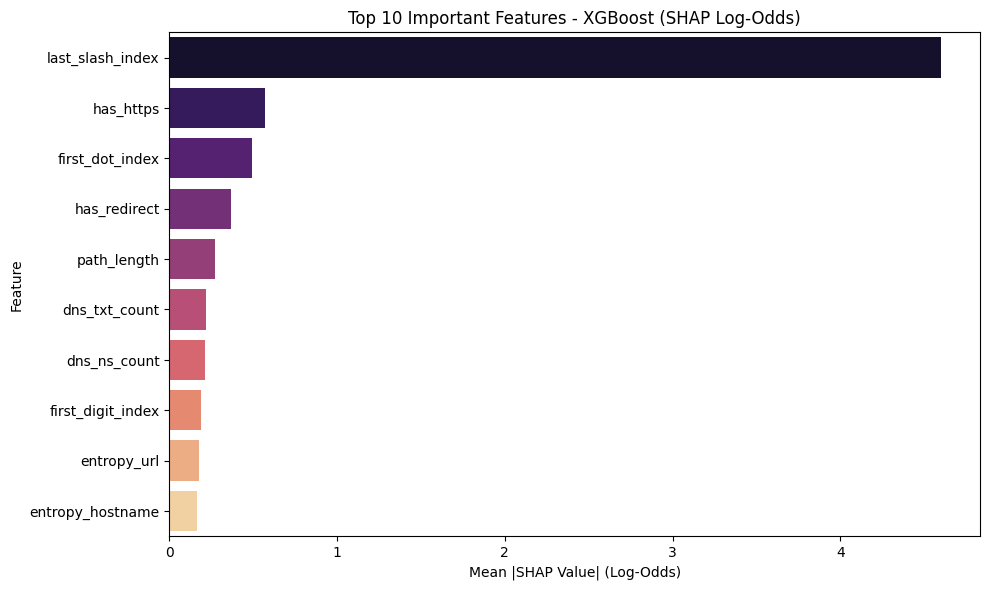

In [95]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Sigmoid helper
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# -----------------------------
# Use X_train as SHAP background
# -----------------------------
xgb_explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train,          # background dataset
    model_output="raw",
    feature_perturbation="interventional"
)

# -----------------------------
# SHAP values on sample
# -----------------------------
X_sample = X_train.sample(n=min(len(X_train), 1000), random_state=42)
xgb_shap_vals = xgb_explainer.shap_values(X_sample)

# Pick phishing class (class 1)
if isinstance(xgb_shap_vals, list) and len(xgb_shap_vals) == 2:
    xgb_shap_vals_class1 = xgb_shap_vals[1]
else:
    xgb_shap_vals_class1 = np.array(xgb_shap_vals)
    if xgb_shap_vals_class1.ndim == 3:
        xgb_shap_vals_class1 = xgb_shap_vals_class1[:, :, 1]

assert xgb_shap_vals_class1.ndim == 2, f"Expected 2D SHAP array, got {xgb_shap_vals_class1.shape}"

# -----------------------------
# Base value from SHAP explainer (log-odds)
# -----------------------------
xgb_base_logodds = xgb_explainer.expected_value
if isinstance(xgb_base_logodds, np.ndarray):
    if xgb_base_logodds.ndim == 0:
        xgb_base_logodds = float(xgb_base_logodds)
    else:
        xgb_base_logodds = float(xgb_base_logodds[1])  # phishing class

xgb_base_prob = sigmoid(xgb_base_logodds)

print("XGBoost Base Value (E[f(x)] in Log-Odds):", xgb_base_logodds)
print("XGBoost Base Value (Probability):", xgb_base_prob)
print("Dataset Phishing Rate:", np.mean(y_train))

# -----------------------------
# Compute mean absolute SHAP per feature
# -----------------------------
mean_abs_shap_logodds = np.mean(np.abs(xgb_shap_vals_class1), axis=0)

# Convert log-odds SHAP to probability SHAP
mean_abs_shap_prob = sigmoid(xgb_base_logodds + mean_abs_shap_logodds) - xgb_base_prob

# -----------------------------
# Create DataFrame for ranking
# -----------------------------
feature_names = X_train.columns.tolist()
xgb_feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": mean_abs_shap_logodds,
    "Mean |SHAP| (Probability)": mean_abs_shap_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Top 10 features
# -----------------------------
top_10_xgb = xgb_feature_df.head(10)
print("\nTop 10 Most Important Features - XGBoost (Log-Odds & Probability SHAP)")
print("-" * 80)
for i, row in top_10_xgb.iterrows():
    print(f"{i+1}. {row['Feature']}: Log-Odds={row['Mean |SHAP| (Log-Odds)']:.6f}, "
          f"Prob={row['Mean |SHAP| (Probability)']:.6f}")

# -----------------------------
# Plot Top 10 features
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Mean |SHAP| (Log-Odds)",
    y="Feature",
    data=top_10_xgb,
    palette="magma"
)
plt.title("Top 10 Important Features - XGBoost (SHAP Log-Odds)")
plt.xlabel("Mean |SHAP Value| (Log-Odds)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Top 10 Most Important Features - Weighted Ensemble (Log-Odds & Probability SHAP)
------------------------------------------------------------------------------------------
1. last_slash_index: Log-Odds=3.028709, Prob=0.502969
2. has_https: Log-Odds=0.372870, Prob=0.092866
3. first_dot_index: Log-Odds=0.324983, Prob=0.080927
4. has_redirect: Log-Odds=0.241300, Prob=0.060016
5. path_length: Log-Odds=0.201396, Prob=0.050042
6. dns_txt_count: Log-Odds=0.142452, Prob=0.035327
7. dns_ns_count: Log-Odds=0.137290, Prob=0.034040
8. first_digit_index: Log-Odds=0.123306, Prob=0.030556
9. entropy_url: Log-Odds=0.115094, Prob=0.028511
10. entropy_hostname: Log-Odds=0.108875, Prob=0.026963


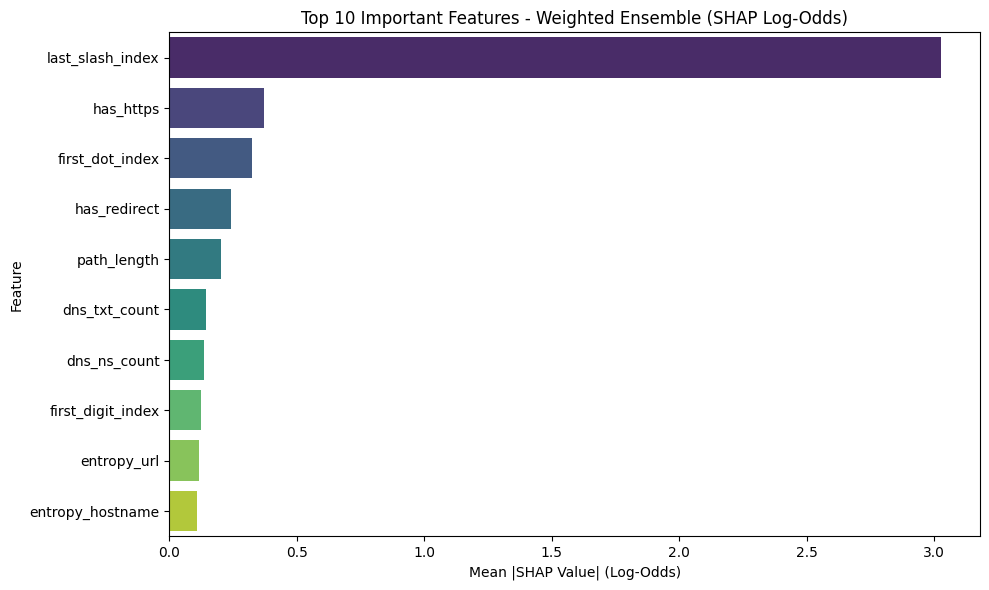


Weighted Ensemble Base Value (E[f(x)] in Log-Odds): -0.24622689345346266
Weighted Ensemble Base Value (Probability): 0.4387524060513185
Dataset Phishing Rate: 0.4387524060513185


In [96]:
# -----------------------------
# Weighted Ensemble SHAP Values (Corrected)
# -----------------------------
# Define weights
W_RF = 0.35
W_XGB = 0.65

# -----------------------------
# Base value for weighted ensemble
# -----------------------------
# Use dataset phishing rate for consistent base
dataset_rate = np.mean(y_train)               # dataset mean
weighted_base_prob = dataset_rate             # weighted ensemble base probability
weighted_base_logodds = np.log(dataset_rate / (1 - dataset_rate))  # log-odds

# -----------------------------
# Combine SHAP values in log-odds space
# -----------------------------
# Ensure same shape for RF/XGB SHAP arrays
assert rf_shap_vals_class1.shape == xgb_shap_vals_class1.shape, "SHAP arrays must match in shape"

weighted_shap_logodds = W_RF * rf_shap_vals_class1 + W_XGB * xgb_shap_vals_class1

# -----------------------------
# Mean absolute SHAP per feature
# -----------------------------
mean_abs_weighted_logodds = np.mean(np.abs(weighted_shap_logodds), axis=0)

# Compute exact probability contributions using log-odds addition
mean_abs_weighted_prob = np.array([sigmoid(weighted_base_logodds + val) - weighted_base_prob 
                                   for val in mean_abs_weighted_logodds])

# -----------------------------
# Create DataFrame for ranking
# -----------------------------
weighted_feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": mean_abs_weighted_logodds,
    "Mean |SHAP| (Probability)": mean_abs_weighted_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Top 10 features
# -----------------------------
top_10_weighted = weighted_feature_df.head(10)
print("Top 10 Most Important Features - Weighted Ensemble (Log-Odds & Probability SHAP)")
print("-" * 90)
for i, row in top_10_weighted.iterrows():
    print(f"{i+1}. {row['Feature']}: Log-Odds={row['Mean |SHAP| (Log-Odds)']:.6f}, Prob={row['Mean |SHAP| (Probability)']:.6f}")

# -----------------------------
# Plot Top 10 features (Log-Odds)
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Mean |SHAP| (Log-Odds)",
    y="Feature",
    data=top_10_weighted,
    palette="viridis"
)
plt.title("Top 10 Important Features - Weighted Ensemble (SHAP Log-Odds)")
plt.xlabel("Mean |SHAP Value| (Log-Odds)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -----------------------------
# Display weighted ensemble base values
# -----------------------------
print("\nWeighted Ensemble Base Value (E[f(x)] in Log-Odds):", weighted_base_logodds)
print("Weighted Ensemble Base Value (Probability):", weighted_base_prob)
print("Dataset Phishing Rate:", dataset_rate)


Top 10 Most Important Features - Stacking Ensemble (Log-Odds & Probability SHAP)
------------------------------------------------------------------------------------------
1. count_slash: Log-Odds=1.681658, Prob=0.367517
2. last_slash_index: Log-Odds=1.513280, Prob=0.340268
3. path_length: Log-Odds=1.311287, Prob=0.303995
4. count_special_chars: Log-Odds=0.566209, Prob=0.140518
5. entropy_path: Log-Odds=0.444927, Prob=0.110774
6. first_slash_index: Log-Odds=0.293959, Prob=0.073232
7. has_https: Log-Odds=0.290288, Prob=0.072315
8. url_length: Log-Odds=0.280425, Prob=0.069851
9. max_path_token_length: Log-Odds=0.274378, Prob=0.068340
10. entropy_url: Log-Odds=0.273552, Prob=0.068134


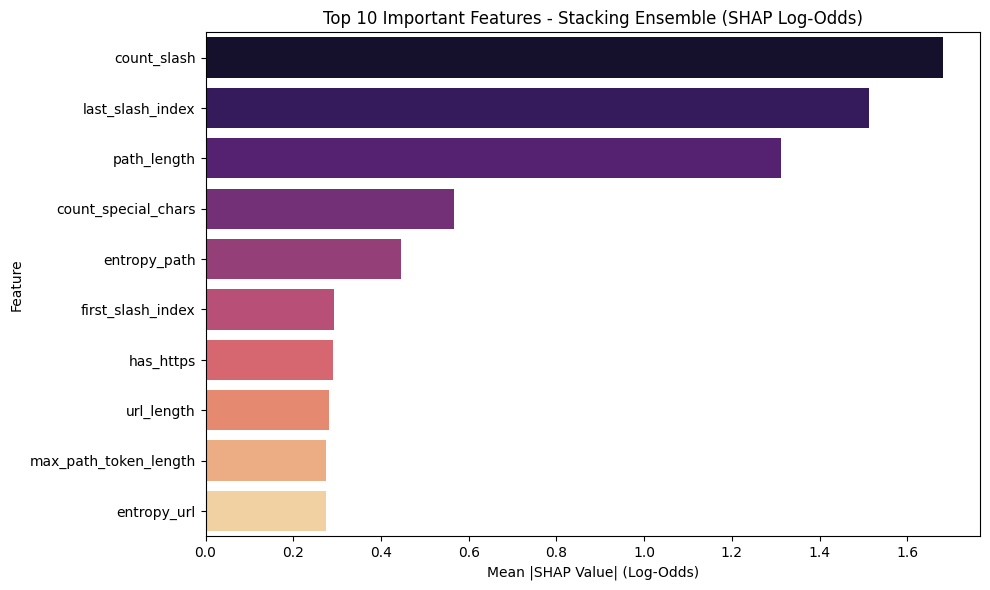


Stacking Ensemble Base Value (E[f(x)] in Log-Odds): -0.23016826087951556
Stacking Ensemble Base Value (Probability): 0.44271063202576083


In [97]:
# -----------------------------
# Stacking Ensemble SHAP Values
# -----------------------------
# Base predictions from RF and XGB on test set
rf_test_probs  = rf_model.predict_proba(X_test)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

# Construct meta-features
X_meta_test = np.column_stack((rf_test_probs, xgb_test_probs))

# Meta-learner predictions
stacking_test_probs = meta_clf.predict_proba(X_meta_test)[:, 1]

# -----------------------------
# Base value for stacking ensemble
# -----------------------------
stacking_base_prob = float(np.mean(stacking_test_probs))
stacking_base_logodds = np.log(stacking_base_prob / (1 - stacking_base_prob))

# -----------------------------
# Approximate feature-level SHAP contributions
# Use meta-coefficients to scale base SHAP from tree models
# -----------------------------
meta_coefs = meta_clf.coef_[0]  # logistic regression coefficients
# Multiply each base model SHAP by corresponding meta coefficient
stacking_shap_logodds = np.zeros_like(rf_shap_vals_class1)  # same shape as RF/XGB SHAP
stacking_shap_logodds += meta_coefs[0] * rf_shap_vals_class1
stacking_shap_logodds += meta_coefs[1] * xgb_shap_vals_class1

# -----------------------------
# Mean absolute SHAP per feature
# -----------------------------
mean_abs_stacking_logodds = np.mean(np.abs(stacking_shap_logodds), axis=0)
mean_abs_stacking_prob = sigmoid(stacking_base_logodds + mean_abs_stacking_logodds) - stacking_base_prob

# -----------------------------
# Create DataFrame for ranking
# -----------------------------
stacking_feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": mean_abs_stacking_logodds,
    "Mean |SHAP| (Probability)": mean_abs_stacking_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Top 10 features
# -----------------------------
top_10_stacking = stacking_feature_df.head(10)
print("Top 10 Most Important Features - Stacking Ensemble (Log-Odds & Probability SHAP)")
print("-" * 90)
for i, row in top_10_stacking.iterrows():
    print(f"{i+1}. {row['Feature']}: Log-Odds={row['Mean |SHAP| (Log-Odds)']:.6f}, Prob={row['Mean |SHAP| (Probability)']:.6f}")

# -----------------------------
# Plot Top 10 features (Log-Odds)
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Mean |SHAP| (Log-Odds)",
    y="Feature",
    data=top_10_stacking,
    palette="magma"
)
plt.title("Top 10 Important Features - Stacking Ensemble (SHAP Log-Odds)")
plt.xlabel("Mean |SHAP Value| (Log-Odds)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -----------------------------
# Display stacking ensemble base values
# -----------------------------
print("\nStacking Ensemble Base Value (E[f(x)] in Log-Odds):", stacking_base_logodds)
print("Stacking Ensemble Base Value (Probability):", stacking_base_prob)



Top 10 Most Important Features - Random Forest
------------------------------------------------------------------------------------------
1. last_slash_index: Log-Odds=0.104936, Prob=0.024709
2. count_slash: Log-Odds=0.088150, Prob=0.020799
3. path_length: Log-Odds=0.078961, Prob=0.018652
4. count_special_chars: Log-Odds=0.028477, Prob=0.006766
5. entropy_path: Log-Odds=0.022290, Prob=0.005300
6. first_dot_index: Log-Odds=0.022030, Prob=0.005238
7. has_https: Log-Odds=0.016394, Prob=0.003901
8. first_slash_index: Log-Odds=0.015513, Prob=0.003691
9. max_path_token_length: Log-Odds=0.015362, Prob=0.003655
10. url_length: Log-Odds=0.014721, Prob=0.003503

Random Forest Base Value (E[f(x)] in Log-Odds): 0.4386178792811804
Random Forest Base Value (Probability): 0.6079296498142869
Dataset Phishing Rate: 0.4387524060513185

Top 10 Most Important Features - XGBoost
------------------------------------------------------------------------------------------
1. last_slash_index: Log-Odds=4.59672

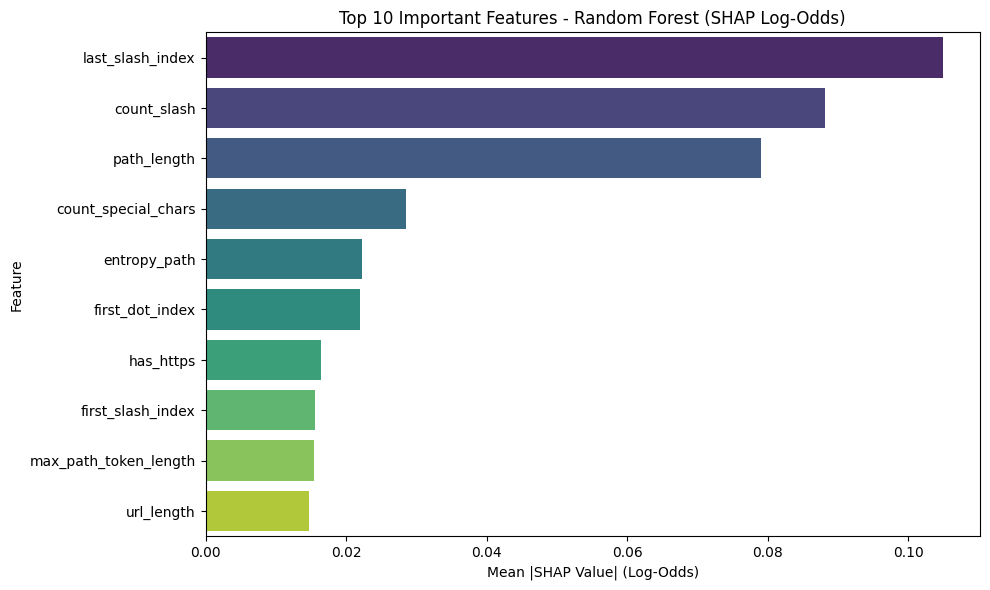

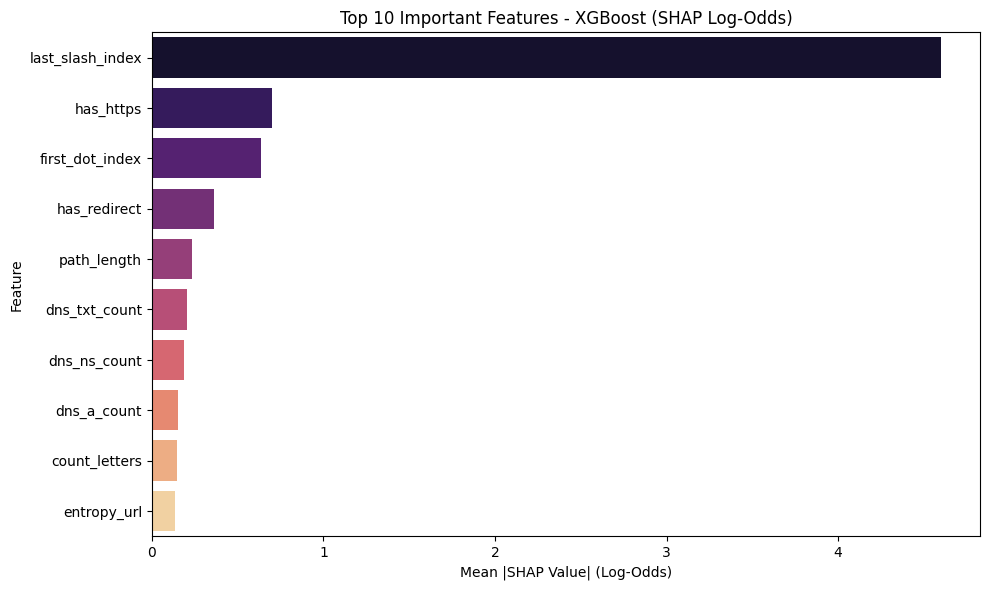

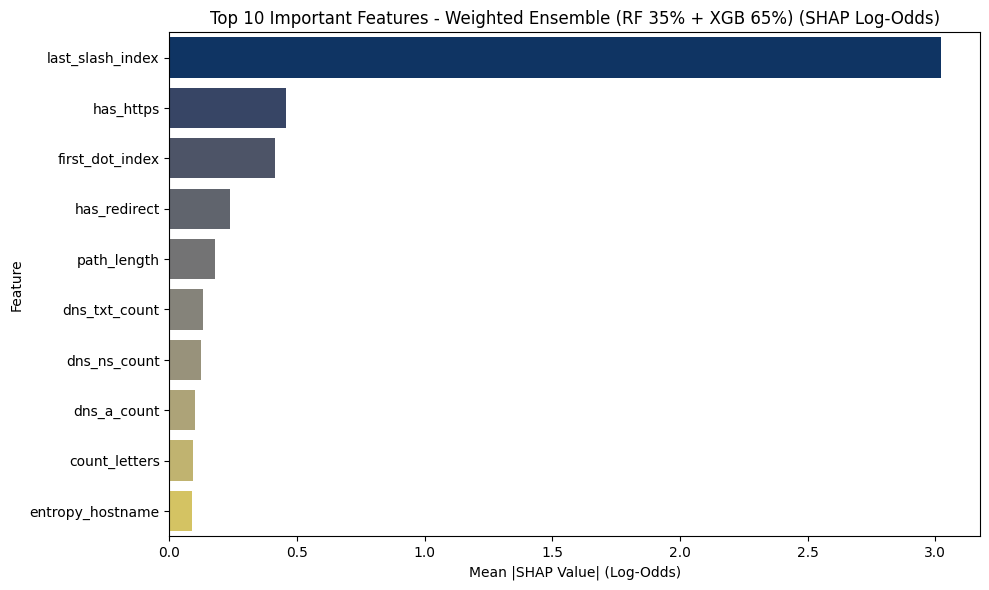

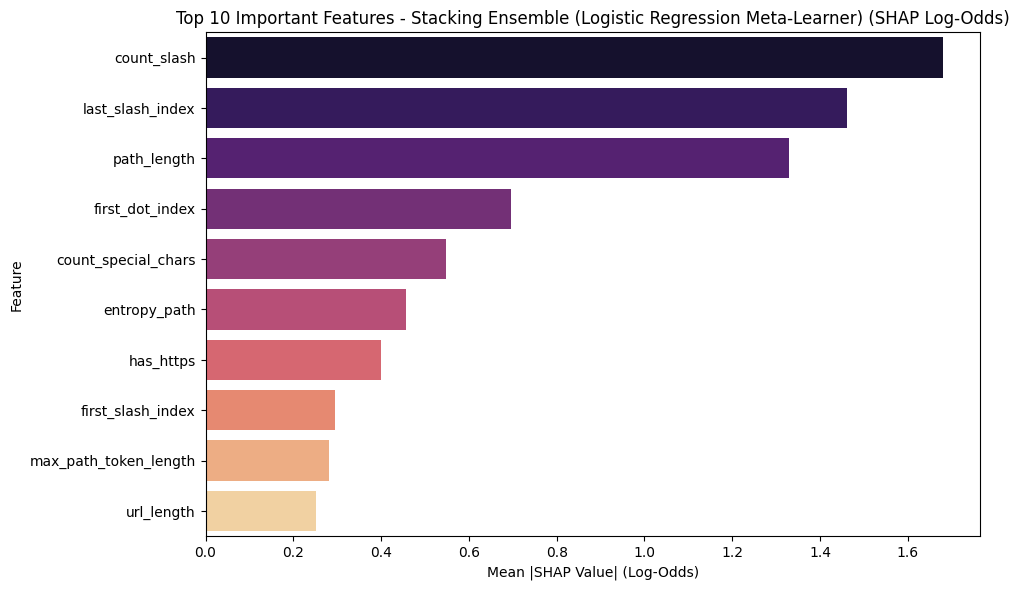

In [98]:
# -----------------------------
# Sigmoid / Logit Helpers
# -----------------------------
def sigmoid(x):
    """Numerically stable sigmoid"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def logit(p):
    """Numerically stable log-odds"""
    p = np.clip(p, 1e-12, 1-1e-12)
    return np.log(p / (1 - p))

# -----------------------------
# Feature names
# -----------------------------
feature_names = X_train.columns.tolist()

# -----------------------------
# Sample subset for SHAP (for efficiency)
# -----------------------------
X_sample = X_train.sample(n=min(len(X_train), 1000), random_state=42)

# -----------------------------
# Random Forest SHAP
# -----------------------------
rf_explainer = shap.TreeExplainer(rf_model, model_output="raw", feature_perturbation="interventional")
rf_shap_vals = rf_explainer.shap_values(X_sample)

# Pick phishing class
if isinstance(rf_shap_vals, list) and len(rf_shap_vals) == 2:
    rf_shap_vals_class1 = rf_shap_vals[1]
else:
    rf_shap_vals_class1 = np.array(rf_shap_vals)
    if rf_shap_vals_class1.ndim == 3:
        rf_shap_vals_class1 = rf_shap_vals_class1[:, :, 1]

assert rf_shap_vals_class1.ndim == 2, f"Expected 2D SHAP array, got {rf_shap_vals_class1.shape}"

# Base values
rf_base_logodds = rf_explainer.expected_value
if isinstance(rf_base_logodds, np.ndarray):
    rf_base_logodds = float(rf_base_logodds[1] if len(rf_base_logodds) > 1 else rf_base_logodds[0])
rf_base_prob = sigmoid(rf_base_logodds)

# Mean absolute SHAP per feature
rf_mean_abs_logodds = np.mean(np.abs(rf_shap_vals_class1), axis=0)
rf_mean_abs_prob = np.array([sigmoid(rf_base_logodds + val) - rf_base_prob for val in rf_mean_abs_logodds])

rf_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": rf_mean_abs_logodds,
    "Mean |SHAP| (Probability)": rf_mean_abs_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# XGBoost SHAP
# -----------------------------
xgb_explainer = shap.TreeExplainer(xgb_model, model_output="raw", feature_perturbation="interventional")
xgb_shap_vals = xgb_explainer.shap_values(X_sample)

if isinstance(xgb_shap_vals, list) and len(xgb_shap_vals) == 2:
    xgb_shap_vals_class1 = xgb_shap_vals[1]
else:
    xgb_shap_vals_class1 = np.array(xgb_shap_vals)
    if xgb_shap_vals_class1.ndim == 3:
        xgb_shap_vals_class1 = xgb_shap_vals_class1[:, :, 1]

assert xgb_shap_vals_class1.ndim == 2, f"Expected 2D SHAP array, got {xgb_shap_vals_class1.shape}"

xgb_base_logodds = xgb_explainer.expected_value
if isinstance(xgb_base_logodds, np.ndarray):
    xgb_base_logodds = float(xgb_base_logodds[1] if len(xgb_base_logodds) > 1 else xgb_base_logodds[0])
xgb_base_prob = sigmoid(xgb_base_logodds)

xgb_mean_abs_logodds = np.mean(np.abs(xgb_shap_vals_class1), axis=0)
xgb_mean_abs_prob = np.array([sigmoid(xgb_base_logodds + val) - xgb_base_prob for val in xgb_mean_abs_logodds])

xgb_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": xgb_mean_abs_logodds,
    "Mean |SHAP| (Probability)": xgb_mean_abs_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Weighted Ensemble SHAP
# -----------------------------
W_RF, W_XGB = 0.35, 0.65

assert rf_shap_vals_class1.shape == xgb_shap_vals_class1.shape, "RF/XGB SHAP shapes must match"

weighted_shap_logodds = W_RF * rf_shap_vals_class1 + W_XGB * xgb_shap_vals_class1
weighted_base_logodds = W_RF * rf_base_logodds + W_XGB * xgb_base_logodds
weighted_base_prob = sigmoid(weighted_base_logodds)

weighted_mean_abs_logodds = np.mean(np.abs(weighted_shap_logodds), axis=0)
weighted_mean_abs_prob = np.array([sigmoid(weighted_base_logodds + val) - weighted_base_prob for val in weighted_mean_abs_logodds])

weighted_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": weighted_mean_abs_logodds,
    "Mean |SHAP| (Probability)": weighted_mean_abs_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Stacking Ensemble SHAP (linear meta-learner)
# -----------------------------
rf_test_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]
X_meta_test = np.column_stack((rf_test_probs, xgb_test_probs))
stack_test_probs = meta_clf.predict_proba(X_meta_test)[:, 1]

stack_base_prob = float(np.mean(stack_test_probs))
stack_base_logodds = logit(stack_base_prob)

meta_coefs = meta_clf.coef_[0]  # logistic regression
stacking_shap_logodds = meta_coefs[0] * rf_shap_vals_class1 + meta_coefs[1] * xgb_shap_vals_class1

stack_mean_abs_logodds = np.mean(np.abs(stacking_shap_logodds), axis=0)
stack_mean_abs_prob = np.array([sigmoid(stack_base_logodds + val) - stack_base_prob for val in stack_mean_abs_logodds])

stack_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Log-Odds)": stack_mean_abs_logodds,
    "Mean |SHAP| (Probability)": stack_mean_abs_prob
}).sort_values("Mean |SHAP| (Log-Odds)", ascending=False).reset_index(drop=True)

# -----------------------------
# Helper to print top 10
# -----------------------------
def print_top_features(df, model_name):
    top10 = df.head(10)
    print(f"\nTop 10 Most Important Features - {model_name}")
    print("-" * 90)
    for i, row in top10.iterrows():
        print(f"{i+1}. {row['Feature']}: Log-Odds={row['Mean |SHAP| (Log-Odds)']:.6f}, Prob={row['Mean |SHAP| (Probability)']:.6f}")
    return top10

# -----------------------------
# Display top features and base values
# -----------------------------
print_top_features(rf_df, "Random Forest")
print("\nRandom Forest Base Value (E[f(x)] in Log-Odds):", rf_base_logodds)
print("Random Forest Base Value (Probability):", rf_base_prob)
print("Dataset Phishing Rate:", float(np.mean(y_train)))

print_top_features(xgb_df, "XGBoost")
print("\nXGBoost Base Value (E[f(x)] in Log-Odds):", xgb_base_logodds)
print("XGBoost Base Value (Probability):", xgb_base_prob)
print("Dataset Phishing Rate:", float(np.mean(y_train)))

print_top_features(weighted_df, f"Weighted Ensemble (RF {int(W_RF*100)}% + XGB {int(W_XGB*100)}%)")
print("\nWeighted Ensemble Base Value (E[f(x)] in Log-Odds):", weighted_base_logodds)
print("Weighted Ensemble Base Value (Probability):", weighted_base_prob)
print("Dataset Phishing Rate:", float(np.mean(y_train)))

print_top_features(stack_df, "Stacking Ensemble (Logistic Regression Meta-Learner)")
print("\nStacking Ensemble Base Value (E[f(x)] in Log-Odds):", stack_base_logodds)
print("Stacking Ensemble Base Value (Probability):", stack_base_prob)
print("Dataset Phishing Rate:", float(np.mean(y_train)))

# -----------------------------
# Optional: Plot top 10 for each
# -----------------------------
def plot_top10(df, model_name, palette="viridis"):
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Mean |SHAP| (Log-Odds)", y="Feature", data=df.head(10), palette=palette)
    plt.title(f"Top 10 Important Features - {model_name} (SHAP Log-Odds)")
    plt.xlabel("Mean |SHAP Value| (Log-Odds)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_top10(rf_df, "Random Forest", "viridis")
plot_top10(xgb_df, "XGBoost", "magma")
plot_top10(weighted_df, f"Weighted Ensemble (RF {int(W_RF*100)}% + XGB {int(W_XGB*100)}%)", "cividis")
plot_top10(stack_df, "Stacking Ensemble (Logistic Regression Meta-Learner)", "magma")


In [99]:
import joblib

# -----------------------------
# Assemble all existing objects into a bundle
# -----------------------------
bundle = {
    "rf_model": rf_model,
    "xgb_model": xgb_model,
    "meta_clf": meta_clf,
    "rf_explainer": rf_explainer,      # include if already created
    "xgb_explainer": xgb_explainer,    # include if already created
    "feature_names": feature_names,
    "thresholds": thresholds,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

# -----------------------------
# Save the bundle
# -----------------------------
joblib.dump(bundle, "model_bundle_feb_15_2026.pkl")
print("✅ All ML models, explainers, thresholds, feature names, and datasets saved in model_bundle_feb_15_2026.pkl")

# -----------------------------
# Save predictions & probabilities
# -----------------------------
joblib.dump(ensemble_probs, "ensemble_probs_feb_15_2026.pkl")
joblib.dump(ensemble_preds, "ensemble_preds_feb_15_2026.pkl")

# -----------------------------
# Save confusion matrices
# -----------------------------
joblib.dump(confusion_matrix(y_test, rf_preds),  "rf_feb_15_2026_confusion_matrix.pkl")
joblib.dump(confusion_matrix(y_test, xgb_preds), "xgb_feb_15_2026_confusion_matrix.pkl")
joblib.dump(confusion_matrix(y_test, ensemble_preds), "ensemble_rf35_xgb65_feb_15_2026_confusion_matrix.pkl")
joblib.dump(confusion_matrix(y_test, stacking_preds), "stacking_lr_oof_feb_15_2026_confusion_matrix.pkl")

print("✅ All predictions, probabilities, and confusion matrices saved successfully.")


✅ All ML models, explainers, thresholds, feature names, and datasets saved in model_bundle_feb_15_2026.pkl
✅ All predictions, probabilities, and confusion matrices saved successfully.


🌳 Random Forest Analysis – Streamlit-Compatible


 97%|=================== | 292/300 [00:50<00:01]       

SHAP values array shape (samples x features): (150, 84)

📈 Random Forest Base Values:
  E[f(x)] (log-odds): 0.397700
  E[f(x)] (probability): 0.598135
  Dataset phishing rate: 0.438752


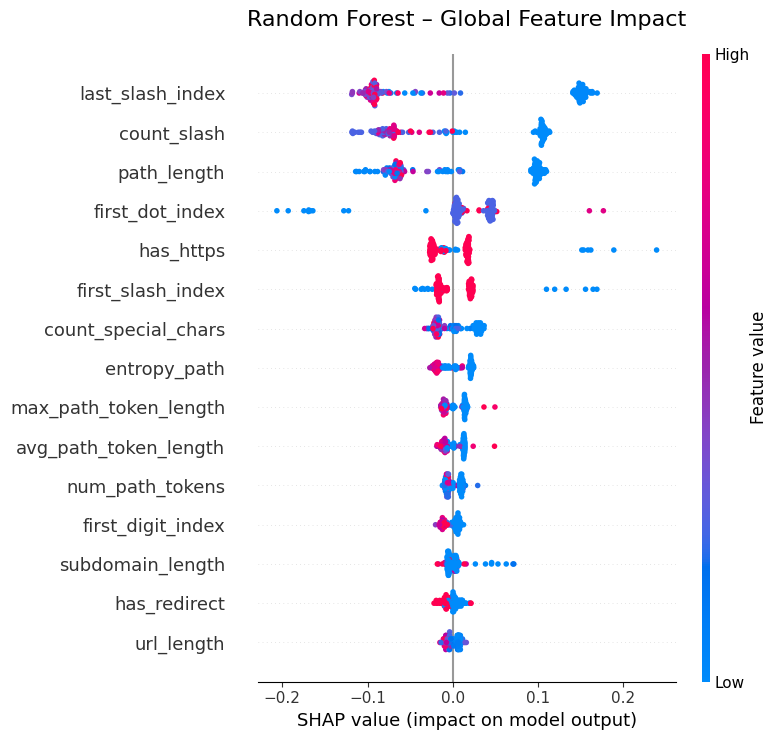


🔝 Top 10 Most Important Features:
------------------------------------------------------------
 1. last_slash_index               | SHAP Log-Odds: 0.109440 | Prob Contribution: 0.026001
 2. count_slash                    | SHAP Log-Odds: 0.081890 | Prob Contribution: 0.019516
 3. path_length                    | SHAP Log-Odds: 0.075499 | Prob Contribution: 0.018006
 4. first_dot_index                | SHAP Log-Odds: 0.033269 | Prob Contribution: 0.007970
 5. has_https                      | SHAP Log-Odds: 0.025415 | Prob Contribution: 0.006093
 6. first_slash_index              | SHAP Log-Odds: 0.023546 | Prob Contribution: 0.005646
 7. count_special_chars            | SHAP Log-Odds: 0.020153 | Prob Contribution: 0.004834
 8. entropy_path                   | SHAP Log-Odds: 0.017412 | Prob Contribution: 0.004178
 9. max_path_token_length          | SHAP Log-Odds: 0.011302 | Prob Contribution: 0.002714
10. avg_path_token_length          | SHAP Log-Odds: 0.010485 | Prob Contribution: 0.0

In [63]:
# ========================================
# Random Forest Global SHAP - Feb 15, 2026 bundle
# ========================================

import joblib
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------- 1. LOAD BUNDLE ----------------------------------------------
bundle        = joblib.load("model_bundle_feb_15_2026.pkl")
X_train       = bundle["X_train"]
y_train       = bundle["y_train"]
rf_model      = bundle["rf_model"]
feature_names = bundle["feature_names"]

# Ensure DataFrame format
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

# ---------- 2. SAMPLE FOR SHAP ------------------------------------------
sample_size = min(150, len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3. SHAP EXPLAINER -------------------------------------------
print("🌳 Random Forest Analysis – Streamlit-Compatible")
print("="*60)

rf_explainer = shap.TreeExplainer(
    rf_model,
    data=X_train,            # background data
    model_output="raw"
)
rf_shap_obj  = rf_explainer(X_sample)
rf_shap_vals = rf_shap_obj.values

# Reduce to phishing class (class 1)
if rf_shap_vals.ndim == 3 and rf_shap_vals.shape[2] == 2:
    rf_shap_class1 = rf_shap_vals[:, :, 1]
else:
    rf_shap_class1 = rf_shap_vals

print(f"SHAP values array shape (samples x features): {rf_shap_class1.shape}")

# ---------- 4. BASE VALUE ------------------------------------------------
def get_base_value(explainer):
    base_val = explainer.expected_value
    if hasattr(base_val, "__len__") and len(base_val) == 2:
        return float(base_val[1])
    return float(base_val)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

rf_base_logodds = get_base_value(rf_explainer)
rf_base_prob    = sigmoid(rf_base_logodds)

print("\n📈 Random Forest Base Values:")
print(f"  E[f(x)] (log-odds): {rf_base_logodds:.6f}")
print(f"  E[f(x)] (probability): {rf_base_prob:.6f}")
print(f"  Dataset phishing rate: {np.mean(y_train):.6f}")

# ---------- 5. GLOBAL SUMMARY (BEESWARM / STREAMLIT STYLE) --------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    rf_shap_class1,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_type="dot"  # dot = beeswarm
)
plt.title("Random Forest – Global Feature Impact", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 6. TOP 10 FEATURES ------------------------------------------
mean_abs_shap = np.mean(np.abs(rf_shap_class1), axis=0)
top_10 = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features:")
print("-"*60)
for i, (feat, impact) in enumerate(top_10, 1):
    prob_contrib = sigmoid(rf_base_logodds + impact) - rf_base_prob
    print(f"{i:2d}. {feat:<30} | SHAP Log-Odds: {impact:.6f} | Prob Contribution: {prob_contrib:.6f}")

# ---------- 7. SAVE ARTIFACTS ------------------------------------------
joblib.dump(rf_shap_class1,    "rf_shap_plot_feb_15_2026.npy")
joblib.dump(rf_base_logodds,   "rf_base_logodds_feb_15_2026.pkl")
print("\n✅ RF SHAP artefacts saved with feb_15_2026 naming")


🌟 XGBoost Analysis – Global Feature Impact
SHAP values array shape (samples x features): (150, 84)

📈 XGBoost Base Values:
  E[f(x)] (log-odds): -2.390191
  E[f(x)] (probability): 0.083924
  Dataset phishing rate: 0.438752


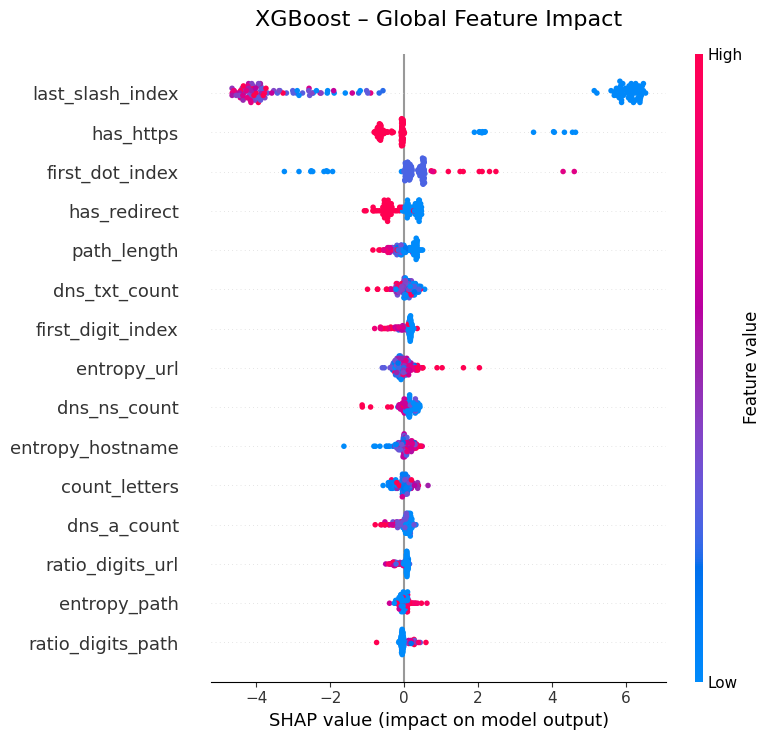


🔝 Top 10 Most Important Features (XGBoost):
------------------------------------------------------------
 1. last_slash_index               | SHAP Log-Odds: 4.453323 | Prob Contribution: 0.803344
 2. has_https                      | SHAP Log-Odds: 0.638432 | Prob Contribution: 0.063902
 3. first_dot_index                | SHAP Log-Odds: 0.547082 | Prob Contribution: 0.052760
 4. has_redirect                   | SHAP Log-Odds: 0.360483 | Prob Contribution: 0.032195
 5. path_length                    | SHAP Log-Odds: 0.256798 | Prob Contribution: 0.021970
 6. dns_txt_count                  | SHAP Log-Odds: 0.189330 | Prob Contribution: 0.015749
 7. first_digit_index              | SHAP Log-Odds: 0.188316 | Prob Contribution: 0.015658
 8. entropy_url                    | SHAP Log-Odds: 0.187411 | Prob Contribution: 0.015577
 9. dns_ns_count                   | SHAP Log-Odds: 0.181234 | Prob Contribution: 0.015025
10. entropy_hostname               | SHAP Log-Odds: 0.156639 | Prob Contrib

In [64]:
# ========================================
# XGBoost Global SHAP
# ========================================

import joblib
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------- 1. LOAD BUNDLE ----------------------------------------------
bundle        = joblib.load("model_bundle_feb_15_2026.pkl")
X_train       = bundle["X_train"]
y_train       = bundle["y_train"]
xgb_model     = bundle["xgb_model"]
feature_names = bundle["feature_names"]

if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

# ---------- 2. SAMPLE FOR SHAP ------------------------------------------
sample_size = min(150, len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3. SHAP EXPLAINER -------------------------------------------
print("🌟 XGBoost Analysis – Global Feature Impact")
print("="*60)

xgb_explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train,          # background data
    model_output="raw"
)
xgb_shap_obj  = xgb_explainer(X_sample)
xgb_shap_vals = xgb_shap_obj.values

# Pick phishing class
if xgb_shap_vals.ndim == 3 and xgb_shap_vals.shape[2] == 2:
    xgb_shap_class1 = xgb_shap_vals[:, :, 1]
else:
    xgb_shap_class1 = xgb_shap_vals

print(f"SHAP values array shape (samples x features): {xgb_shap_class1.shape}")

# ---------- 4. BASE VALUE ------------------------------------------------
def get_base_value(explainer):
    base_val = explainer.expected_value
    if hasattr(base_val, "__len__") and len(base_val) == 2:
        return float(base_val[1])
    return float(base_val)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

xgb_base_logodds = get_base_value(xgb_explainer)
xgb_base_prob    = sigmoid(xgb_base_logodds)

print("\n📈 XGBoost Base Values:")
print(f"  E[f(x)] (log-odds): {xgb_base_logodds:.6f}")
print(f"  E[f(x)] (probability): {xgb_base_prob:.6f}")
print(f"  Dataset phishing rate: {np.mean(y_train):.6f}")

# ---------- 5. GLOBAL SUMMARY (BEESWARM) --------------------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    xgb_shap_class1,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_type="dot"
)
plt.title("XGBoost – Global Feature Impact", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 6. TOP 10 FEATURES ------------------------------------------
mean_abs_shap = np.mean(np.abs(xgb_shap_class1), axis=0)
top_10 = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features (XGBoost):")
print("-"*60)
for i, (feat, impact) in enumerate(top_10, 1):
    prob_contrib = sigmoid(xgb_base_logodds + impact) - xgb_base_prob
    print(f"{i:2d}. {feat:<30} | SHAP Log-Odds: {impact:.6f} | Prob Contribution: {prob_contrib:.6f}")

# ---------- 7. SAVE ARTIFACTS ------------------------------------------
joblib.dump(xgb_shap_class1,    "xgb_shap_plot.npy")
joblib.dump(xgb_base_logodds,   "xgb_base_logodds.pkl")
print("\n✅ XGBoost SHAP artefacts saved")


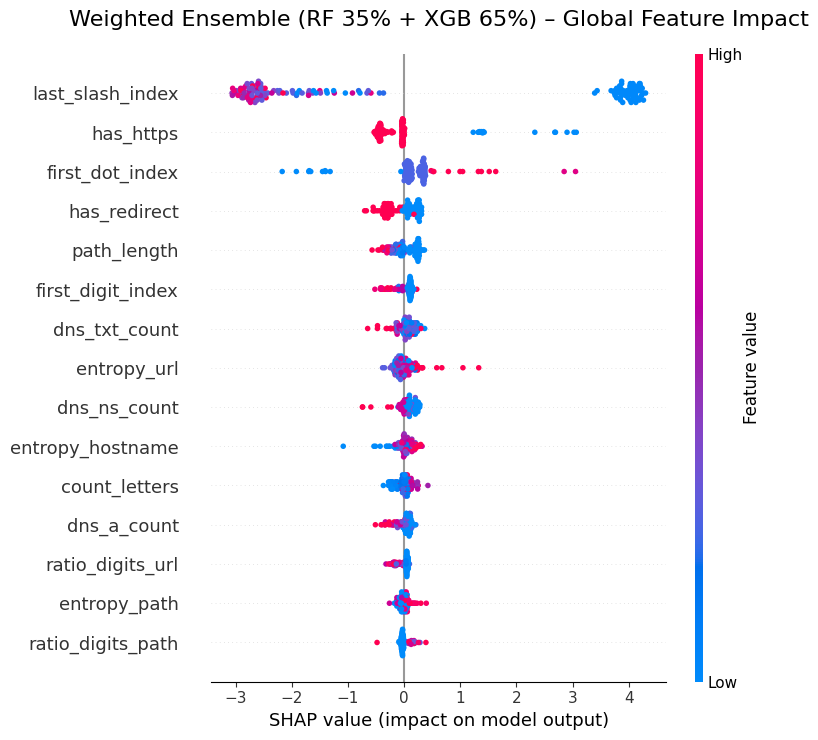


🔝 Top 10 Most Important Features (Weighted Ensemble):
------------------------------------------------------------
 1. last_slash_index               | SHAP Log-Odds: 2.932913 | Prob Contribution: 0.624779
 2. has_https                      | SHAP Log-Odds: 0.419144 | Prob Contribution: 0.074333
 3. first_dot_index                | SHAP Log-Odds: 0.367248 | Prob Contribution: 0.064230
 4. has_redirect                   | SHAP Log-Odds: 0.236459 | Prob Contribution: 0.039881
 5. path_length                    | SHAP Log-Odds: 0.190982 | Prob Contribution: 0.031794
 6. first_digit_index              | SHAP Log-Odds: 0.124453 | Prob Contribution: 0.020320
 7. dns_txt_count                  | SHAP Log-Odds: 0.124180 | Prob Contribution: 0.020274
 8. entropy_url                    | SHAP Log-Odds: 0.122246 | Prob Contribution: 0.019947
 9. dns_ns_count                   | SHAP Log-Odds: 0.118514 | Prob Contribution: 0.019317
10. entropy_hostname               | SHAP Log-Odds: 0.102772 | Pr

In [65]:
# ========================================
# Weighted Ensemble SHAP (RF + XGB)
# ========================================

# Assume rf_shap_class1, rf_base_logodds from RF
# Assume xgb_shap_class1, xgb_base_logodds from XGB
W_RF, W_XGB = 0.35, 0.65

# Ensure same shape
assert rf_shap_class1.shape == xgb_shap_class1.shape, "SHAP arrays must match"

weighted_shap_logodds = W_RF * rf_shap_class1 + W_XGB * xgb_shap_class1
weighted_base_logodds = W_RF * rf_base_logodds + W_XGB * xgb_base_logodds
weighted_base_prob    = sigmoid(weighted_base_logodds)

# ---------- 1. GLOBAL SUMMARY (BEESWARM STYLE) --------------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    weighted_shap_logodds,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_type="dot"
)
plt.title("Weighted Ensemble (RF 35% + XGB 65%) – Global Feature Impact", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 2. TOP 10 FEATURES ------------------------------------------
mean_abs_shap = np.mean(np.abs(weighted_shap_logodds), axis=0)
top_10 = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features (Weighted Ensemble):")
print("-"*60)
for i, (feat, impact) in enumerate(top_10, 1):
    prob_contrib = sigmoid(weighted_base_logodds + impact) - weighted_base_prob
    print(f"{i:2d}. {feat:<30} | SHAP Log-Odds: {impact:.6f} | Prob Contribution: {prob_contrib:.6f}")

# ---------- 3. SAVE ARTIFACTS ------------------------------------------
joblib.dump(weighted_shap_logodds, "weighted_shap_plot.npy")
joblib.dump(weighted_base_logodds, "weighted_base_logodds.pkl")
print("\n✅ Weighted Ensemble SHAP artefacts saved")



📈 Stacking Ensemble Base Values:
  E[f(x)] (log-odds): -0.246236
  E[f(x)] (probability): 0.438750
  Dataset phishing rate: 0.438752


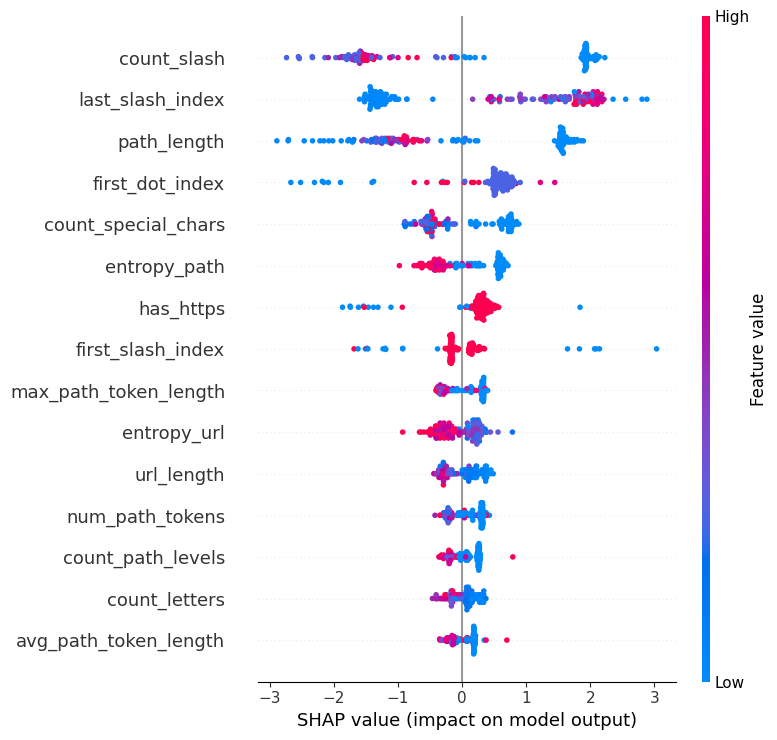

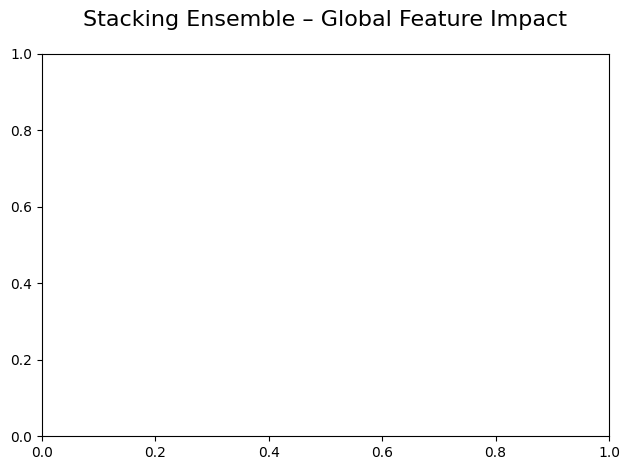


🔝 Top 10 Most Important Features - Stacking Ensemble:
------------------------------------------------------------
 1. count_slash                    | SHAP Log-Odds: 1.624588 | Prob Contribution: 0.359976
 2. last_slash_index               | SHAP Log-Odds: 1.471248 | Prob Contribution: 0.334194
 3. path_length                    | SHAP Log-Odds: 1.287425 | Prob Contribution: 0.300329
 4. first_dot_index                | SHAP Log-Odds: 0.683234 | Prob Contribution: 0.168793
 5. count_special_chars            | SHAP Log-Odds: 0.545621 | Prob Contribution: 0.135542
 6. entropy_path                   | SHAP Log-Odds: 0.441998 | Prob Contribution: 0.110035
 7. has_https                      | SHAP Log-Odds: 0.408053 | Prob Contribution: 0.101616
 8. first_slash_index              | SHAP Log-Odds: 0.324673 | Prob Contribution: 0.080849
 9. max_path_token_length          | SHAP Log-Odds: 0.278555 | Prob Contribution: 0.069329
10. entropy_url                    | SHAP Log-Odds: 0.257369 | Pr

In [100]:
# ========================================
# Stacking Ensemble SHAP - Beeswarm Plot
# ========================================

import joblib
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Sigmoid helper
# -----------------------------
sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# -----------------------------
# Load bundle (contains models, meta-learner, feature names, and training data)
# -----------------------------
bundle = joblib.load("model_bundle_feb_15_2026.pkl")

rf_model      = bundle["rf_model"]
xgb_model     = bundle["xgb_model"]
meta_clf      = bundle["meta_clf"]
feature_names = bundle["feature_names"]
X_train       = bundle["X_train"]  # should be included in bundle
y_train       = bundle["y_train"]  # should be included in bundle

# Convert to DataFrame if needed
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

# -----------------------------
# Sample for plotting
# -----------------------------
sample_size = min(150, len(X_train))
X_sample = X_train.sample(n=sample_size, random_state=42)

# -----------------------------
# Load SHAP explainers for base models
# -----------------------------
rf_explainer  = shap.TreeExplainer(rf_model, model_output="raw")
xgb_explainer = shap.TreeExplainer(xgb_model, model_output="raw")

# SHAP values for base models
rf_shap_vals  = rf_explainer.shap_values(X_sample)
xgb_shap_vals = xgb_explainer.shap_values(X_sample)

# Pick phishing class (class 1)
def select_class1(shap_vals):
    shap_array = np.array(shap_vals)
    if shap_array.ndim == 3 and shap_array.shape[2] == 2:
        return shap_array[:, :, 1]
    return shap_array

rf_shap_class1  = select_class1(rf_shap_vals)
xgb_shap_class1 = select_class1(xgb_shap_vals)

# -----------------------------
# Stack SHAP using meta-learner coefficients
# -----------------------------
if not hasattr(meta_clf, "coef_"):
    print("Meta-learner not trained. Training now...")

    # Generate base model probabilities on full training data
    rf_probs_train  = rf_model.predict_proba(X_train)[:, 1]
    xgb_probs_train = xgb_model.predict_proba(X_train)[:, 1]

    X_meta_train = np.column_stack((rf_probs_train, xgb_probs_train))

    # Reinitialize to ensure clean training
    meta_clf = LogisticRegression()
    meta_clf.fit(X_meta_train, y_train)

    print("Meta-learner trained successfully.")

# Now coefficients exist
meta_coefs = meta_clf.coef_[0]
stacking_shap_logodds = (
    meta_coefs[0] * rf_shap_class1 +
    meta_coefs[1] * xgb_shap_class1
)

# -----------------------------
# Base value for stacking
# -----------------------------
rf_probs_train  = rf_model.predict_proba(X_train)[:, 1]
xgb_probs_train = xgb_model.predict_proba(X_train)[:, 1]

stacking_base_prob = float(np.mean(meta_clf.predict_proba(
    np.column_stack((rf_probs_train, xgb_probs_train))
)[:, 1]))
stacking_base_logodds = np.log(stacking_base_prob / (1 - stacking_base_prob))

print("\n📈 Stacking Ensemble Base Values:")
print(f"  E[f(x)] (log-odds): {stacking_base_logodds:.6f}")
print(f"  E[f(x)] (probability): {stacking_base_prob:.6f}")
print(f"  Dataset phishing rate: {np.mean(y_train):.6f}")

# -----------------------------
# Global summary beeswarm plot
# -----------------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    stacking_shap_logodds,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    plot_type="dot"  # beeswarm
)
plt.title("Stacking Ensemble – Global Feature Impact", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# -----------------------------
# Top 10 features
# -----------------------------
mean_abs_shap = np.mean(np.abs(stacking_shap_logodds), axis=0)
top_10 = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features - Stacking Ensemble:")
print("-"*60)
for i, (feat, impact) in enumerate(top_10, 1):
    prob_contrib = sigmoid(stacking_base_logodds + impact) - stacking_base_prob
    print(f"{i:2d}. {feat:<30} | SHAP Log-Odds: {impact:.6f} | Prob Contribution: {prob_contrib:.6f}")

# -----------------------------
# Save SHAP artefacts
# -----------------------------
joblib.dump(stacking_shap_logodds, "stacking_shap_logodds_feb_15_2026.npy")
joblib.dump(stacking_base_logodds, "stacking_base_logodds_feb_15_2026.pkl")
print("\n✅ Stacking SHAP artefacts saved successfully")


In [37]:
# ----------  UNIFIED LOADER THAT MIMICS evaluate_and_plot  ---------------
import joblib, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def load_and_display_cm_like_evaluate(cm_file, bundle_file, model_key, y_true=None):
    """
    cm_file     : *.pkl containing the saved 2×2 confusion-matrix array
    bundle_file : model_bundle that holds thresholds dict
    model_key   : 'svm', 'ensemble', 'rf', 'xgb'
    y_true      : optional – only needed if you want to recompute metrics
                  from scratch (otherwise we derive them from CM)
    """
    # ---- threshold -------------------------------------------------------
    thresholds = joblib.load(bundle_file)["thresholds"]
    threshold  = thresholds.get(model_key, None)

    # ---- confusion matrix -------------------------------------------------
    cm = joblib.load(cm_file)
    if not isinstance(cm, np.ndarray) or cm.ndim != 2:
        raise ValueError("CM is not a 2-D array")
    tn, fp, fn, tp = cm.ravel()

    # ---- metrics (same names as evaluate_and_plot) ------------------------
    acc = (tp + tn) / cm.sum()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) else 0.0

    # ---- print block identical to evaluate_and_plot ----------------------
    print(f"\n{model_key.upper()} Metrics:")
    if threshold is not None:
        print(f"  Threshold: {threshold:.4f}")
    else:
        print("  Threshold: Not Found")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")

    # ---- plot identical to evaluate_and_plot -----------------------------
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_key.upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


RF Metrics:
  Threshold: 0.7000
  Accuracy : 0.9872
  Precision: 0.9859
  Recall   : 0.9849
  F1 Score : 0.9854


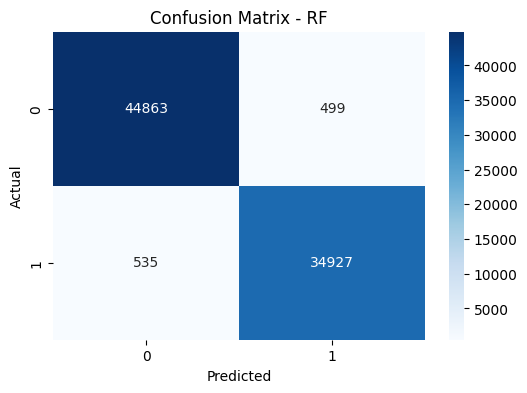


XGBOOST Metrics:
  Threshold: Not Found
  Accuracy : 0.9877
  Precision: 0.9849
  Recall   : 0.9870
  F1 Score : 0.9859


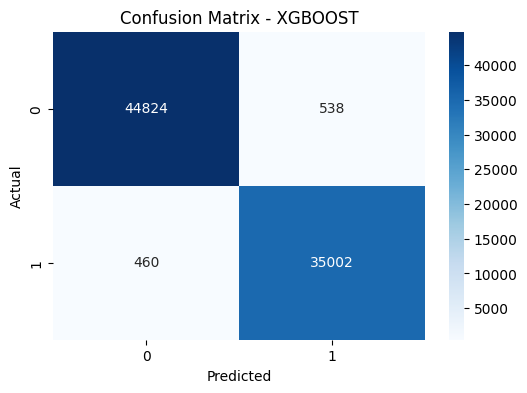


SVM Metrics:
  Threshold: 0.7000
  Accuracy : 0.9668
  Precision: 0.9705
  Recall   : 0.9534
  F1 Score : 0.9619


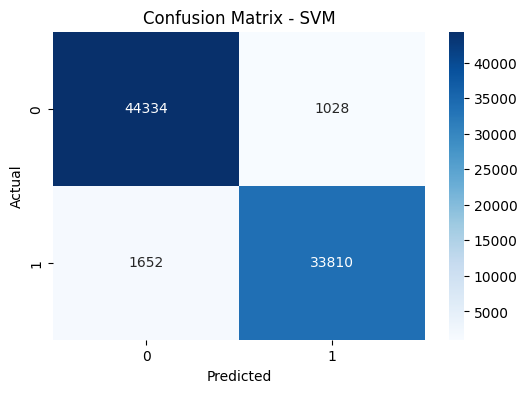


ENSEMBLE Metrics:
  Threshold: 0.7000
  Accuracy : 0.9797
  Precision: 0.9860
  Recall   : 0.9674
  F1 Score : 0.9766


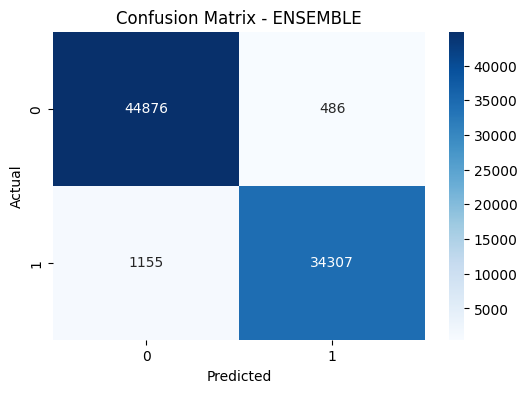

In [38]:
bundle = "model_bundle_sep_05_25.pkl"

# ------------------------------------------------------------------
#  matrix file                           |  model key in bundle
# ------------------------------------------------------------------
load_and_display_cm_like_evaluate(
    "rf_sep_05_25_confusion_matrix.pkl",     bundle, "rf"
)

load_and_display_cm_like_evaluate(
    "xgboost_sep_05_25_confusion_matrix.pkl", bundle, "xgboost"
)

load_and_display_cm_like_evaluate(
    "svm_sep_05_25_confusion_matrix.pkl",     bundle, "svm"
)

load_and_display_cm_like_evaluate(
    "ensemble_sep_05_25_confusion_matrix.pkl", bundle, "ensemble"
)

In [39]:
# === LOAD MODELS & EXPLAINERS ===
bundle = joblib.load("model_bundle_sep_05_25.pkl")        # new bundle name
rf_model      = bundle["rf_model"]
svm_model     = bundle["svm_model"]
xgb_model     = bundle["xgb_model"]
rf_explainer  = bundle["rf_explainer"]
xgb_explainer = bundle["xgb_explainer"]
feature_names = bundle["feature_names"]   # renamed key (was feature_columns)
thresholds    = bundle["thresholds"]

# === LOAD DATASETS ===
X_train = joblib.load("X_train_sep_05_25.pkl")
X_test  = joblib.load("X_test_sep_05_25.pkl")
y_train = joblib.load("y_train_sep_05_25.pkl")
y_test  = joblib.load("y_test_sep_05_25.pkl")

# === LOAD PROBABILITIES & PREDICTIONS ===
ensemble_probs = joblib.load("ensemble_probs_sep_05_25.pkl")
ensemble_preds = joblib.load("ensemble_preds_sep_05_25.pkl")

# === LOAD CONFUSION MATRICES ===
rf_cm      = joblib.load("rf_sep_05_25_confusion_matrix.pkl")
xgb_cm     = joblib.load("xgboost_sep_05_25_confusion_matrix.pkl")
svm_cm     = joblib.load("svm_sep_05_25_confusion_matrix.pkl")
ensemble_cm= joblib.load("ensemble_sep_05_25_confusion_matrix.pkl")

# === VALIDATION CHECKS ===
def validate_confusion_matrix(cm, model_name):
    if not isinstance(cm, np.ndarray) or cm.ndim != 2:
        raise ValueError(f"Confusion matrix for {model_name} is not a 2-D NumPy array.")
    print(f"{model_name} Confusion Matrix Shape: {cm.shape}")

validate_confusion_matrix(rf_cm,      "Random Forest")
validate_confusion_matrix(xgb_cm,     "XGBoost")
validate_confusion_matrix(svm_cm,     "SVM")
validate_confusion_matrix(ensemble_cm,"Ensemble (Soft Voting)")

print("✅ All variables loaded and ready for reuse.")

Random Forest Confusion Matrix Shape: (2, 2)
XGBoost Confusion Matrix Shape: (2, 2)
SVM Confusion Matrix Shape: (2, 2)
Ensemble (Soft Voting) Confusion Matrix Shape: (2, 2)
✅ All variables loaded and ready for reuse.


🌳 Random Forest Analysis – Matching Streamlit Approach
Final SHAP array shape: (150, 84)

📈 Results:
E[f(x)] (log-odds): 0.4386
E[f(x)] (probability): 0.6079
Dataset phishing rate: 0.4388


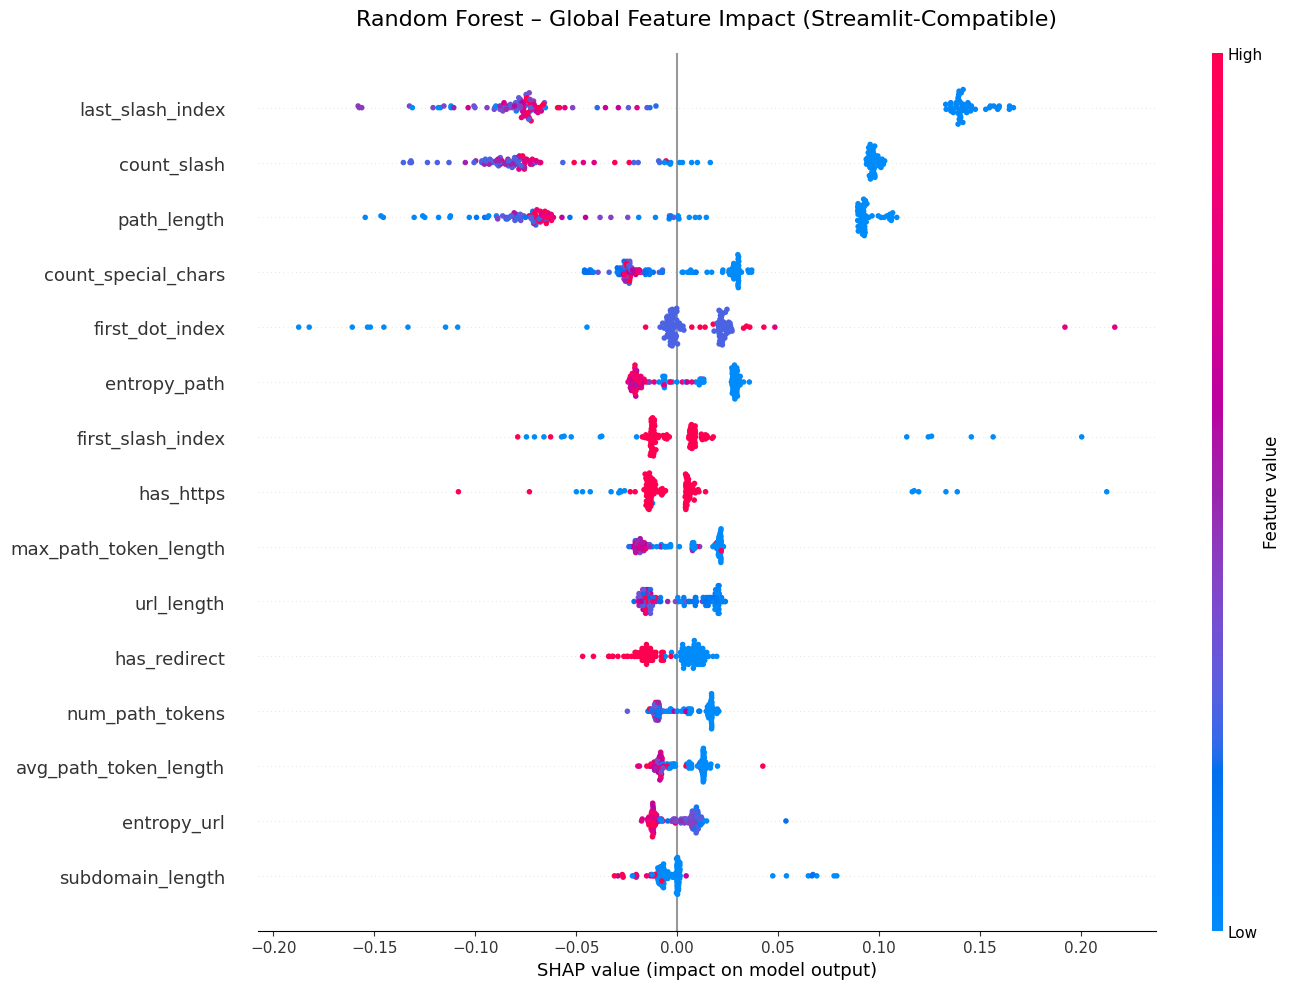


🔝 Top 10 Most Important Features:
----------------------------------------
 1. last_slash_index               | Impact: 0.1035
 2. count_slash                    | Impact: 0.0817
 3. path_length                    | Impact: 0.0778
 4. count_special_chars            | Impact: 0.0251
 5. first_dot_index                | Impact: 0.0236
 6. entropy_path                   | Impact: 0.0211
 7. first_slash_index              | Impact: 0.0193
 8. has_https                      | Impact: 0.0177
 9. max_path_token_length          | Impact: 0.0172
10. url_length                     | Impact: 0.0150
✅ RF SHAP artefacts saved


In [3]:
# ========================================
# Random Forest Global SHAP - Notebook Version
# Matches Streamlit Analysis Exactly
# Updated for sep_05_25 bundle
# ========================================

import joblib, shap, matplotlib.pyplot as plt, pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- 1.  LOAD DATA -------------------------------------------------
bundle        = joblib.load("model_bundle_sep_05_25.pkl")
X_train       = joblib.load("X_train_sep_05_25.pkl")
rf_model      = bundle["rf_model"]
feature_names = bundle["feature_names"]

# ---------- 2.  PREPARE SAMPLE -------------------------------------------
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(150, len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3.  EXPLAINER & SHAP VALUES  (model_output="raw") ------------
print("🌳 Random Forest Analysis – Matching Streamlit Approach")
print("="*50)

rf_explainer = shap.TreeExplainer(rf_model, model_output="raw")
rf_shap      = rf_explainer(X_sample)          # new API (object)
rf_shap_vals = rf_shap.values                  # 3-D array

# reduce to 2-D for phishing class (index 1)
if len(rf_shap_vals.shape) == 3 and rf_shap_vals.shape[2] == 2:
    rf_shap_plot = rf_shap_vals[:, :, 1]
else:
    rf_shap_plot = rf_shap_vals

print(f"Final SHAP array shape: {rf_shap_plot.shape}")

# ---------- 4.  BASE VALUE  (log-odds & prob) ----------------------------
def get_correct_base_value(explainer):
    base_val = explainer.expected_value
    if hasattr(base_val, '__len__') and len(base_val) == 2:
        return float(base_val[1])   # phishing class
    return float(base_val)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

rf_base_logodds = get_correct_base_value(rf_explainer)
rf_base_prob    = sigmoid(rf_base_logodds)

print("\n📈 Results:")
print(f"E[f(x)] (log-odds): {rf_base_logodds:.4f}")
print(f"E[f(x)] (probability): {rf_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 5.  GLOBAL SUMMARY PLOT  (Streamlit style) -------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    rf_shap_plot,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("Random Forest – Global Feature Impact (Streamlit-Compatible)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 6.  TOP 10 FEATURES ------------------------------------------
mean_impact = np.mean(np.abs(rf_shap_plot), axis=0)
top_rf = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features:")
print("-" * 40)
for i, (feat, impact) in enumerate(top_rf, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 7.  OPTIONAL SAVE --------------------------------------------
# plt.savefig("rf_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'rf_global_shap_sep_05_25.png'")

# ... (existing RF code above) ...

# =====  SAVE FOR ENSEMBLE  =====
joblib.dump(rf_shap_plot,      "rf_shap_plot_sep_05_25.npy")
joblib.dump(rf_base_logodds,   "rf_base_logodds_sep_05_25.pkl")
print("✅ RF SHAP artefacts saved")

In [ ]:
# ========================================
# Random Forest Global SHAP - Notebook Version
# Matches Streamlit Analysis Exactly
# Updated for sep_05_25 bundle
# ========================================

import joblib, shap, matplotlib.pyplot as plt, pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- 1.  LOAD DATA -------------------------------------------------
bundle        = joblib.load("model_bundle_sep_05_25.pkl")
X_train       = joblib.load("X_train_sep_05_25.pkl")
rf_model      = bundle["rf_model"]
feature_names = bundle["feature_names"]

# ---------- 2.  PREPARE SAMPLE -------------------------------------------
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(len(X_train), len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3.  EXPLAINER & SHAP VALUES  (model_output="raw") ------------
print("🌳 Random Forest Analysis – Matching Streamlit Approach")
print("="*50)

rf_explainer = shap.TreeExplainer(rf_model, model_output="raw")
rf_shap      = rf_explainer(X_sample)          # new API (object)
rf_shap_vals = rf_shap.values                  # 3-D array

# reduce to 2-D for phishing class (index 1)
if len(rf_shap_vals.shape) == 3 and rf_shap_vals.shape[2] == 2:
    rf_shap_plot = rf_shap_vals[:, :, 1]
else:
    rf_shap_plot = rf_shap_vals

print(f"Final SHAP array shape: {rf_shap_plot.shape}")

# ---------- 4.  BASE VALUE  (log-odds & prob) ----------------------------
def get_correct_base_value(explainer):
    base_val = explainer.expected_value
    if hasattr(base_val, '__len__') and len(base_val) == 2:
        return float(base_val[1])   # phishing class
    return float(base_val)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

rf_base_logodds = get_correct_base_value(rf_explainer)
rf_base_prob    = sigmoid(rf_base_logodds)

print("\n📈 Results:")
print(f"E[f(x)] (log-odds): {rf_base_logodds:.4f}")
print(f"E[f(x)] (probability): {rf_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 5.  GLOBAL SUMMARY PLOT  (Streamlit style) -------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    rf_shap_plot,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("Random Forest – Global Feature Impact (Streamlit-Compatible)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 6.  TOP 10 FEATURES ------------------------------------------
mean_impact = np.mean(np.abs(rf_shap_plot), axis=0)
top_rf = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features:")
print("-" * 40)
for i, (feat, impact) in enumerate(top_rf, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 7.  OPTIONAL SAVE --------------------------------------------
# plt.savefig("rf_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'rf_global_shap_sep_05_25.png'")

# ... (existing RF code above) ...

# =====  SAVE FOR ENSEMBLE  =====
joblib.dump(rf_shap_plot,      "rf_shap_plot_sep_05_25.npy")
joblib.dump(rf_base_logodds,   "rf_base_logodds_sep_05_25.pkl")
print("✅ RF SHAP artefacts saved")

🌳 Random Forest Analysis – Matching Streamlit Approach


🚀 XGBoost Analysis – Matching Streamlit Approach


C:\Users\Oseni\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


Final SHAP array shape: (188587, 84)

📈 Results:
E[f(x)] (log-odds): -0.3310
E[f(x)] (probability): 0.4180
Dataset phishing rate: 0.4388


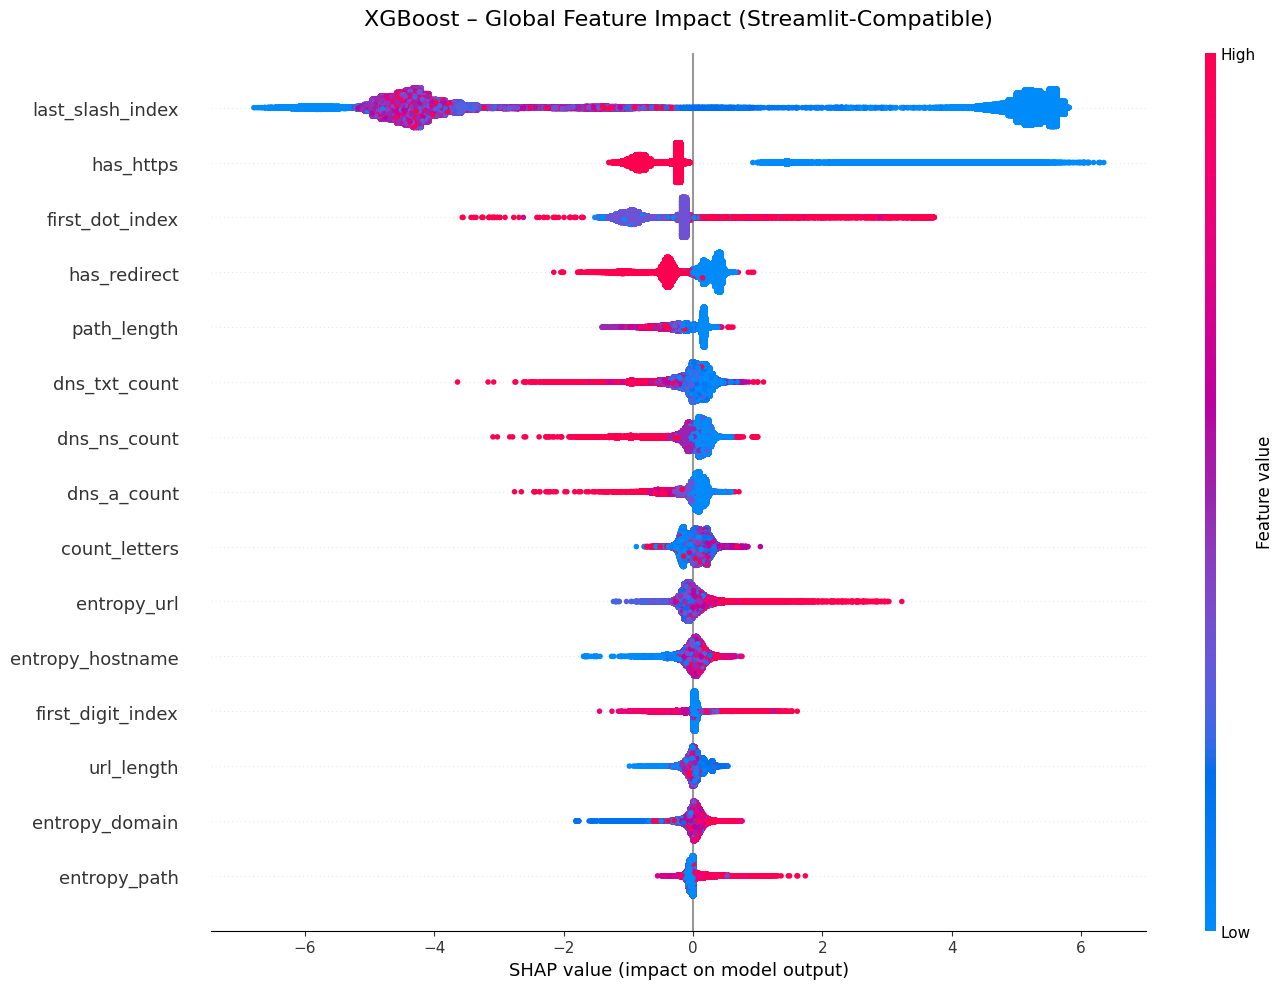


🔝 Top 10 Most Important Features:
----------------------------------------
 1. last_slash_index               | Impact: 4.5798
 2. has_https                      | Impact: 0.7285
 3. first_dot_index                | Impact: 0.6190
 4. has_redirect                   | Impact: 0.3527
 5. path_length                    | Impact: 0.2303
 6. dns_txt_count                  | Impact: 0.1971
 7. dns_ns_count                   | Impact: 0.1886
 8. dns_a_count                    | Impact: 0.1546
 9. count_letters                  | Impact: 0.1463
10. entropy_url                    | Impact: 0.1386
✅ XGBoost SHAP artefacts saved


In [7]:
# ========================================
# XGBoost Global SHAP - Notebook Version
# Matches Streamlit Analysis Exactly
# Updated for sep_05_25 bundle
# ========================================

import joblib, shap, matplotlib.pyplot as plt, pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- 1.  LOAD DATA -------------------------------------------------
bundle        = joblib.load("model_bundle_sep_05_25.pkl")
X_train       = joblib.load("X_train_sep_05_25.pkl")
xgb_model     = bundle["xgb_model"]
feature_names = bundle["feature_names"]

# ---------- 2.  PREPARE SAMPLE -------------------------------------------
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(len(X_train), len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3.  EXPLAINER & SHAP VALUES  (model_output="raw") ------------
print("🚀 XGBoost Analysis – Matching Streamlit Approach")
print("="*50)

xgb_explainer = shap.TreeExplainer(
    xgb_model,
    model_output="raw",
    feature_perturbation="interventional"
)
xgb_shap      = xgb_explainer(X_sample)          # new API (object)
xgb_shap_vals = xgb_shap.values                  # 3-D array

# reduce to 2-D for phishing class (index 1)
if len(xgb_shap_vals.shape) == 3 and xgb_shap_vals.shape[2] == 2:
    xgb_shap_plot = xgb_shap_vals[:, :, 1]
else:
    xgb_shap_plot = xgb_shap_vals

print(f"Final SHAP array shape: {xgb_shap_plot.shape}")

# ---------- 4.  BASE VALUE  (log-odds & prob) ----------------------------
def get_correct_base_value(explainer):
    base_val = explainer.expected_value
    if hasattr(base_val, '__len__') and len(base_val) == 2:
        return float(base_val[1])   # phishing class
    return float(base_val)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

xgb_base_logodds = get_correct_base_value(xgb_explainer)
xgb_base_prob    = sigmoid(xgb_base_logodds)

print("\n📈 Results:")
print(f"E[f(x)] (log-odds): {xgb_base_logodds:.4f}")
print(f"E[f(x)] (probability): {xgb_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 5.  GLOBAL SUMMARY PLOT  (Streamlit style) -------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    xgb_shap_plot,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("XGBoost – Global Feature Impact (Streamlit-Compatible)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 6.  TOP 10 FEATURES ------------------------------------------
mean_impact = np.mean(np.abs(xgb_shap_plot), axis=0)
top_xgb = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features:")
print("-" * 40)
for i, (feat, impact) in enumerate(top_xgb, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 7.  SAVE FOR ENSEMBLE ----------------------------------------
joblib.dump(xgb_shap_plot,     "xgb_shap_plot_sep_05_25.npy")
joblib.dump(xgb_base_logodds,  "xgb_base_logodds_sep_05_25.pkl")
print("✅ XGBoost SHAP artefacts saved")

# ---------- 8.  OPTIONAL SAVE PLOT ---------------------------------------
# plt.savefig("xgb_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'xgb_global_shap_sep_05_25.png'")

In [ ]:
# ========================================
# XGBoost Global SHAP - Notebook Version
# Matches Streamlit Analysis Exactly
# Updated for sep_05_25 bundle
# ========================================

import joblib, shap, matplotlib.pyplot as plt, pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- 1.  LOAD DATA -------------------------------------------------
bundle        = joblib.load("model_bundle_sep_05_25.pkl")
X_train       = joblib.load("X_train_sep_05_25.pkl")
xgb_model     = bundle["xgb_model"]
feature_names = bundle["feature_names"]

# ---------- 2.  PREPARE SAMPLE -------------------------------------------
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(150, len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3.  EXPLAINER & SHAP VALUES  (model_output="raw") ------------
print("🚀 XGBoost Analysis – Matching Streamlit Approach")
print("="*50)

xgb_explainer = shap.TreeExplainer(
    xgb_model,
    model_output="raw",
    feature_perturbation="interventional"
)
xgb_shap      = xgb_explainer(X_sample)          # new API (object)
xgb_shap_vals = xgb_shap.values                  # 3-D array

# reduce to 2-D for phishing class (index 1)
if len(xgb_shap_vals.shape) == 3 and xgb_shap_vals.shape[2] == 2:
    xgb_shap_plot = xgb_shap_vals[:, :, 1]
else:
    xgb_shap_plot = xgb_shap_vals

print(f"Final SHAP array shape: {xgb_shap_plot.shape}")

# ---------- 4.  BASE VALUE  (log-odds & prob) ----------------------------
def get_correct_base_value(explainer):
    base_val = explainer.expected_value
    if hasattr(base_val, '__len__') and len(base_val) == 2:
        return float(base_val[1])   # phishing class
    return float(base_val)

sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))

xgb_base_logodds = get_correct_base_value(xgb_explainer)
xgb_base_prob    = sigmoid(xgb_base_logodds)

print("\n📈 Results:")
print(f"E[f(x)] (log-odds): {xgb_base_logodds:.4f}")
print(f"E[f(x)] (probability): {xgb_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 5.  GLOBAL SUMMARY PLOT  (Streamlit style) -------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    xgb_shap_plot,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("XGBoost – Global Feature Impact (Streamlit-Compatible)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 6.  TOP 10 FEATURES ------------------------------------------
mean_impact = np.mean(np.abs(xgb_shap_plot), axis=0)
top_xgb = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features:")
print("-" * 40)
for i, (feat, impact) in enumerate(top_xgb, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 7.  SAVE FOR ENSEMBLE ----------------------------------------
joblib.dump(xgb_shap_plot,     "xgb_shap_plot_sep_05_25.npy")
joblib.dump(xgb_base_logodds,  "xgb_base_logodds_sep_05_25.pkl")
print("✅ XGBoost SHAP artefacts saved")

# ---------- 8.  OPTIONAL SAVE PLOT ---------------------------------------
# plt.savefig("xgb_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'xgb_global_shap_sep_05_25.png'")

🎯 SVM Analysis – Matching Streamlit Approach
📊 Setting up KernelExplainer...
🔍 Computing SHAP values (may take 30-60 seconds)...


100%|██████████| 150/150 [41:45:09<00:00, 1002.06s/it]   


Final SHAP array shape: (150, 84)

📈 Results:
E[f(x)] (probability): 0.4412
Dataset phishing rate: 0.4388


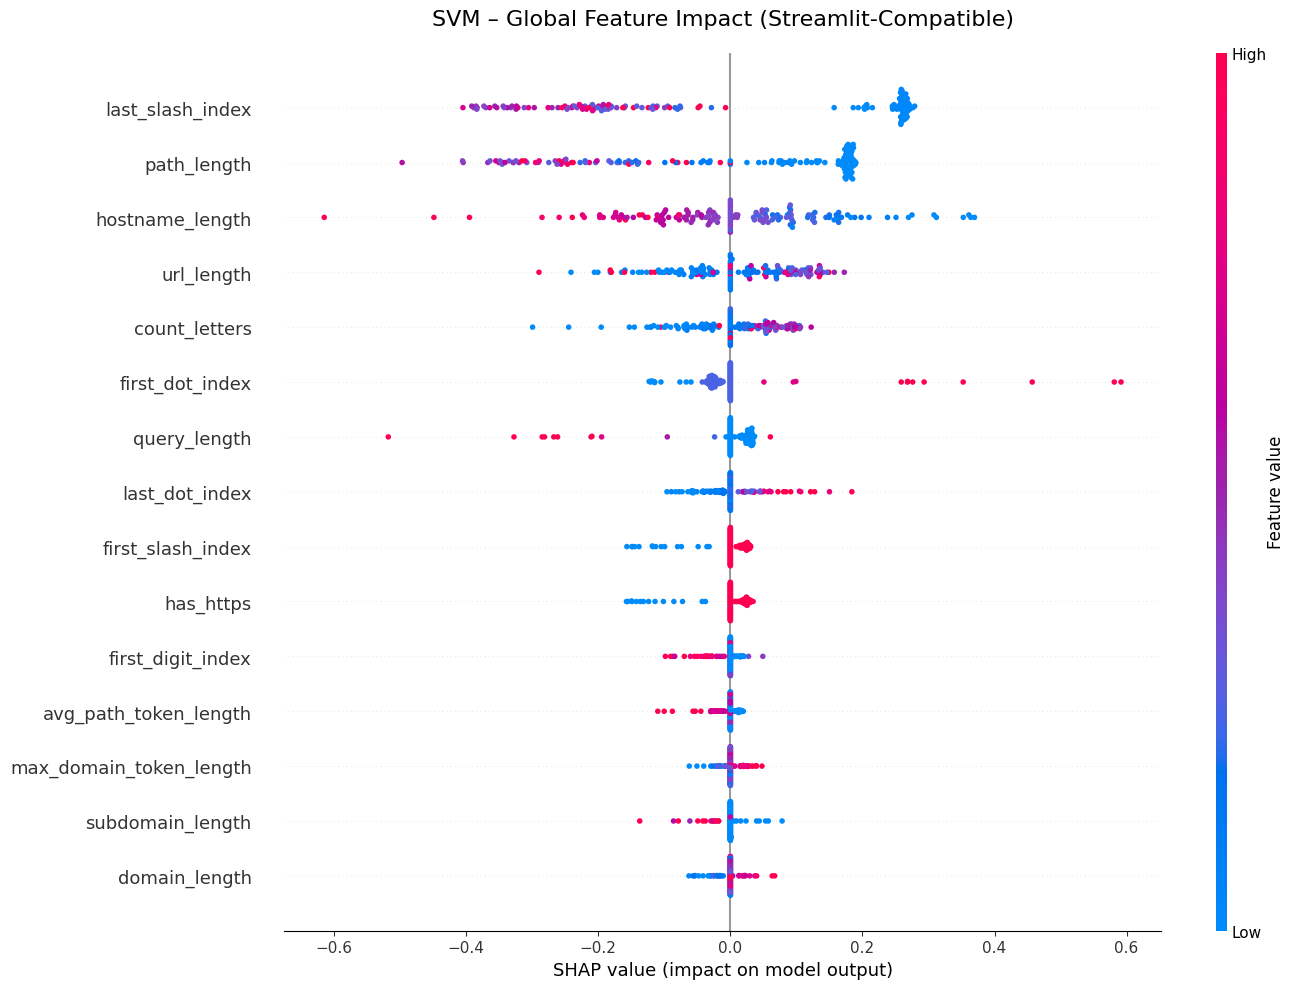


🔝 Top 10 Most Important Features:
----------------------------------------
 1. last_slash_index               | Impact: 0.2345
 2. path_length                    | Impact: 0.1816
 3. hostname_length                | Impact: 0.1122
 4. url_length                     | Impact: 0.0764
 5. count_letters                  | Impact: 0.0547
 6. first_dot_index                | Impact: 0.0409
 7. query_length                   | Impact: 0.0312
 8. last_dot_index                 | Impact: 0.0243
 9. first_slash_index              | Impact: 0.0209
10. has_https                      | Impact: 0.0207
✅ SVM SHAP artefacts saved


In [3]:
# ========================================
# SVM Global SHAP - Notebook Version
# Matches Streamlit Analysis Exactly
# Updated for sep_05_25 bundle  (COMPLETE)
# ========================================

import joblib, shap, matplotlib.pyplot as plt, pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- 1.  LOAD DATA -------------------------------------------------
bundle        = joblib.load("model_bundle_sep_05_25.pkl")
X_train       = joblib.load("X_train_sep_05_25.pkl")
svm_model     = bundle["svm_model"]
feature_names = bundle["feature_names"]

# ---------- 2.  PREPARE SAMPLE -------------------------------------------
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(150, len(X_train))          # restored to 150
X_sample    = X_train.sample(n=sample_size, random_state=42)

# ---------- 3.  SVM PREDICTION WRAPPER  (matches Streamlit) --------------
print("🎯 SVM Analysis – Matching Streamlit Approach")
print("="*50)

def svm_predict(x):
    """Return phishing-class probabilities exactly like Streamlit"""
    if not isinstance(x, pd.DataFrame):
        x = pd.DataFrame(x, columns=feature_names)
    return svm_model.predict_proba(x)[:, 1]

# ---------- 4.  KERNEL EXPLAINER -----------------------------------------
print("📊 Setting up KernelExplainer...")
svm_background = shap.sample(X_train, min(50, len(X_train)))   # 50 samples
svm_explainer  = shap.KernelExplainer(svm_predict, svm_background)

# ---------- 5.  SHAP VALUES ----------------------------------------------
print("🔍 Computing SHAP values (may take 30-60 seconds)...")
svm_shap_values = svm_explainer.shap_values(X_sample)
print(f"Final SHAP array shape: {svm_shap_values.shape}")

# ---------- 6.  BASE VALUE (probability) ---------------------------------
def get_correct_base_value_svm(explainer):
    base_val = explainer.expected_value
    if isinstance(base_val, np.ndarray):
        return float(np.mean(base_val))
    return float(base_val)

svm_base_prob = get_correct_base_value_svm(svm_explainer)

print("\n📈 Results:")
print(f"E[f(x)] (probability): {svm_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 7.  GLOBAL SUMMARY PLOT  (Streamlit style) -------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    svm_shap_values,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("SVM – Global Feature Impact (Streamlit-Compatible)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 8.  TOP 10 FEATURES ------------------------------------------
mean_impact = np.mean(np.abs(svm_shap_values), axis=0)
top_svm = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features:")
print("-" * 40)
for i, (feat, impact) in enumerate(top_svm, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 9.  SAVE FOR ENSEMBLE ----------------------------------------
joblib.dump(svm_shap_values, "svm_shap_values_sep_05_25.npy")
joblib.dump(svm_base_prob,   "svm_base_prob_sep_05_25.pkl")
print("✅ SVM SHAP artefacts saved")

# ---------- 10.  OPTIONAL SAVE PLOT --------------------------------------
# plt.savefig("svm_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'svm_global_shap_sep_05_25.png'")

✅ Final Ensemble SHAP shape: (150, 84)

📈 Ensemble Results:
E[f(x)] (log-odds):    -0.0429
E[f(x)] (probability): 0.4893
Dataset phishing rate: 0.4388


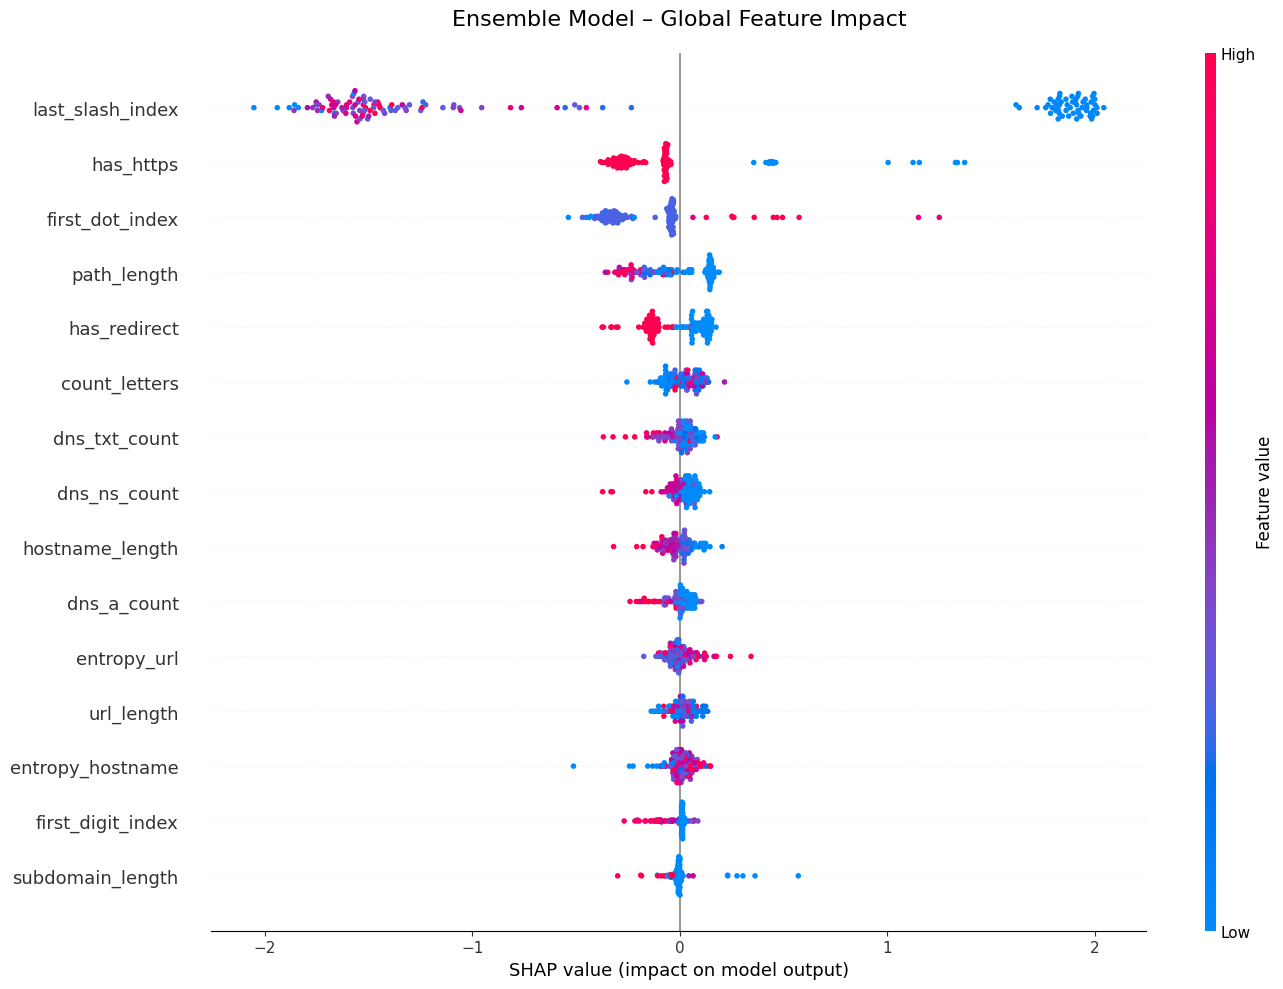


🔝 Top 10 Most Important Features (Ensemble):
----------------------------------------
 1. last_slash_index               | Impact: 1.6072
 2. has_https                      | Impact: 0.2470
 3. first_dot_index                | Impact: 0.2335
 4. path_length                    | Impact: 0.1518
 5. has_redirect                   | Impact: 0.1221
 6. count_letters                  | Impact: 0.0628
 7. dns_txt_count                  | Impact: 0.0583
 8. dns_ns_count                   | Impact: 0.0518
 9. hostname_length                | Impact: 0.0499
10. dns_a_count                    | Impact: 0.0461


In [6]:
# ========================================
# Ensemble Global SHAP - Notebook Version
# Uses pre-computed individual SHAP values
# Updated for sep_05_25 bundle
# ========================================

import joblib, numpy as np, matplotlib.pyplot as plt, pandas as pd
import shap  # only for plotting utilities

# ---------- 1.  LOAD SAMPLE DATA  (same sample used by RF/XGB/SVM) -------
X_train       = joblib.load("X_train_sep_05_25.pkl")
feature_names = joblib.load("model_bundle_sep_05_25.pkl")["feature_names"]

if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(150, len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)   # same random_state

# ---------- 2.  LOAD PRE-COMPUTED SHAP VALUES  ----------------------------
rf_shap_plot = joblib.load("rf_shap_plot_sep_05_25.npy")      # 2-D array shape (150, n_features)
xgb_shap_plot= joblib.load("xgb_shap_plot_sep_05_25.npy")
svm_shap_vals= joblib.load("svm_shap_values_sep_05_25.npy")   # already 2-D

# ---------- 3.  BUILD ENSEMBLE SHAP  --------------------------------------
ensemble_shap_values = (rf_shap_plot + xgb_shap_plot + svm_shap_vals) / 3
print(f"✅ Final Ensemble SHAP shape: {ensemble_shap_values.shape}")

# ---------- 4.  LOAD PRE-COMPUTED BASE VALUES  ----------------------------
rf_base_logodds  = float(joblib.load("rf_base_logodds_sep_05_25.pkl"))
xgb_base_logodds = float(joblib.load("xgb_base_logodds_sep_05_25.pkl"))
svm_base_prob    = float(joblib.load("svm_base_prob_sep_05_25.pkl"))

# convert SVM base probability → log-odds
svm_base_logodds   = np.log(svm_base_prob / (1 - svm_base_prob + 1e-16))

# average log-odds → probability
ensemble_base_logodds = (rf_base_logodds + xgb_base_logodds + svm_base_logodds) / 3
sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))
ensemble_base_prob    = sigmoid(ensemble_base_logodds)

# ---------- 5.  DISPLAY RESULTS  ------------------------------------------
print("\n📈 Ensemble Results:")
print(f"E[f(x)] (log-odds):    {ensemble_base_logodds:.4f}")
print(f"E[f(x)] (probability): {ensemble_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 6.  GLOBAL SUMMARY PLOT  --------------------------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    ensemble_shap_values,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("Ensemble Model – Global Feature Impact", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 7.  TOP 10 FEATURES  ------------------------------------------
mean_impact = np.mean(np.abs(ensemble_shap_values), axis=0)
top_ensemble = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features (Ensemble):")
print("-" * 40)
for i, (feat, impact) in enumerate(top_ensemble, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 8.  OPTIONAL SAVE  --------------------------------------------
# plt.savefig("ensemble_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'ensemble_global_shap_sep_05_25.png'")

In [ ]:
# ========================================
# Ensemble Global SHAP - Notebook Version
# Uses pre-computed individual SHAP values
# Updated for sep_05_25 bundle  (COMPLETE)
# ========================================

import joblib, numpy as np, matplotlib.pyplot as plt, pandas as pd
import shap  # plotting utilities only

# ---------- 1.  LOAD SAMPLE DATA  (same 150-row sample used by RF/XGB/SVM) -------
X_train       = joblib.load("X_train_sep_05_25.pkl")
feature_names = joblib.load("model_bundle_sep_05_25.pkl")["feature_names"]

if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

sample_size = min(150, len(X_train))
X_sample    = X_train.sample(n=sample_size, random_state=42)   # identical sample

# ---------- 2.  LOAD PRE-COMPUTED SHAP VALUES  ----------------------------
rf_shap_plot  = joblib.load("rf_shap_plot_sep_05_25.npy")      # shape (150, n_features)
xgb_shap_plot = joblib.load("xgb_shap_plot_sep_05_25.npy")
svm_shap_vals = joblib.load("svm_shap_values_sep_05_25.npy")   # already 2-D

# ---------- 3.  BUILD ENSEMBLE SHAP  --------------------------------------
ensemble_shap_values = (rf_shap_plot + xgb_shap_plot + svm_shap_vals) / 3
print(f"✅ Final Ensemble SHAP shape: {ensemble_shap_values.shape}")

# ---------- 4.  LOAD PRE-COMPUTED BASE VALUES  ----------------------------
rf_base_logodds  = float(joblib.load("rf_base_logodds_sep_05_25.pkl"))
xgb_base_logodds = float(joblib.load("xgb_base_logodds_sep_05_25.pkl"))
svm_base_prob    = float(joblib.load("svm_base_prob_sep_05_25.pkl"))

# convert SVM base probability → log-odds for averaging
svm_base_logodds = np.log(svm_base_prob / (1 - svm_base_prob + 1e-16))

# average log-odds → probability
ensemble_base_logodds = (rf_base_logodds + xgb_base_logodds + svm_base_logodds) / 3
sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))
ensemble_base_prob    = sigmoid(ensemble_base_logodds)

# ---------- 5.  DISPLAY RESULTS  ------------------------------------------
print("\n📈 Ensemble Results:")
print(f"E[f(x)] (log-odds):    {ensemble_base_logodds:.4f}")
print(f"E[f(x)] (probability): {ensemble_base_prob:.4f}")
print(f"Dataset phishing rate: {np.mean(joblib.load('y_train_sep_05_25.pkl')):.4f}")

# ---------- 6.  GLOBAL SUMMARY PLOT  (Streamlit style) --------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    ensemble_shap_values,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15,
    plot_size=(14, 10)
)
plt.title("Ensemble Model – Global Feature Impact", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# ---------- 7.  TOP 10 FEATURES  ------------------------------------------
mean_impact = np.mean(np.abs(ensemble_shap_values), axis=0)
top_ensemble = sorted(zip(feature_names, mean_impact), key=lambda x: x[1], reverse=True)[:10]

print("\n🔝 Top 10 Most Important Features (Ensemble):")
print("-" * 40)
for i, (feat, impact) in enumerate(top_ensemble, 1):
    print(f"{i:2d}. {feat:<30} | Impact: {impact:.4f}")

# ---------- 8.  OPTIONAL SAVE  --------------------------------------------
# plt.savefig("ensemble_global_shap_sep_05_25.png", dpi=300, bbox_inches='tight')
# print("✅ Plot saved as 'ensemble_global_shap_sep_05_25.png'")

In [49]:
np.shape(shap_xgboost_values.values)


(2573, 84)

In [50]:
np.shape(shap_rf_values.values)
# the 2 here implies multiclass

(2573, 84, 2)

In [51]:
print("X_sample shape:", X_sample.shape)                    # (e.g., (45, 92))
print("shap_svm_values[1] shape:", np.shape(shap_svm_values[1]))  # Should be (45, 92)



X_sample shape: (100, 84)
shap_svm_values[1] shape: (84, 2)


In [100]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# 0. Create sample data (replace with your actual data)
# X, y = make_classification(n_samples=100, n_features=10, n_classes=2, random_state=42)
# X_sample = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(10)])
X = df_ml.drop(columns=cols_to_drop, axis=1)
y = df_ml['label']

# 5. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
background = shap.utils.sample(X_sample, 10)  # Background for KernelExplainer

# 1. Train SVM
svm_model = SVC(probability=True, kernel='rbf', random_state=42)
svm_model.fit(X, y)

# Debug: Check model classes
print("\n=== Model Information ===")
print(f"Model classes: {svm_model.classes_}")
print(f"Number of classes: {len(svm_model.classes_)}")

# 2. Initialize KernelExplainer
explainerSVM = shap.KernelExplainer(svm_model.predict_proba, background)

# 3. Compute SHAP values for a single instance
shap_svm_values = explainerSVM.shap_values(X_sample.iloc[0:1], nsamples=100)

# Debug: Check SHAP values structure
print("\n=== SHAP Values Structure ===")
print(f"Type of shap_svm_values: {type(shap_svm_values)}")
if isinstance(shap_svm_values, list):
    print(f"List length: {len(shap_svm_values)}")
    for i, arr in enumerate(shap_svm_values):
        print(f"Class {i} values shape: {arr.shape}")
else:
    print(f"Array shape: {shap_svm_values.shape}")

# 4. Handle binary/multiclass cases
if isinstance(shap_svm_values, list):
    # Multiclass case
    print("\nProcessing as multiclass")
    class_idx = 1  # Change to desired class (0 or 1 for binary)
    shap_values_single = shap_svm_values[class_idx][0]  # First sample
    base_value = explainerSVM.expected_value[class_idx]
else:
    # Binary case
    print("\nProcessing as binary classification")
    if len(shap_svm_values.shape) == 3:
        # Handle 3D array case (samples, features, classes)
        print("3D array detected - selecting first sample and class 1")
        shap_values_single = shap_svm_values[0, :, 1]  # First sample, class 1
        base_value = explainerSVM.expected_value[1]
    else:
        # Standard 2D array
        print("2D array detected - selecting first sample")
        shap_values_single = shap_svm_values[0]  # First sample
        base_value = explainerSVM.expected_value[0]

# Debug: Check final values
print("\n=== Final Values ===")
print(f"SHAP values shape: {shap_values_single.shape}")
print(f"Base value: {base_value}")
print(f"Feature values: {X_sample.iloc[0].values}")

# 5. Create Explanation object
try:
    explanation = shap.Explanation(
        values=shap_values_single,
        base_values=base_value,
        data=X_sample.iloc[0].values,
        feature_names=X_sample.columns.tolist()
    )
    
    # Debug: Check explanation object
    print("\n=== Explanation Object ===")
    print(f"Explanation shape: {explanation.values.shape}")
    
    # 6. Plot waterfall
    print("\nGenerating waterfall plot...")
    shap.plots.waterfall(explanation, max_display=10)
    plt.show()
    
except Exception as e:
    print(f"\n!!! Error creating explanation: {e}")
    print("\nDebugging suggestions:")
    print("1. Try reshaping shap_values_single if dimensions are wrong")
    print("2. Check that base_value matches your expected output")
    print("3. Verify feature_names match the number of features")
    print("4. Try plotting with just: shap.plots.waterfall(shap_values_single)")


=== Model Information ===
Model classes: [0 1]
Number of classes: 2
Provided model function fails when applied to the provided data set.


ValueError: X has 10 features, but SVC is expecting 84 features as input.

  0%|          | 0/1 [00:00<?, ?it/s]

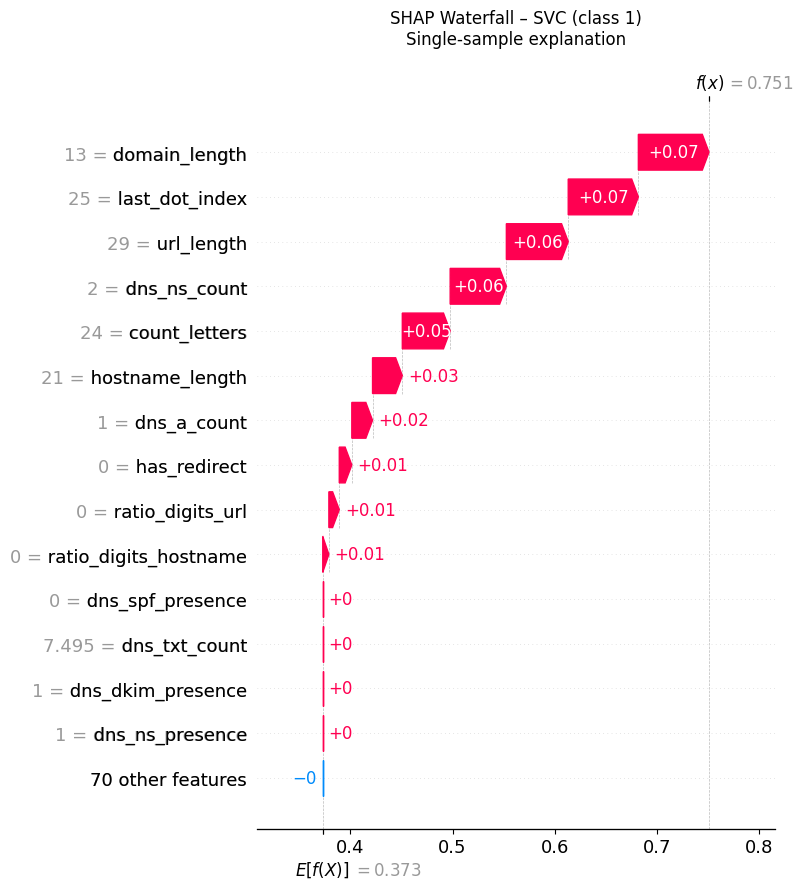

In [98]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

def svm_shap_waterfall(svm_model,
                       X_test,
                       feature_names=None,
                       class_idx=1,
                       nsamples=100):
    """
    Generate a SHAP waterfall plot for an SVM classifier and display the feature names.

    Parameters
    ----------
    svm_model : sklearn estimator
        A fitted SVM classifier (or any sklearn model with predict_proba).
    X_test : array-like or pd.DataFrame
        Test / sample data.
    feature_names : list[str] | None
        If X_test is not a DataFrame, provide the list of feature names.
    class_idx : int
        Index of the class whose probability is explained.
    nsamples : int
        Number of samples to use in the KernelExplainer.

    Returns
    -------
    shap.Explanation | None
        The Explanation object used for plotting, or None if something fails.
    """

    try:
        # ------------------------------------------------------------------
        # 1. Ensure we have a DataFrame with proper column names
        # ------------------------------------------------------------------
        if not isinstance(X_test, pd.DataFrame):
            if feature_names is None:
                feature_names = [f"feature_{i}" for i in range(X_test.shape[1])]
            X_test = pd.DataFrame(X_test, columns=feature_names)

        # ------------------------------------------------------------------
        # 2. Align to the exact features the model was trained on
        # ------------------------------------------------------------------
        if hasattr(svm_model, "feature_names_in_"):
            expected_features = list(svm_model.feature_names_in_)
        else:
            expected_features = X_test.columns[: svm_model.n_features_in_].tolist()

        # Sanity-check: do we have all required features?
        missing = set(expected_features) - set(X_test.columns)
        if missing:
            print("\n[ERROR] Missing features required by the model:")
            print(list(missing))
            return None

        X_sample = X_test[expected_features].iloc[[0]]  # keep as DataFrame

        # ------------------------------------------------------------------
        # 3. Build background and explainer
        # ------------------------------------------------------------------
        background = shap.utils.sample(
            X_test[expected_features],
            min(100, len(X_test))
        )

        explainer = shap.KernelExplainer(
            svm_model.predict_proba,
            background,
            silent=True
        )

        # ------------------------------------------------------------------
        # 4. Compute SHAP values
        # ------------------------------------------------------------------
        shap_values = explainer.shap_values(X_sample, nsamples=nsamples)

        # Handle possible output shapes
        if isinstance(shap_values, list):
            values = shap_values[class_idx][0]
            base_value = explainer.expected_value[class_idx]
        elif shap_values.ndim == 3:
            values = shap_values[0, :, class_idx]
            base_value = explainer.expected_value[class_idx]
        else:
            values = shap_values[0]
            base_value = explainer.expected_value[0]

        # ------------------------------------------------------------------
        # 5. Build Explanation object
        # ------------------------------------------------------------------
        explanation = shap.Explanation(
            values=values,
            base_values=base_value,
            data=X_sample.iloc[0],               # <- pandas Series keeps index
            feature_names=X_sample.columns.tolist()
        )

        # ------------------------------------------------------------------
        # 6. Plot
        # ------------------------------------------------------------------
                # ------------------------------------------------------------------
        # 6. Plot  (force labels via shap.waterfall_plot)
        # ------------------------------------------------------------------
        plt.figure(figsize=(12, 6))

        shap.waterfall_plot(
            shap.Explanation(
                values=values,
                base_values=base_value,
                data=X_sample.iloc[0],
                feature_names=list(X_sample.columns)
            ),
            max_display=15,
            show=False
        )

        plt.title(
            f"SHAP Waterfall – {svm_model.__class__.__name__} "
            f"(class {class_idx})\nSingle-sample explanation",
            pad=20
        )
        plt.tight_layout()
        plt.show()
        
        return explanation

    except Exception as e:
        print("\n[ERROR] Generating SHAP plot failed:")
        print(e)
        return None


# --------------------------------------------------------------------------
# Example usage
# --------------------------------------------------------------------------
if __name__ == "__main__":
    # Dummy data for quick self-test
    from sklearn.svm import SVC
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split

    # X, y = make_classification(n_samples=300,
    #                            n_features=6,
    #                            n_informative=4,
    #                            n_classes=2,
    #                            random_state=42)

    # X_train, X_test, y_train, y_test = train_test_split(X,
    #                                                     y,
    #                                                     test_size=0.3,
    #                                                     random_state=42)

    X = df_ml.drop(columns=cols_to_drop, axis=1)
    y = df_ml['label']

    # 5. Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = SVC(kernel="rbf", probability=True, random_state=42)
    model.fit(X_train, y_train)

    
    # Call the helper
    svm_shap_waterfall(model,
                       X_test,
                       feature_names=[f"f{i}" for i in range(X_test.shape[1])],
                       class_idx=1,
                       nsamples=100)

  0%|          | 0/1 [00:00<?, ?it/s]

IndexError: index 1 is out of bounds for axis 0 with size 1

  0%|          | 0/1 [00:00<?, ?it/s]

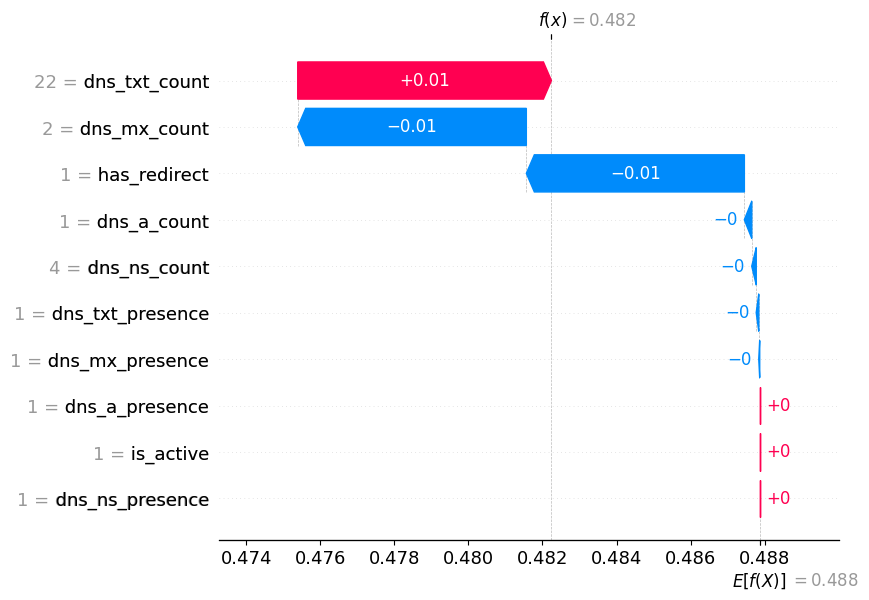

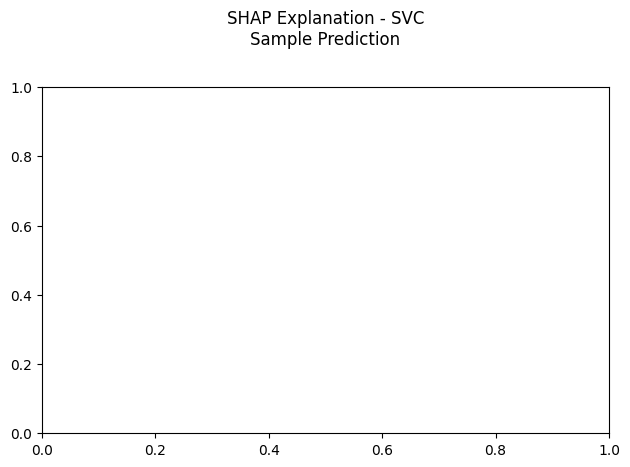

In [78]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone

def svm_shap_waterfall(svm_model, X_test, feature_names=None, class_idx=1, nsamples=100):
    """
    Generate SHAP waterfall plot for SVM that automatically handles feature dimension mismatches
    
    Parameters:
    - svm_model: Trained SVM model
    - X_test: Test data (DataFrame or array)
    - feature_names: List of feature names (optional)
    - class_idx: Which class to explain (default: 1)
    - nsamples: Number of SHAP samples to compute
    
    Returns:
    - SHAP Explanation object or None if failed
    """
    try:
        # Convert to DataFrame and handle feature names
        if not isinstance(X_test, pd.DataFrame):
            if feature_names is None:
                feature_names = [f'feature_{i}' for i in range(X_test.shape[1])]
            X_test = pd.DataFrame(X_test, columns=feature_names)
        
        # Get the features the model was actually trained on
        if hasattr(svm_model, 'feature_names_in_'):
            expected_features = svm_model.feature_names_in_
        else:
            expected_features = X_test.columns[:svm_model.n_features_in_]
        
        # Select only the features the model knows about
        try:
            X_sample = X_test[expected_features].iloc[0:1]
        except KeyError:
            print("\nError: Model was trained on different features than provided")
            print(f"Model expects: {expected_features.tolist()[:5]}...")
            print(f"Data contains: {X_test.columns.tolist()[:5]}...")
            print("\nPossible solutions:")
            print("1. Use the same feature selection as during training")
            print("2. Re-train model with current feature set")
            print("3. Use ColumnTransformer to ensure consistent features")
            return None
        
        # Create background data with matching features
        background = shap.utils.sample(X_test[expected_features], min(10, len(X_test)))
        
        # Initialize explainer
        explainer = shap.KernelExplainer(svm_model.predict_proba, background)
        
        # Compute SHAP values
        shap_values = explainer.shap_values(X_sample, nsamples=nsamples)
        
        # Handle different SHAP output formats
        if isinstance(shap_values, list):
            values = shap_values[class_idx][0]
            base_value = explainer.expected_value[class_idx]
        elif len(shap_values.shape) == 3:
            values = shap_values[0,:,class_idx]
            base_value = explainer.expected_value[class_idx]
        else:
            values = shap_values[0]
            base_value = explainer.expected_value[0]
        
        # Create explanation
        explanation = shap.Explanation(
            values=values,
            base_values=base_value,
            data=X_sample.values[0],
            feature_names=X_sample.columns.tolist()
        )
        
        # Plot
        plt.figure(figsize=(12, 6))
        shap.plots.waterfall(explanation, max_display=15)
        plt.title(f"SHAP Explanation - {svm_model.__class__.__name__}\nSample Prediction", y=1.1)
        plt.tight_layout()
        plt.show()
        
        return explanation
    
    except Exception as e:
        print(f"\nError generating SHAP plot: {str(e)}")
        print("\nDebugging information:")
        print(f"Model expects {svm_model.n_features_in_} features")
        print(f"Provided data has {X_test.shape[1]} features")
        
        if hasattr(svm_model, 'feature_names_in_'):
            print("\nModel was trained on features:")
            print(svm_model.feature_names_in_)
        
        print("\nFirst 5 features in test data:")
        print(X_test.columns.tolist()[:5])
        
        print("\nPossible fixes:")
        print("1. Ensure consistent feature selection between train/test")
        print("2. Use sklearn.compose.ColumnTransformer for feature processing")
        print("3. Check for missing feature selection steps in pipeline")
        print("4. Re-train model with current feature set if appropriate")
        
        return None

# Usage example:
shap_values = svm_shap_waterfall(
    svm_model,
    X_test,  #  test data (84 features)
    feature_names=None  # Optional: provide if X_test is array
)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1, 92, 2)


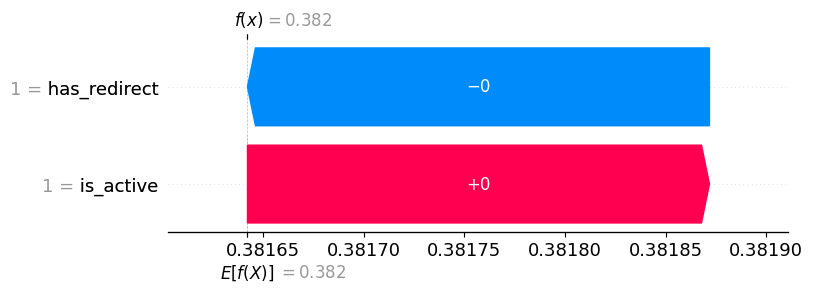

In [41]:
import numpy as np

# 1. Compute SHAP values for ONE observation
shap_svm_values = explainerSVM.shap_values(X_sample.iloc[0:1])

# 2. Debug output
print(f"SHAP values type: {type(shap_svm_values)}")
if isinstance(shap_svm_values, np.ndarray):
    print(f"SHAP values shape: {shap_svm_values.shape}")
elif isinstance(shap_svm_values, list):
    print(f"Number of classes: {len(shap_svm_values)}")
    print(f"First class shape: {np.array(shap_svm_values[0]).shape}")

# 3. Universal SHAP values extraction
if isinstance(shap_svm_values, list):
    # Multiclass case - select class 1 values for first observation
    shap_values_plot = np.array(shap_svm_values[1])[0]
elif isinstance(shap_svm_values, np.ndarray):
    if len(shap_svm_values.shape) == 3:
        # Multiclass array format (n_samples, n_classes, n_features)
        shap_values_plot = shap_svm_values[0, 1, :]  # First obs, class 1
    elif len(shap_svm_values.shape) == 2:
        # Binary case (n_samples, n_features)
        shap_values_plot = shap_svm_values[0, :]
    else:
        raise ValueError(f"Unexpected array shape: {shap_svm_values.shape}")
else:
    raise ValueError(f"Unsupported SHAP output type: {type(shap_svm_values)}")

# 4. Compute base value
base_value = svm_model.predict_proba(background)[:, 1].mean()

# 5. Create waterfall plot
shap.initjs()
shap.plots.waterfall(shap.Explanation(
    values=shap_values_plot,
    base_values=base_value,
    data=X_sample.iloc[0],
    feature_names=X.columns.tolist()
))

In [42]:
import numpy as np
import shap

# 1. Use larger background and more samples
background = X_train.sample(200, random_state=42)  # Increased from 100
explainerSVM = shap.KernelExplainer(
    svm_model.predict_proba, 
    background,
    nsamples=1000  # Increased from 100
)

# 2. Compute SHAP values with proper settings
shap_svm_values = explainerSVM.shap_values(
    X_sample.iloc[0:1], 
    nsamples=500,  # More samples per prediction
    l1_reg="num_features(20)"  # Force more features
)

# 3. Extract SHAP values for class 1 (assuming binary classification)
shap_values_plot = shap_svm_values[1][0]  # [class][observation][features]

# 4. Create waterfall plot with all features
shap.initjs()
shap.plots.waterfall(shap.Explanation(
    values=shap_values_plot,
    base_values=explainerSVM.expected_value[1],
    data=X_sample.iloc[0],
    feature_names=X.columns.tolist(),
    feature_display_range=slice(None, None, -1)  # Show all features
))

ValueError: Cannot take a larger sample than population when 'replace=False'

In [20]:
# 1. Pick the single row you want to explain
row_id = 0          # 0 = first row in your sample
cls    = 1          # class-1 (positive) probabilities

# 2. Isolate the SHAP pieces for that single explanation
values_1d   = shap_svm_values[cls][row_id]          # shape (n_features,)
base_1d     = explainerSVM.expected_value[cls]      # scalar
row_data    = X_sample.iloc[row_id]                 # Series (n_features,)

# 3. Wrap in a properly-shaped Explanation object
exp = shap.Explanation(
        values       = values_1d,
        base_values  = base_1d,
        data         = row_data,
        feature_names= X.columns.to_list()
      )

# 4. Plot – force every feature to show
shap.plots.waterfall(exp, max_display=len(X.columns))

In [15]:
# first observation index
idx = 0
print(shap_ensemble_raw[1][idx].shape)   # should be (n_features,)
print(np.count_nonzero(shap_ensemble_raw[1][idx]))

# --- build explanation for class 1 ---
base_val = float(explainerEnsemble.expected_value[1])   # <- scalar
exp = shap.Explanation(
        values       = shap_ensemble_raw[1][idx],
        base_values  = base_val,
        data         = X_sample_ensemble.iloc[idx],
        feature_names= X_sample_ensemble.columns.tolist()
)

# --- plot and force display ---
shap.plots.waterfall(exp, show=True)   # show=True forces inline output
plt.show()                             # redundant but safe

(2,)
0


In [16]:
# 1.  Prepare background and sample as NumPy arrays
background_ensemble = shap.kmeans(X_train.values, 50)  # kmeans on np.ndarray
n_sample = min(200, len(X_test))
sample_idx = X_test.sample(n_sample, random_state=42).index
X_sample_np = X_test.loc[sample_idx].values            # np.ndarray shape (n_sample, n_features)

# 2.  Build KernelExplainer on the NumPy data
explainerEnsemble = shap.KernelExplainer(
    ensemble_predict_proba,
    background_ensemble,
    link="identity"
)

# 3.  Compute SHAP values
shap_ensemble_raw = explainerEnsemble.shap_values(X_sample_np, nsamples=100)

# 4.  Check shapes again
print("X_sample_np shape:", X_sample_np.shape)                 # (n_sample, n_features)
print("shap_ensemble_raw[1] shape:", shap_ensemble_raw[1].shape)  # (n_sample, n_features)

# 5.  Build Explanation for the first row
exp = shap.Explanation(
    values       = shap_ensemble_raw[1][0],
    base_values  = float(explainerEnsemble.expected_value[1]),
    data         = X_sample_np[0],
    feature_names= X.columns.tolist()
)

# 6.  Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 12))
shap.plots.waterfall(exp, max_display=20)
plt.tight_layout(); plt.show()

  0%|          | 0/45 [00:00<?, ?it/s]

X_sample_np shape: (45, 92)
shap_ensemble_raw[1] shape: (92, 2)


<Figure size 640x480 with 0 Axes>

In [18]:
shap.plots.waterfall(shap.Explanation(shap_svm_values[0], explainerSVM.expected_value, X_sample.iloc[0], X.columns.tolist()))


ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (92, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [34]:
shap.plots.force(shap_xgboost_values[0])

In [19]:
shap.plots.force(shap.Explanation(values=shap_rf_values.values[0,:,1], base_values=shap_rf_values.base_values[0,1], data=shap_rf_values.data[0], feature_names=shap_rf_values.feature_names))


In [20]:
# svm
shap.plots.force(shap.Explanation(values=shap_svm_values[0], base_values=explainerSVM.expected_value, data=X_sample.iloc[0], feature_names=X.columns.tolist()))


TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

In [ ]:
#note
#force and waterfall are usefull in understanding how a model makes individual predictions

In [36]:
# combining multiple forced plot together to create a stacked force plot
shap.plots.force(shap_xgboost_values[0:100])

In [46]:
shap.plots.force(shap.Explanation(values=shap_rf_values.values[0:100,:,1], base_values=shap_rf_values.base_values[0:100,1], data=shap_rf_values.data[0:100], feature_names=shap_rf_values.feature_names))
#random forest

In [26]:
# this is binary class so we only visualize the contributions to first class (hence index 0)
shap.force_plot(explainerSVM.expected_value[0], shap_svm_values[..., 0], X_test)

In [88]:


shap.plots.force(explanation)



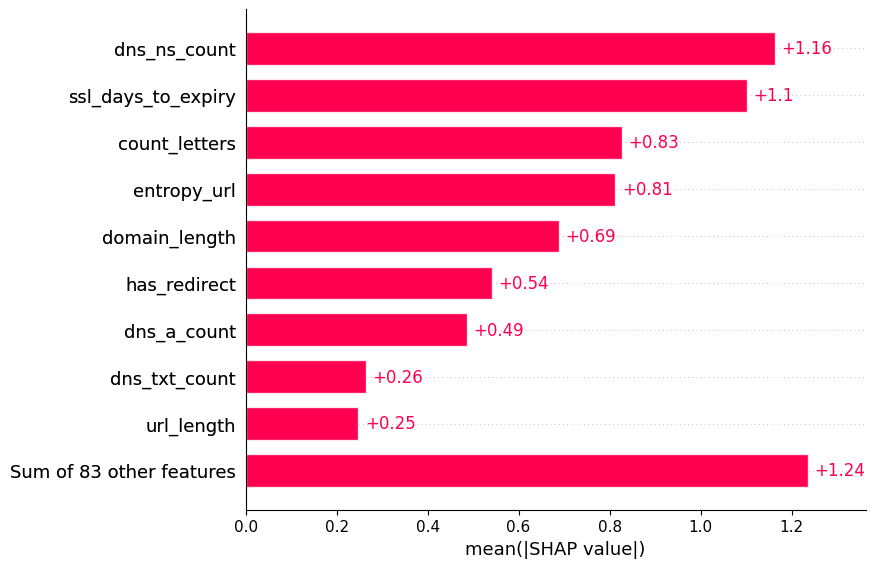

In [ ]:
# to find out which features are most important to the model. This gives us the absolute mean shap plot 
shap.plots.bar(shap_xgboost_values)

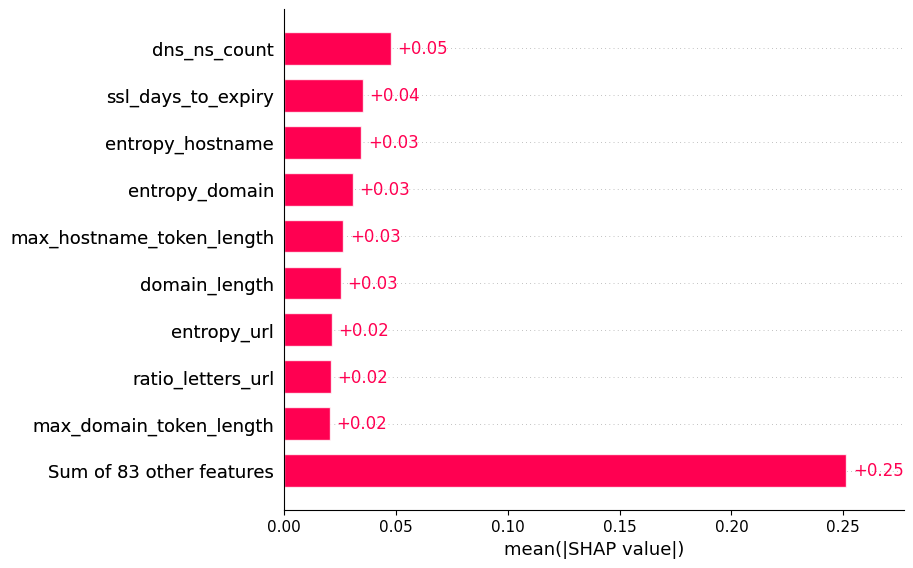

In [ ]:
# generate the mean absolute SHAP value bar plot for Random Forest, using class 1 SHAP values:
shap.plots.bar(shap.Explanation(values=shap_rf_values.values[:,:,1], base_values=shap_rf_values.base_values[:,1], data=shap_rf_values.data, feature_names=shap_rf_values.feature_names))


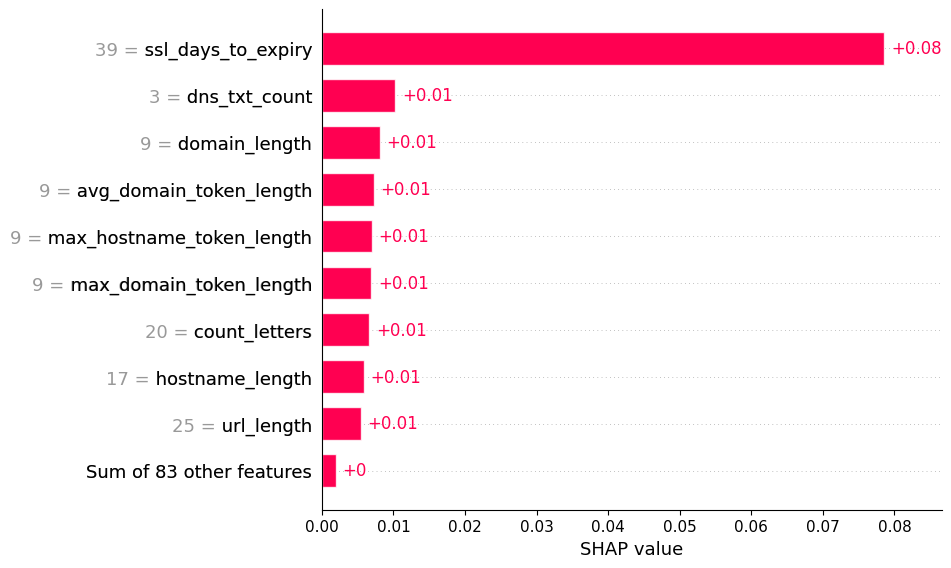

In [89]:
shap.plots.bar(explanation)


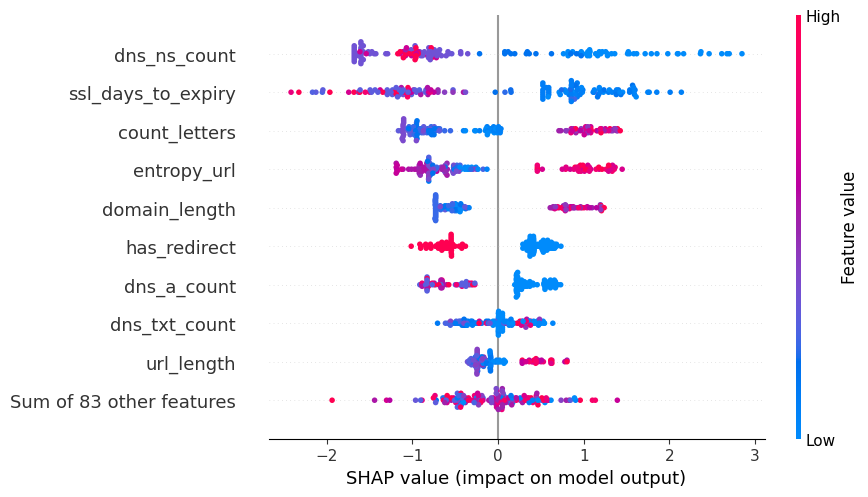

In [ ]:
# most useful shap plot which is beeswarm shap plot
shap.plots.beeswarm(shap_xgboost_values)
# high values are red and x axis are shap values

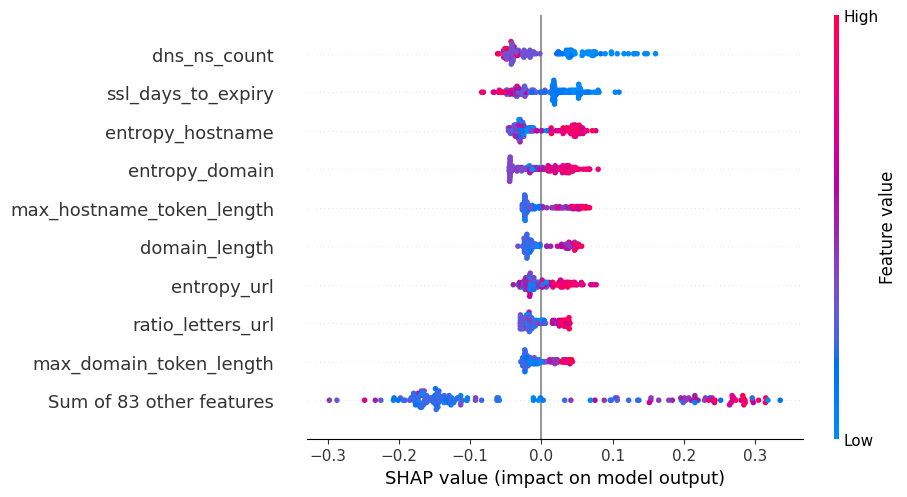

In [48]:
# most useful shap plot which is beeswarm shap plot
shap.plots.beeswarm(shap.Explanation(values=shap_rf_values.values[:,:,1], base_values=shap_rf_values.base_values[:,1], data=shap_rf_values.data, feature_names=shap_rf_values.feature_names))

# high values are red and x axis are shap values

In [93]:
# 2. Use a small, representative sample from test data (ensure this has multiple rows)
X_sample = X_test.sample(min(500, len(X_test)), random_state=42) # Increased sample size for beeswarm

# 3. Initialize KernelExplainer
explainerSVM = shap.KernelExplainer(svm_model.predict_proba, background)

# 4. Compute SHAP values
shap_svm_values = explainerSVM.shap_values(X_sample, nsamples=100)  # slow, so limit nsamples

# 5. Wrap SHAP values for class 1 into Explanation object (✅ fix applied here)
explanation = shap.Explanation(
    values=shap_svm_values[1], # This should be an array of SHAP values for all instances in X_sample for class 1
    base_values=explainerSVM.expected_value[1], # Use the base value for class 1
    data=X_sample, # This should be the DataFrame/array of instances
    feature_names=X.columns.tolist()
)

# Generate the beeswarm plot
shap.plots.beeswarm(explanation)


  0%|          | 0/45 [00:00<?, ?it/s]

DimensionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

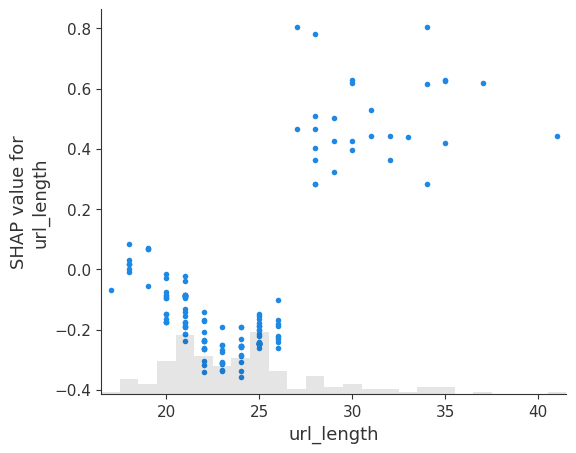

In [40]:
#dependent plot is a scattered plot of shap values vs featured values for a single feature. 
#useful if feature value as a non linear relationship with the 
shap.plots.scatter(shap_xgboost_values[:,"url_length"])

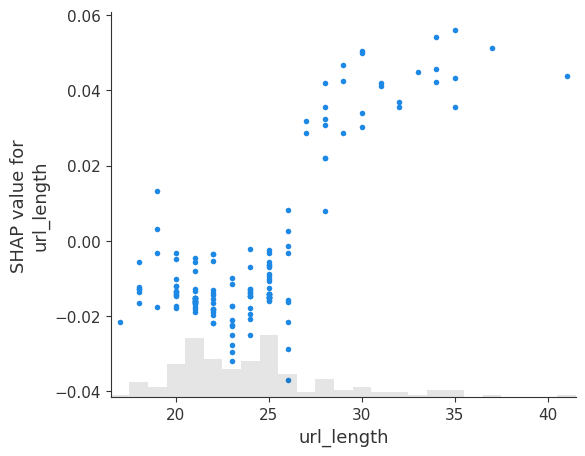

In [49]:
#rf
shap.plots.scatter(shap.Explanation(values=shap_rf_values.values[:,:,1], base_values=shap_rf_values.base_values[:,1], data=shap_rf_values.data, feature_names=shap_rf_values.feature_names)[:,"url_length"])


In [102]:
# Find the index of 'url_length' in your feature names
url_length_feature_index = X.columns.get_loc("url_length")

# Create a new Explanation object specifically for the scatter plot
# Ensure shap_svm_values[1] is (n_samples, n_features)
scatter_explanation = shap.Explanation(
    values=shap_svm_values[1],  # SHAP values for class 1 (n_samples, n_features)
    base_values=explainerSVM.expected_value[1],  # Base value for class 1
    data=X_sample,  # Original data for the samples
    feature_names=X.columns.tolist()
)

# Generate the scatter plot using the new Explanation object and feature name
shap.plots.scatter(scatter_explanation[:, "url_length"])


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

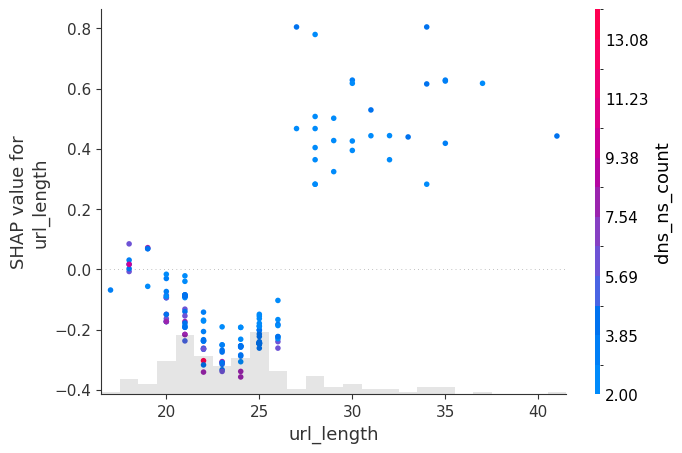

In [42]:
# to color scattered plot
shap.plots.scatter(shap_xgboost_values[:,"url_length"], color=shap_xgboost_values[:,"dns_ns_count"])

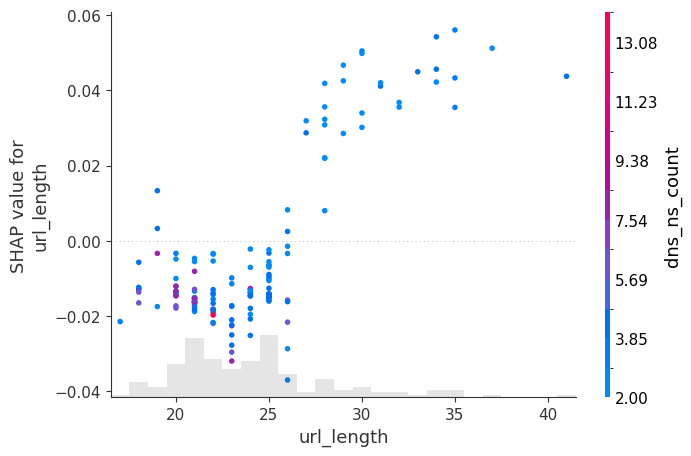

In [50]:
# for rf
shap.plots.scatter(shap.Explanation(values=shap_rf_values.values[:,:,1], base_values=shap_rf_values.base_values[:,1], data=shap_rf_values.data, feature_names=shap_rf_values.feature_names)[:,"url_length"], color=shap.Explanation(values=shap_rf_values.values[:,:,1], base_values=shap_rf_values.base_values[:,1], data=shap_rf_values.data, feature_names=shap_rf_values.feature_names)[:,"dns_ns_count"])


In [ ]:
# now to see how to see prediction for the general dataset 

In [103]:
#waterfall plot for first observation
shap.plots.waterfall(shap_rf_values[0]) #xgboost

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (92, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [45]:
# 1. Confirm that the df_rule_based DataFrame exists and is accessible.
print("df_rule_based exists:", 'df_rule_based' in globals())

# 2. Verify that the 'predicted_label' column in df_rule_based was correctly assigned a value of 2
# during the data preprocessing step. No further action is needed if this is already done.
# 3. If not already assigned, create a new column named 'predicted_label' in the df_rule_based
# DataFrame and assign the integer value 2 to all rows in this column.
if 'predicted_label' not in df_rule_based.columns:
    df_rule_based['predicted_label'] = 2
    print("'predicted_label' column created and assigned value 2.")
elif not (df_rule_based['predicted_label'] == 2).all():
    df_rule_based['predicted_label'] = 2
    print("'predicted_label' column already exists but not all values are 2, assigned value 2.")
else:
    print("'predicted_label' column already exists and all values are 2.")


# 4. Display the first few rows of df_rule_based to visually confirm the 'predicted_label' column.
print("\nFirst few rows of df_rule_based:")
display(df_rule_based.head())

df_rule_based exists: True
'predicted_label' column already exists and all values are 2.

First few rows of df_rule_based:


,url,label,source,http_status,is_active,has_redirect,dns_a_presence,dns_a_count,dns_mx_presence,dns_mx_count,...,num_hostname_tokens,avg_hostname_token_length,max_hostname_token_length,first_digit_index,first_letter_index,first_slash_index,last_slash_index,first_dot_index,last_dot_index,predicted_label
5,https://www.reddit.com,0,2,403,1,0,1.0,1.952703,1.0,1.954545,...,3,4.000000,6,-1,0,6,7,11,18,2
6,https://www.yahoo.com,0,2,429,1,0,1.0,1.952703,1.0,1.954545,...,3,3.666667,5,-1,0,6,7,11,17,2
29,https://www.list.tmall.com,0,2,0,0,0,1.0,1.952703,1.0,1.954545,...,4,3.750000,5,-1,0,6,7,11,22,2
32,https://www.t.co,0,2,0,0,0,1.0,1.952703,1.0,1.954545,...,3,2.000000,3,-1,0,6,7,11,13,2
38,https://www.yahoo.co.jp,0,2,403,1,0,1.0,1.952703,1.0,1.954545,...,4,3.000000,5,-1,0,6,7,11,20,2


In [50]:
# Get ALL ML data (not just test set)
X_all_ml = df_ml.drop(columns=cols_to_drop, axis=1)  # Same features as before

# Generate ensemble predictions for ALL ML data (not just test set)
rf_probs_all = rf_model.predict_proba(X_all_ml)[:, 1]
svm_probs_all = svm_model.predict_proba(X_all_ml)[:, 1]
xgb_probs_all = xgb_model.predict_proba(X_all_ml)[:, 1]
ensemble_probs_all = (rf_probs_all + svm_probs_all + xgb_probs_all) / 3
ml_all_predictions = (ensemble_probs_all >= thresholds['ensemble']).astype(int)

# Create DataFrame with predictions for ALL ML data
ml_predictions_df = pd.DataFrame({
    'predicted_label': ml_all_predictions
}, index=df_ml.index)  # Use original indices from df_ml

# Get rule-based predictions
rule_based_predictions = df_rule_based[['predicted_label']]

# Combine predictions
all_predictions = pd.concat([ml_predictions_df, rule_based_predictions])

# Add to original DataFrame
df_combined['final_prediction'] = all_predictions['predicted_label']

# Verify results
print("\nCount of final predictions by type:")
print(df_combined['final_prediction'].value_counts(dropna=False))

print("\nSample of ML predictions (status 200-299):")
display(df_combined[df_combined['http_status'].between(200, 299)][['url', 'label', 'http_status', 'final_prediction']].tail(20))

print("\nSample of rule-based predictions (status not 200-299):")
display(df_combined[~df_combined['http_status'].between(200, 299)][['url', 'label', 'http_status', 'final_prediction']].head())


Count of final predictions by type:
final_prediction
0    93
1    56
2    51
Name: count, dtype: int64

Sample of ML predictions (status 200-299):


,url,label,http_status,final_prediction
163,https://www.coraevans.com,1,200,1
165,https://www.larepublica.co,1,200,1
166,https://www.pimpim.lt,1,200,0
168,http://www.cjplogger.com,0,200,0
173,https://www.classfmonline.com,1,200,1
174,https://www.cornerstoneinsurance.ca,1,200,1
176,https://www.medicalplasticsnews.com,1,200,1
181,https://www.dancetheyard.org,1,200,1
182,https://www.olly.com,1,200,1
183,https://www.naturalearthdata.com,1,200,1



Sample of rule-based predictions (status not 200-299):


,url,label,http_status,final_prediction
5,https://www.reddit.com,0,403,2
6,https://www.yahoo.com,0,429,2
29,https://www.list.tmall.com,0,0,2
32,https://www.t.co,0,0,2
38,https://www.yahoo.co.jp,0,403,2


PermutationExplainer explainer: 46it [00:32,  1.02s/it]                        
C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\3748687008.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_shap_values, X_test, feature_names=X_train.columns)


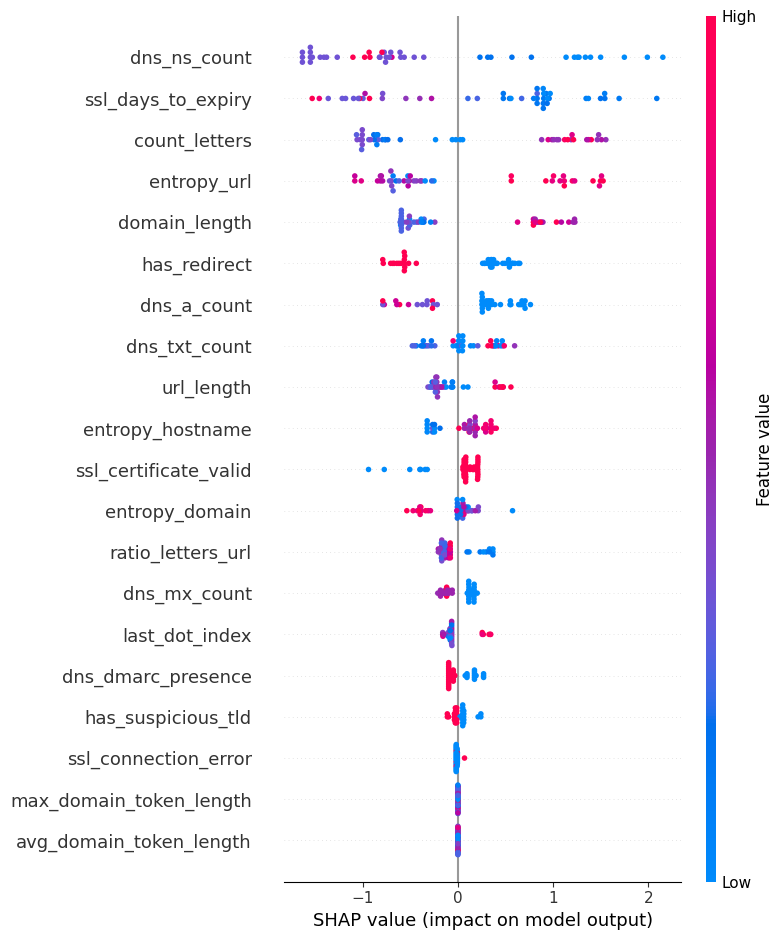

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\3748687008.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(ensemble_shap_values, X_test, feature_names=X_train.columns)


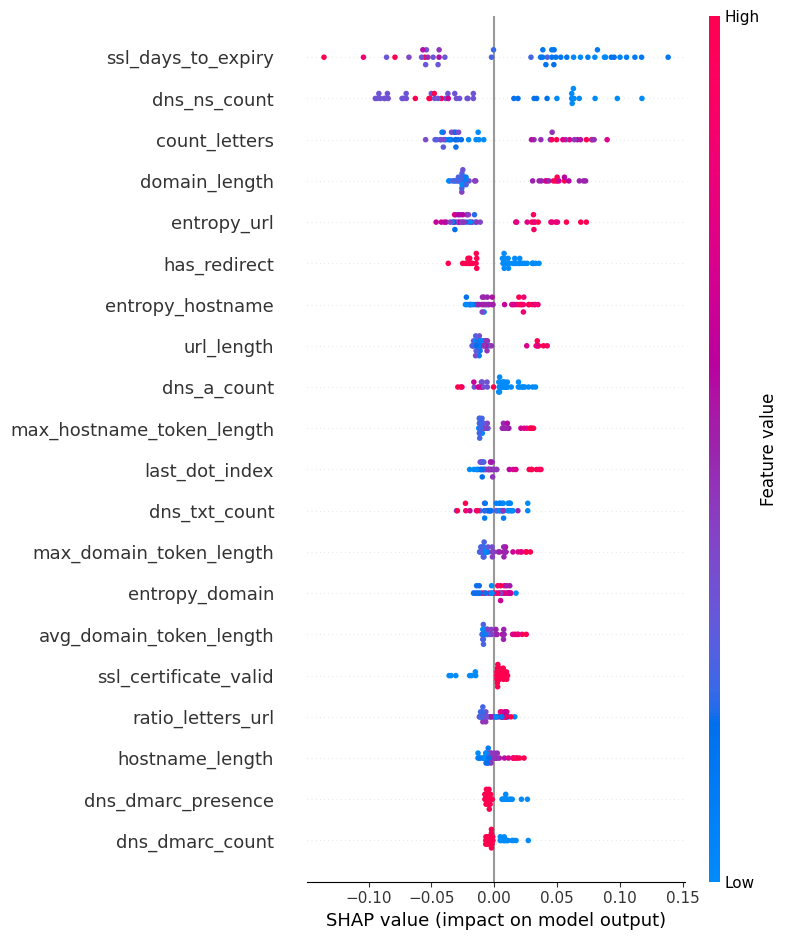

AttributeError: 'PermutationExplainer' object has no attribute 'expected_value'

In [56]:
import shap

# Initialize SHAP explainers for each model
# rf_explainer = shap.Explainer(rf_model, X_train)
# svm_explainer = shap.Explainer(svm_model, X_train)
xgb_explainer = shap.Explainer(xgb_model, X_train)

# Calculate SHAP values for each model
# rf_shap_values = rf_explainer(X_test)
# svm_shap_values = svm_explainer(X_test)
xgb_shap_values = xgb_explainer(X_test)

# For the ensemble, you need to create a function that combines predictions
def ensemble_predict(X):
    rf_pred = rf_model.predict_proba(X)[:, 1]  # Probability of positive class
    svm_pred = svm_model.predict_proba(X)[:, 1]
    xgb_pred = xgb_model.predict_proba(X)[:, 1]
    return (rf_pred + svm_pred + xgb_pred) / 3  # Average probability

# Create SHAP explainer for the ensemble
ensemble_explainer = shap.Explainer(ensemble_predict, X_train)
ensemble_shap_values = ensemble_explainer(X_test)

# Visualize SHAP values for one model (repeat for others)
# shap.summary_plot(rf_shap_values, X_test, feature_names=X_train.columns)
# shap.summary_plot(svm_shap_values, X_test, feature_names=X_train.columns)
shap.summary_plot(xgb_shap_values, X_test, feature_names=X_train.columns)
shap.summary_plot(ensemble_shap_values, X_test, feature_names=X_train.columns)

# You can also visualize individual predictions
shap.force_plot(ensemble_explainer.expected_value[1], ensemble_shap_values[1], X_test.iloc[1,:])

In [57]:
# Initialize the SHAP explainer using one of the tree-based models from the ensemble
# We will use the XGBoost model from the ensemble as it's often well-supported by SHAP
xgb_model_from_ensemble = ensemble_model.estimators_[2] # XGBoost is the third estimator

# Initialize the SHAP explainer with the XGBoost model and the training data
explainer = shap.Explainer(xgb_model_from_ensemble, X_train)

# Calculate SHAP values for the test data X_test
# Setting check_additivity to False to avoid potential issues
shap_values = explainer(X_test, check_additivity=False)

print("SHAP explainer initialized using XGBoost model and SHAP values calculated for X_test.")

# Generate and display a global SHAP summary plot
print("\nGenerating SHAP summary plot:")
shap.summary_plot(shap_values, X_test)

# Select a few sample instances from X_test and generate force plots
print("\nGenerating SHAP force plot for sample instances:")
# Select the first 3 instances from X_test
sample_indices = X_test.head(3).index
for i in sample_indices:
    print(f"\nForce plot for instance with original index {i}:")
    # Find the corresponding row in the shap_values Explanation object
    shap_values_instance = shap_values[X_test.index.get_loc(i)]
    shap.force_plot(explainer.expected_value, shap_values_instance, X_test.loc[i])

NameError: name 'ensemble_model' is not defined

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\3002321776.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_shap_values,       X_test, feature_names=X_train.columns)
C:\Users\Ifeoluwa Oseni\AppData\Roaming\Python\Python313\site-packages\shap\plots\_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\Ifeoluwa Oseni\AppData\Roaming\Python\Python313\site-packages\shap\plots\_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in

<Figure size 640x480 with 0 Axes>

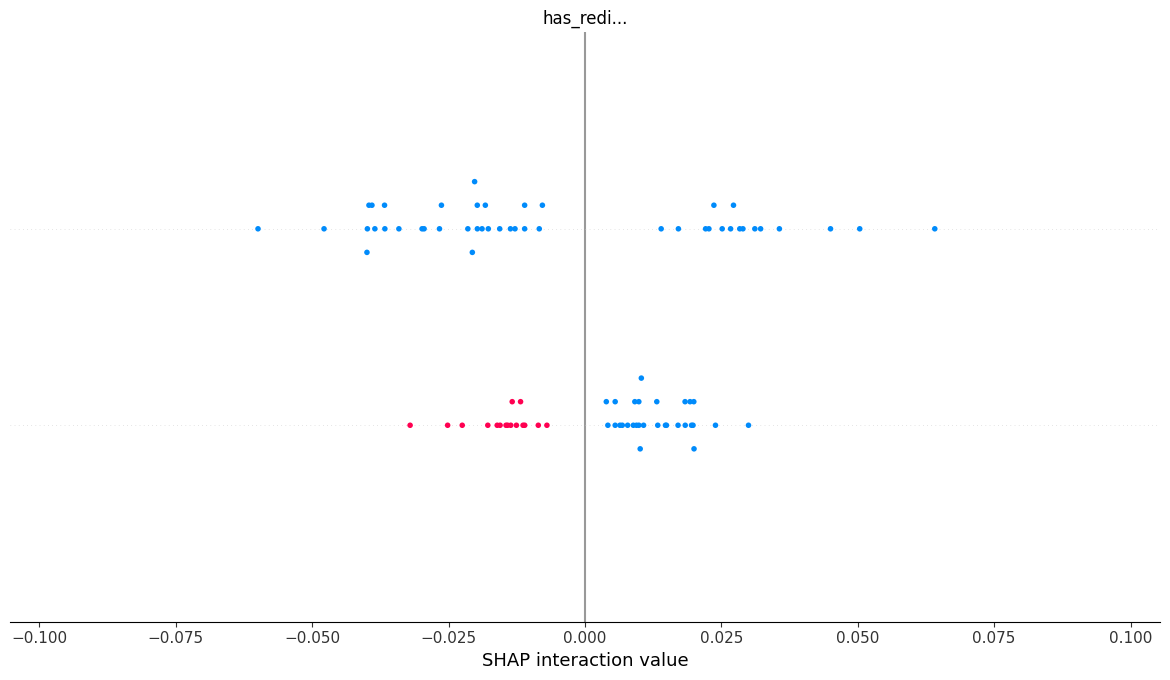

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\3002321776.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_shap_values,     X_test, feature_names=X_train.columns)


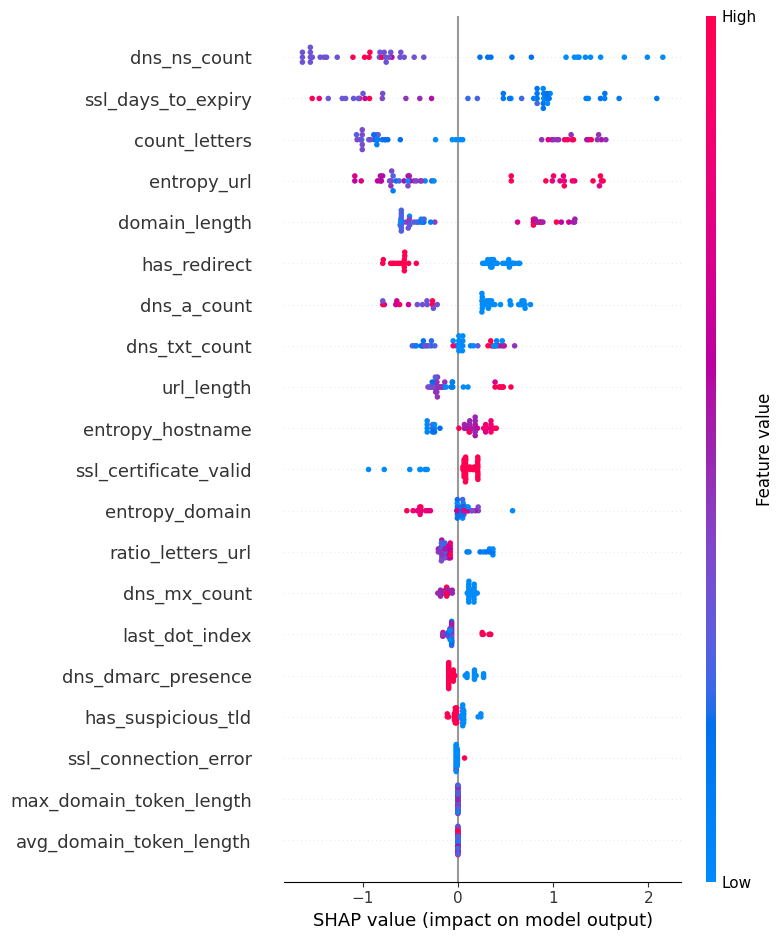

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\3002321776.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(svm_shap_values,      X_test, feature_names=X_train.columns)


AssertionError: Summary plots need a matrix of shap_values, not a vector.

<Figure size 640x480 with 0 Axes>

In [59]:
import shap
import pandas as pd
from shap import TreeExplainer, KernelExplainer

# --- 1) make sure your functions always see DataFrames with proper column names ---
def svm_proba_df(X):
    # shap will pass in a NumPy array; wrap back into your DataFrame
    df = pd.DataFrame(X, columns=X_train.columns)
    return svm_model.predict_proba(df)[:, 1]

def ensemble_proba_df(X):
    df = pd.DataFrame(X, columns=X_train.columns)
    return ensemble_predict(df)

# --- 2) pick a small background for KernelExplainer (to keep run‐time reasonable) ---
background = shap.sample(X_train, 100, random_state=42)

# --- 3) build your explainers ---
rf_explainer       = shap.TreeExplainer(rf_model, X_train)
xgb_explainer     = shap.TreeExplainer(xgb_model, X_train)
svm_explainer      = shap.KernelExplainer(svm_proba_df,      background)
ensemble_explainer = shap.KernelExplainer(ensemble_proba_df, background)

# --- 4) compute SHAP‑values; each returns a single-output array of shape (n_samples, n_features) ---
rf_shap_values       = rf_explainer.shap_values(X_test)       # already (n_samples, n_features)
xgb_shap_values     = xgb_explainer.shap_values(X_test)
svm_shap_values      = svm_explainer.shap_values(X_test)      # KernelExplainer returns a list; take [1]
svm_shap_values      = svm_shap_values[1]                      
ensemble_shap_values = ensemble_explainer.shap_values(X_test)
ensemble_shap_values = ensemble_shap_values[1]

# --- 5) summary plots (now shapes match exactly X_test) ---
shap.summary_plot(rf_shap_values,       X_test, feature_names=X_train.columns)
shap.summary_plot(xgb_shap_values,     X_test, feature_names=X_train.columns)
shap.summary_plot(svm_shap_values,      X_test, feature_names=X_train.columns)
shap.summary_plot(ensemble_shap_values, X_test, feature_names=X_train.columns)

# --- 6) force plot for a single instance (e.g. X_test.iloc[1]) ---
idx = 1
# KernelExplainer stores expected_value as a list [for class 0, class 1]
base_val = ensemble_explainer.expected_value[1]
shap.force_plot(
    base_val, 
    ensemble_shap_values[idx], 
    X_test.iloc[idx], 
    feature_names=X_train.columns
)


  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\4217870283.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(exp, show=False)
C:\Users\Ifeoluwa Oseni\AppData\Roaming\Python\Python313\site-packages\shap\plots\_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\Ifeoluwa Oseni\AppData\Roaming\Python\Python313\site-packages\shap\plots\_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warni

<Figure size 640x480 with 0 Axes>

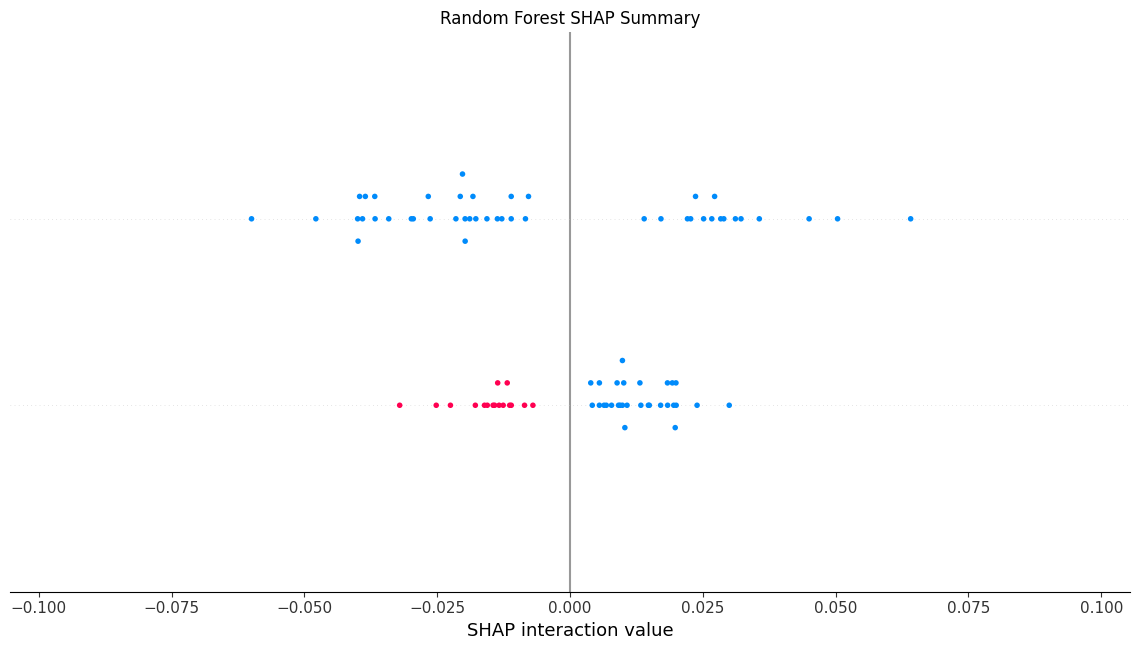

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\4217870283.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(exp, show=False)


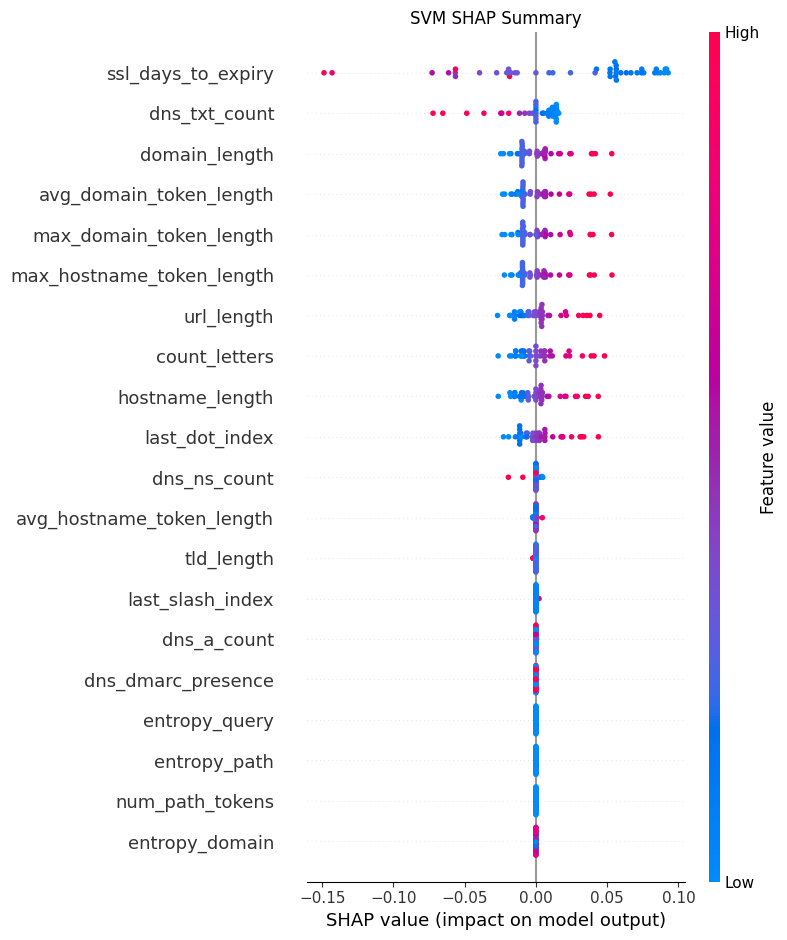

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\4217870283.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(exp, show=False)


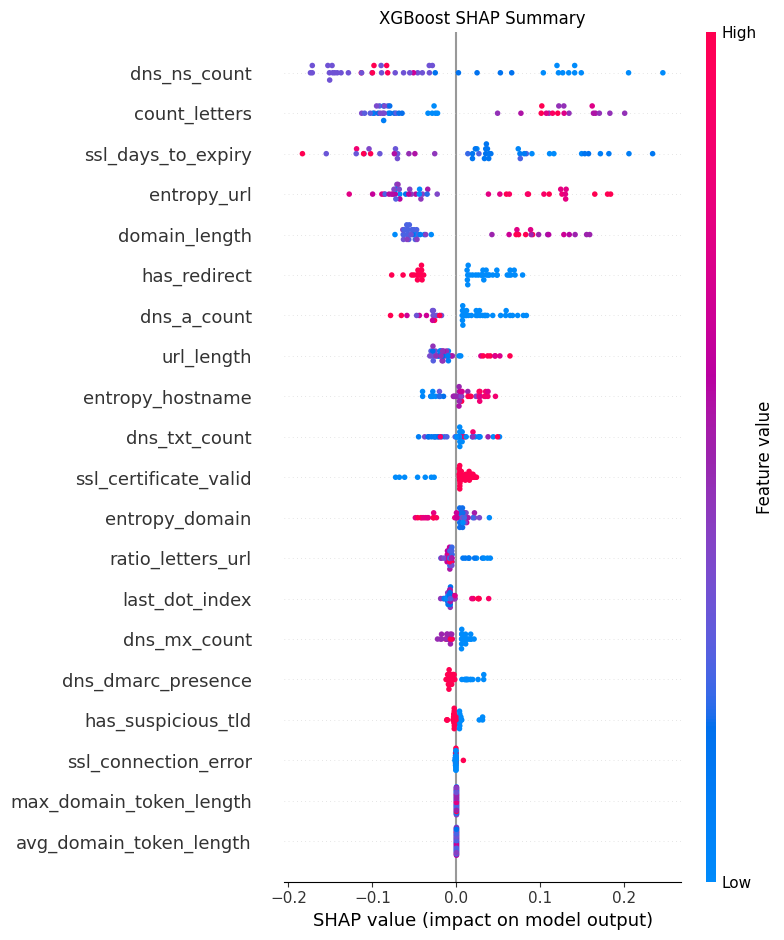

C:\Users\Ifeoluwa Oseni\AppData\Local\Temp\ipykernel_10320\4217870283.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(exp, show=False)


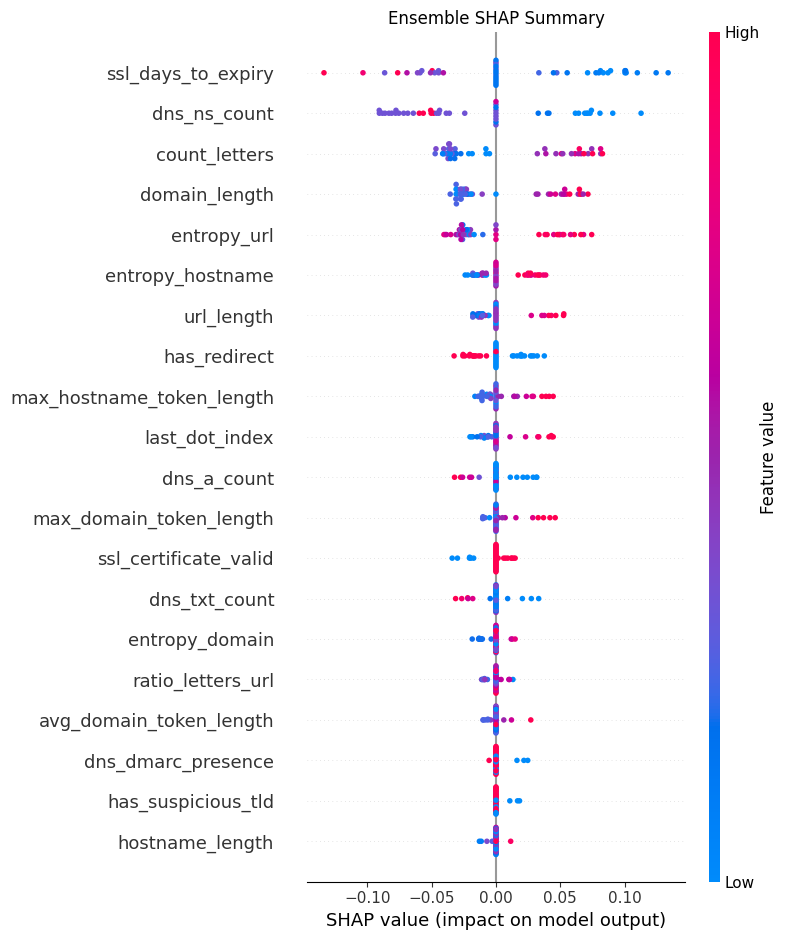

In [60]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) wrappers so models always see DataFrame with correct column names ---
def svm_proba_df(X_array):
    df = pd.DataFrame(X_array, columns=X_train.columns)
    return svm_model.predict_proba(df)[:, 1]

def ensemble_proba_df(X_array):
    df = pd.DataFrame(X_array, columns=X_train.columns)
    return ensemble_predict(df)

# --- 1) small background for KernelExplainer speed-up ---
background = shap.sample(X_train, 100, random_state=42)

# --- 2) build explainers ---
rf_explainer       = shap.TreeExplainer(rf_model,   X_train, model_output="probability")
xgb_explainer     = shap.TreeExplainer(xgb_model,  X_train, model_output="probability")
svm_explainer      = shap.KernelExplainer(svm_proba_df,      background)
ensemble_explainer = shap.KernelExplainer(ensemble_proba_df, background)

# --- 3) generate SHAP Explanation objects (contains values, base_values, data) ---
rf_exp       = rf_explainer(X_test)
xgb_exp     = xgb_explainer(X_test)
svm_exp      = svm_explainer(X_test)
ensemble_exp = ensemble_explainer(X_test)

# --- 4) summary plots with titles ---
for exp, model_name in [
    (rf_exp,       "Random Forest"),
    (svm_exp,      "SVM"),
    (xgb_exp,     "XGBoost"),
    (ensemble_exp, "Ensemble")
]:
    # pass the Explanation object directly
    shap.summary_plot(exp, show=False)
    plt.title(f"{model_name} SHAP Summary")
    plt.tight_layout()
    plt.show()

# --- 5) force plot example (e.g. for sample idx = 1) ---
idx = 1
base_val = ensemble_exp.base_values[idx]   # base probability for that sample
shap.force_plot(
    base_val,
    ensemble_exp.values[idx],
    X_test.iloc[idx],
    feature_names=X_train.columns
)


0.47.2


NameError: name 'xgb_model' is not defined